In [ ]:

# #sst = xr.open_dataset("sst.nc")["sst"]
# sst_lt = xr.open_dataset(output_filepath + "SST_LT.nc")
# sst_lt

# # ENSO: pass a Dataset (sst_var picks the variable) or a DataArray directly
# enso = compute_enso(sst_lt, clim_start="1981", clim_end="2010", smooth_window=3)
# enso
# # NAO: needs sea-level pressure, not SST
# slp = xr.open_dataset("slp.nc")["msl"]
# nao = compute_nao(slp, clim_start="1991", clim_end="2020")

# # PDO: needs both SST and a target Dataset whose time axis to align to,
# # and returns two things (index, spatial pattern)
# pdo_index, pdo_pattern = compute_pdo(sst, target=slp, clim_start="1920-01-01", clim_end="2014-12-31")

# TOP

In [26]:
# Load Installed Packages
import xarray as xr
import numpy as np
import pandas as pd
import xesmf as xe
import xcdat as xc
# import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import FormatStrFormatter

from eofs.standard import Eof

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.signal import firwin
from scipy.signal import detrend

import seaborn as sns
from scipy.stats import pearsonr

In [1]:
input_filepath = "../data/"
index_filepath = "../data/ref_index/"
output_filepath = "../created/"

In [2]:
# Load Utils
%load_ext autoreload
%autoreload 2
# Load Local Utils
import utils_plotting_index
import utils_plotting_map
import utils_general
import utils_regression
import utils_agreement

import xarray as xr
from climate_indices_clean import compute_enso, compute_nao, compute_pdo


# Load 

## Dates

In [ ]:
# da_monthly_lt = xr.open_dataset(output_filepath + 'da_monthly_lt.nc')
# da_seasonal_lt = xr.open_dataset(output_filepath + 'da_seasonal_lt.nc')

# da_monthly_st = xr.open_dataset(output_filepath + 'da_monthly_st.nc')
# da_seasonal_st = xr.open_dataset(output_filepath + 'da_seasonal_st.nc')

# SST Loading

## Index

In [3]:
sst_index_ref = xr.open_dataset(output_filepath + "sst.index.ref.nc")
sst_index_ref

<xarray.Dataset> Size: 47kB
Dimensions:  (time: 1479)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-11-01 1901-12-01 ... 2025-01-01
Data variables:
    enso     (time) float32 6kB ...
    pdo      (time) float32 6kB ...
    amo      (time) float64 12kB ...
    iod      (time) float32 6kB ...
    tpi      (time) float32 6kB ...

## HADI SST

In [4]:
sst_lt = xr.open_dataset(output_filepath + "SST_LT.nc")
sst_lt

<xarray.Dataset> Size: 383MB
Dimensions:    (time: 1479, bnds: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) datetime64[ns] 12kB 1901-11-01 1901-12-01 ... 2025-01-01
  * lat        (lat) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon        (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 24kB ...
    sst        (time, lat, lon) float32 383MB ...
    lon_bnds   (lon, bnds) float32 3kB ...
    lat_bnds   (lat, bnds) float32 1kB ...
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    3/3/2025 converted to netcdf from pp format
    supplementary_information:  Updates and supplementary information will be...
    comment:                    Data restrictions: for academic research use ...

In [5]:
sst_st = sst_lt.sel(time =slice('1979-12-01', '2024-11-30'))
sst_st

<xarray.Dataset> Size: 140MB
Dimensions:    (time: 540, bnds: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1979-12-01 1980-01-01 ... 2024-11-01
  * lat        (lat) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon        (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 9kB ...
    sst        (time, lat, lon) float32 140MB ...
    lon_bnds   (lon, bnds) float32 3kB ...
    lat_bnds   (lat, bnds) float32 1kB ...
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    3/3/2025 converted to netcdf from pp format
    supplementary_information:  Updates and supplementary information will be...
    comment:                    Data restrictions: for academic research use ...

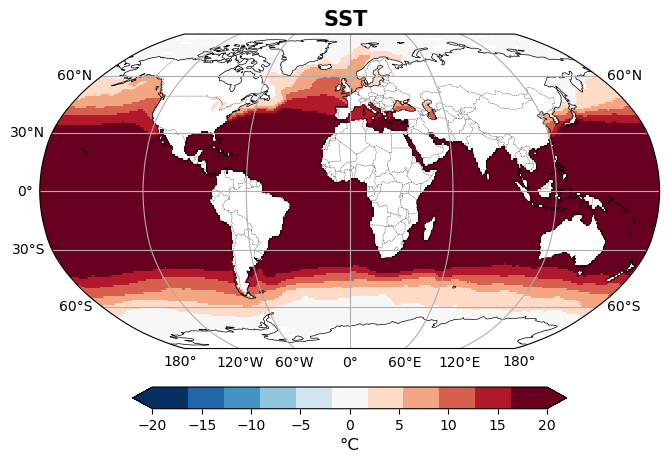

In [6]:
utils_plotting_map.single_plot(sst_lt.sst.isel(time=-1),
            "SST " ,
            "RdBu_r", 11, -20, 20, 
            '°C')

## ERSST

In [ ]:
ersst_sst = xr.open_dataset(input_filepath + "SST_ERSST_1854_2026.nc")
ersst_sst

In [ ]:
ersst_sst = xr.open_dataset(output_filepath + "ERSST_SST_rg.nc").sel(time = slice('1901-11-01','2025-01-31'))
ersst_sst #= ersst_sst.sel(time = slice('1901-01-01','2024-12-31'))

# ENSO

## Ref

In [7]:
enso_ref = sst_index_ref.enso
enso_ref

<xarray.DataArray 'enso' (time: 1479)> Size: 6kB
[1479 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-11-01 1901-12-01 ... 2025-01-01
Attributes:
    description5:    units=degC
    description4:   https://psl.noaa.gov/data/timeseries/month/Nino34/
    description3:    Anomaly from 1981-2010
    description2:   HadISST 
    description1:   5N-5S 170W-120W 
    long_name:       NINA34
    title:           NINA34
    nextra:        7
    Last_year:     2025
    First_year:    1870
    units:           
    name:          description(0)

## Compute

### Val

In [8]:
enso_index_val = compute_enso(sst_lt, clim_start="1981", clim_end="2010", smooth_window=0)
enso_index_val

<xarray.DataArray 'ENSO' (time: 1479)> Size: 6kB
array([-0.3929329 , -0.34542274, -0.49362183, ..., -0.0537796 ,
       -0.5799885 , -0.63635063], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-11-01 1901-12-01 ... 2025-01-01
Attributes:
    long_name:           ENSO Nino 3.4 Index
    description:         Area-weighted SST anomalies in the Nino 3.4 region
    units:               degC
    climatology_period:  1981 to 2010
    smoothing:           None

In [9]:
# enso_index_val = compute_enso(sst_lt.sst, da_monthly_lt)#, 
                             #climatology_period=('1981', '2010')) 
                                             #clim_start='1901-01-01', clim_end='2024-12-31')

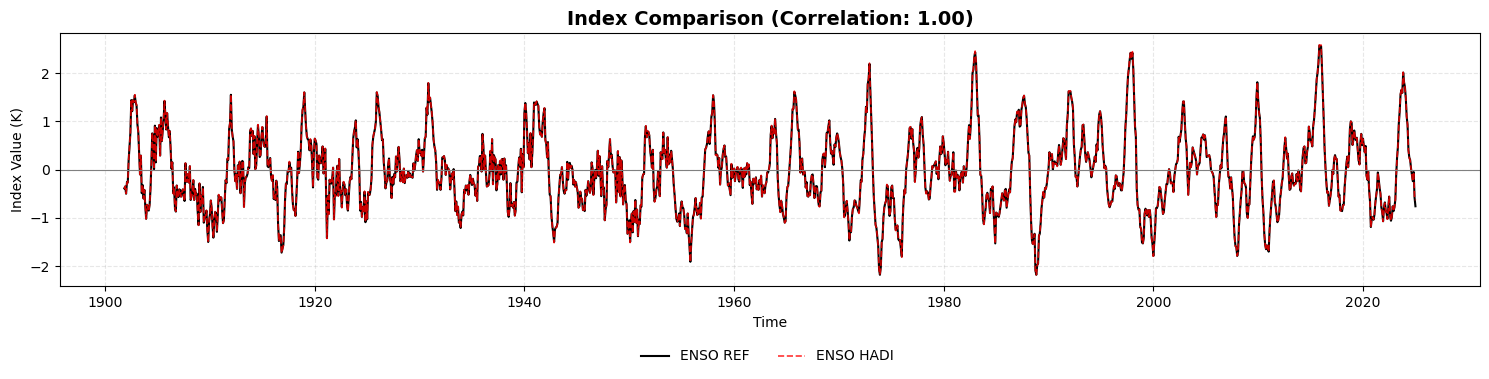

0.9999547724525085

In [10]:
utils_plotting_index.index_corr_plot(enso_ref, enso_index_val, 
                                     label1="ENSO REF", label2="ENSO HADI ", 
                                     title="Index Comparison")

In [11]:
#enso_index_val.to_netcdf(output_filepath + 'ENSO/enso_index_val.nc')

### Sys. LT

In [12]:
enso_index_lt = compute_enso(sst_lt, clim_start="1901", clim_end="2025", smooth_window=0)
enso_index_lt

<xarray.DataArray 'ENSO' (time: 1479)> Size: 6kB
array([-0.3287506 , -0.33254623, -0.47652435, ...,  0.01040268,
       -0.56711197, -0.61925316], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-11-01 1901-12-01 ... 2025-01-01
Attributes:
    long_name:           ENSO Nino 3.4 Index
    description:         Area-weighted SST anomalies in the Nino 3.4 region
    units:               degC
    climatology_period:  1901 to 2025
    smoothing:           None

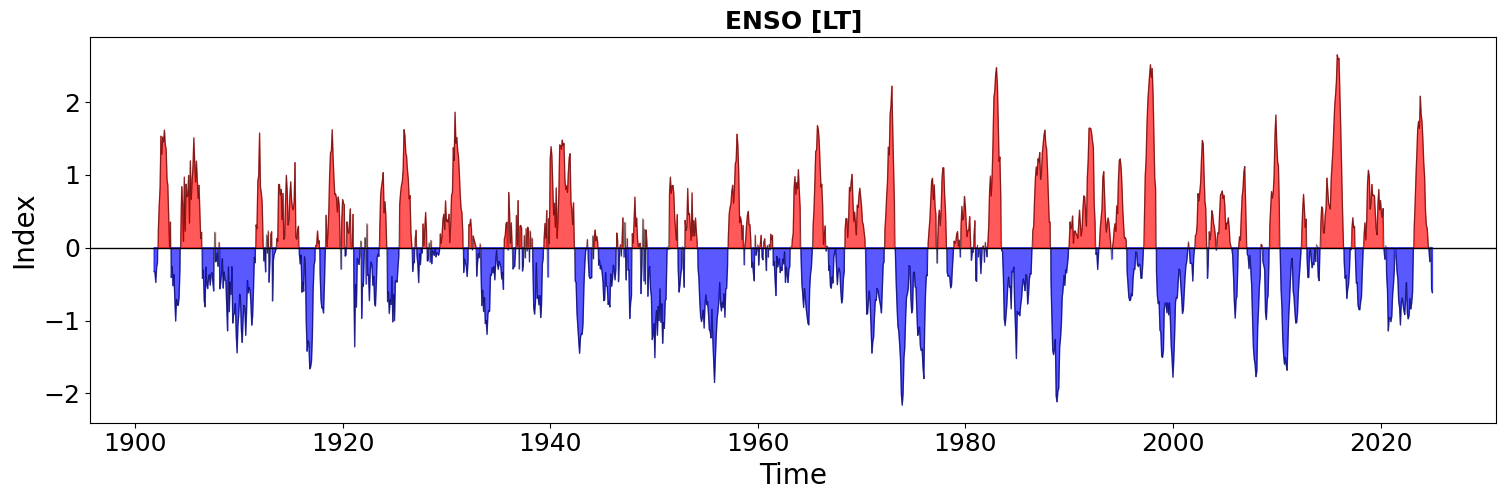

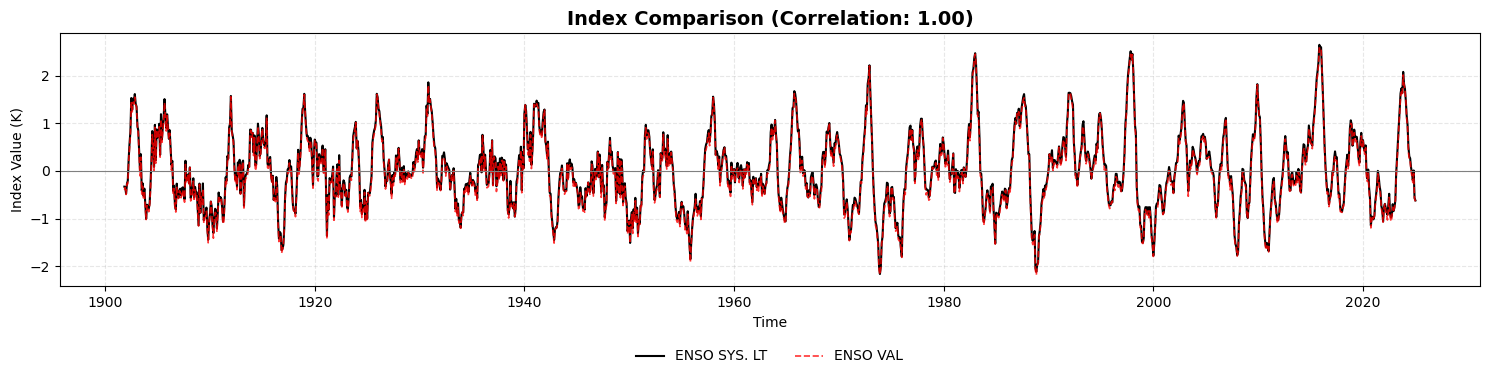

0.9992610368674613

In [13]:
utils_plotting_index.single_index_plot(enso_index_lt, 
                      'ENSO [LT]', 
                      'Index')

utils_plotting_index.index_corr_plot(enso_index_lt, enso_index_val, 
                                     label1="ENSO SYS. LT", label2="ENSO VAL", 
                                     title="Index Comparison")

In [ ]:
#enso_index_lt.to_netcdf(output_filepath + 'ENSO/enso_index_lt.nc')

### Sys. ST

In [ ]:
enso_index_st = compute_enso(sst_st, da_monthly_st, 
                               climatology_period=('1901', '2025')) 

utils_plotting_index.single_index_plot(enso_index_st, 
                      'ENSO [ST]', 
                      'Index')

utils_plotting_index.index_corr_plot(enso_index_st, enso_index_val, 
                                     label1="ENSO SYS. ST", label2="ENSO VAL", 
                                     title="Index Comparison")

In [ ]:
#enso_index_st.to_netcdf(output_filepath + 'ENSO/enso_index_st.nc')

## Plot Index TS

In [ ]:
# utils_plotting_index.plot_climate_indices(
#     {
#         'Validation': (enso_index_val, {'color': 'blue'}),
#         'Reference': (enso_ref, {'color': 'black', 'linestyle': '--', 'alpha': 0.5, 'linewidth': 1.5}),
#         #'Sys LT': (enso_index_lt, {'color': 'red'}),
#         #'Sys ST': (enso_index_st, {'color': 'green'}),
#     },
#     title='ENSO Index Comparison'
# )

In [ ]:
utils_plotting_index.plot_climate_indices(
    {
        'Validation': (enso_index_val, {'color': 'blue'}),
        'Reference': (enso_ref, {'color': 'black', 'linestyle': '--', 'alpha': 0.5, 'linewidth': 1.5}),
        'Sys LT': (enso_index_lt, {'color': 'red'}),
        'Sys ST': (enso_index_st, {'color': 'green'}),
    },
    title='ENSO Index Comparison'
)

# IOD

In [ ]:
iod_ref = sst_index_ref.iod
iod_ref

## Compute

In [ ]:
def compute_iod(
    sst,
    #clim_range=slice("1991", "2020"),
    climatology_period=slice("1991", "2020"),#('1901', '2025')
    remove_global_mean=True,
):
    """
    Compute the Dipole Mode Index (DMI / IOD) from raw SST data.
    Includes internal anomaly calculation and area-weighted global mean removal.
    """
    
    # 1. Compute Climatology and Anomalies
    # Handles seasonal cycle by grouping by month
    climatology = sst.sel(time=climatology_period).groupby("time.month").mean("time")
    sst_anom = sst.groupby("time.month") - climatology

    # 2. Remove Area-Weighted Global Mean (if requested)
    if remove_global_mean:
        # Calculate weights based on latitude (cosine of lat in radians)
        weights = np.cos(np.deg2rad(sst_anom.lat))
        weights.name = "weights"
        
        # Compute weighted mean across lat and lon
        global_mean = sst_anom.weighted(weights).mean(dim=["lat", "lon"])
        
        # Subtract the global signal from the anomalies
        sst_anom = sst_anom - global_mean

    # 3. Define IOD Boxes

    # West box (50°–70°E, 10°S–10°N)
    west_box = sst_anom.sel(lon=slice(50, 70), lat=slice(10, -10))
    west = west_box.mean(dim=["lat", "lon"])

    # East box (90°–110°E, 10°S–0°)
    east_box = sst_anom.sel(lon=slice(90, 110), lat=slice(0, -10))
    east = east_box.mean(dim=["lat", "lon"])

    # 4. Final DMI Calculation
    iod_index = west - east
    
    # Metadata
    iod_index.name = "IOD"
    iod_index.attrs.update({
        "long_name": "Dipole Mode Index (West - East SST)",
        "units": "°C",
        "description": "Computed with monthly climatology removal and global mean detrending."
    })
    
    iod_index = iod_index.drop_vars('month')

    return iod_index

### VAL

In [ ]:
iod_index_val = compute_iod(sst_lt.sst) 
                            #da_monthly_lt)
iod_index_val

In [ ]:
utils_plotting_index.single_index_plot(iod_index_val, 
                      'IOD [Val]', 
                      'Index')

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   iod_index_val, iod_ref, 
    label1="IOD Val", 
    label2="IOD Ref",
    title="IOD"
)
plt.show()

### LT

In [ ]:
iod_index_lt = compute_iod(sst_lt.sst, climatology_period = slice('1901', '2025')) 
                                    #clim_start='1901-01-01', clim_end='2024-12-31')

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   iod_index_lt , iod_ref, 
    label1="IOD Val", 
    label2="IOD Ref",
    title="IOD Long Term"
)
plt.show()

### ST

In [ ]:
iod_index_st = compute_iod(sst_st.sst, climatology_period = slice('1980', '2025')) 
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   iod_index_st , iod_ref, 
    label1="IOD Val", 
    label2="IOD Ref",
    title="IOD Short Term"
)
plt.show()

In [ ]:
# iod_index_val.to_netcdf(output_filepath + 'IOD/iod_index_val.nc')
# iod_index_lt.to_netcdf(output_filepath + 'IOD/iod_index_lt.nc')
# iod_index_st.to_netcdf(output_filepath + 'IOD/iod_index_st.nc')

In [ ]:
utils_plotting_index.plot_climate_indices(
    {
        'Validation': (iod_index_val, {'color': 'blue'}),
        'Reference': (iod_ref, {'color': 'black', 'linestyle': '--', 'alpha': 0.5, 'linewidth': 1.5}),
        'Sys LT': (iod_index_lt, {'color': 'red'}),
        'Sys ST': (iod_index_st, {'color': 'green'}),
    },
    title='IOD Index Comparison'
)

# PDO

In [ ]:
pdo_ref = sst_index_ref.pdo
pdo_ref

## Compute

In [ ]:
def compute_pdo(
    sst,
    dat,
    lat_range=(70, 20),          # north to south
    lon_range=(110, -100),       # 110E to 100W in -180 to 180 coords
    clim_start='1920-01-01',
    clim_end='2014-12-31'
):
    """
    Compute PDO index and pattern from SST using:
    1. Monthly climatology removal
    2. Global mean removal (60S–70N)
    3. EOF over North Pacific

    Notes
    -----
    Assumes:
    - lon is -179.5 to 178.5
    - lat is ordered North to South (positive to negative)
    """

    # make sure time matches target time axis
    sst = sst.copy()
    sst['time'] = dat['time']

    # 1. Remove monthly climatology
    climatology = (
        sst.sel(time=slice(clim_start, clim_end))
           .groupby('time.month')
           .mean('time')
    )
    ssta = sst.groupby('time.month') - climatology
    ssta = ssta.drop_vars('month')

    # 2. Remove global mean over 60S–70N
    # lat is descending, so slice(70, -60)
    weights = np.cos(np.deg2rad(ssta.lat))
    global_mean = (
        ssta.sel(lat=slice(70, -60))
            .weighted(weights)
            .mean(dim=("lat", "lon"))
    )
    ssta = ssta - global_mean

    # 3. Subset North Pacific
    # lat descending: slice(70, 20)
    # lon in -180..180: 110E to 100W == 110 to -100, crosses dateline
    if lon_range[0] <= lon_range[1]:
        ssta_pac = ssta.sel(
            lat=slice(lat_range[0], lat_range[1]),
            lon=slice(lon_range[0], lon_range[1])
        )
    else:
        pac1 = ssta.sel(
            lat=slice(lat_range[0], lat_range[1]),
            lon=slice(lon_range[0], 180)
        )
        pac2 = ssta.sel(
            lat=slice(lat_range[0], lat_range[1]),
            lon=slice(-180, lon_range[1])
        )
        ssta_pac = xr.concat([pac1, pac2], dim='lon')

    if np.all(np.isnan(ssta_pac.values)):
        raise ValueError("The subsetted North Pacific region contains only NaNs.")

    # 4. EOF analysis
    data = ssta_pac.transpose('time', 'lat', 'lon').values

    coslat = np.cos(np.deg2rad(ssta_pac.lat.values))
    wgts = np.sqrt(coslat)[..., np.newaxis]

    solver = Eof(data, weights=wgts)

    eof1 = solver.eofs(neofs=1)[0]
    pc1 = solver.pcs(npcs=1, pcscaling=1)[:, 0]

    # 5. Sign correction at 37N, 160W (= -160)
    lat_idx = np.abs(ssta_pac.lat - 37).argmin()
    lon_idx = np.abs(ssta_pac.lon - (-160)).argmin()

    if eof1[lat_idx, lon_idx] < 0:
        eof1 *= -1
        pc1 *= -1

    # 6. Standardize PC
    pc1 = (pc1 - pc1.mean()) / pc1.std()

    pdo_index = xr.DataArray(pc1, coords=[dat.time], dims=['time'], name='pdo') * -1
    pdo_pattern = xr.DataArray(
        eof1,
        coords=[ssta_pac.lat, ssta_pac.lon],
        dims=['lat', 'lon'],
        name='pdo_pattern'
    )
    
       # Metadata
    pdo_index.name = "PDO"
    pdo_index.attrs.update({
        "long_name": "Pacific Decadal Oscillations",
        "units": "°C",
        #"description": "Computed with monthly climatology removal and global mean detrending."
    })

    return pdo_index, pdo_pattern

### Val

In [ ]:
pdo_index_val, pdo_pattern_val = compute_pdo(sst_lt.sst, da_monthly_lt)

In [ ]:
utils_plotting_index.single_index_plot(pdo_index_val, 
                      'PDO [Val]', 
                      'Index')

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   pdo_index_val, pdo_ref, 
    label1="PDO Val", 
    label2="PDO Ref",
    title="PDO"
)
plt.show()

In [ ]:
# sst_lt_2 = sst_lt.sst.interp(lat=np.arange(89, -90, -2.0), lon=np.arange(-179, 180, 2.0), method="linear")
# sst_lt_2.isel(time = -1).plot()
# pdo_index_val_2, pdo_pattern_val_2 = compute_pdo(sst_lt_2, da_monthly_lt)

# # Assuming your variables are iod_index.IOD and dmi.value
# utils_plotting_index.index_corr_plot(
#    pdo_index_val_2, pdo_ref, 
#     label1="PDO Val", 
#     label2="PDO Ref",
#     title="PDO"
# )
# plt.show()

In [ ]:
def calculate_pdo_ncl(sst, time_dim='time', lat_dim='lat', lon_dim='lon',
                      base_start="1920-01", base_end="2014-12"):

    # 1. Standardize Longitude (0-360)
    if sst[lon_dim].min() < 0:
        sst = sst.assign_coords({lon_dim: (sst[lon_dim] % 360)}).sortby(lon_dim)

    # 2. Base period subset
    sst_base = sst.sel({time_dim: slice(base_start, base_end)})

    # 3. Monthly anomalies relative to base climatology
    climo = sst_base.groupby(f"{time_dim}.month").mean(time_dim)
    ssta  = sst.groupby(f"{time_dim}.month") - climo

    # 4. Remove area-weighted global mean SSTA (60S–70N)
    lat_dir = ssta[lat_dim][0] > ssta[lat_dim][-1]
    glob_sel = {lat_dim: slice(70, -60)} if lat_dir else {lat_dim: slice(-60, 70)}
    weights  = np.cos(np.deg2rad(ssta[lat_dim]))
    global_mean = (ssta.sel(glob_sel)
                   .weighted(weights.sel(glob_sel))
                   .mean((lat_dim, lon_dim)))
    ssta = ssta - global_mean

    # 5. Subset North Pacific PDO region
    pdo_lat_sel = {lat_dim: slice(70, 20)} if lat_dir else {lat_dim: slice(20, 70)}
    pdo_full = ssta.sel(**pdo_lat_sel, **{lon_dim: slice(110, 260)})

    # Mask points invalid over the entire record (drifting sea ice etc.)
    pdo_full = pdo_full.where(pdo_full.notnull().all(dim=time_dim))

    # 6. EOF on base period with sqrt-cos-lat weighting
    pdo_base = pdo_full.sel({time_dim: slice(base_start, base_end)})
    eof_wgt  = np.sqrt(np.cos(np.deg2rad(pdo_base[lat_dim].values)))  # (nlat,)

    nt, nlat, nlon = pdo_base.sizes[time_dim], pdo_base.sizes[lat_dim], pdo_base.sizes[lon_dim]
    Xb = pdo_base.fillna(0.0).values.reshape(nt, nlat * nlon)   # (T_base, S)
    Xb = Xb * (eof_wgt[:, None] * np.ones((1, nlon))).reshape(-1)  # apply weights

    # SVD — U: time scores, Vt: spatial patterns
    U, s, Vt = np.linalg.svd(Xb, full_matrices=False)
    eof_vec = Vt[0]                                              # (S,) leading EOF
    pct_var = float(s[0]**2 / (s**2).sum() * 100)

    # 7. Project full record onto EOF
    nt_full = pdo_full.sizes[time_dim]
    Xf      = pdo_full.fillna(0.0).values.reshape(nt_full, nlat * nlon)
    pc1     = Xf @ eof_vec                                      # (T_full,)

    # 8. Sign convention — positive PDO = warm eastern North Pacific (37N, 200E)
    eof_da = xr.DataArray(eof_vec.reshape(nlat, nlon),
                          dims=[lat_dim, lon_dim],
                          coords={lat_dim: pdo_base[lat_dim], lon_dim: pdo_base[lon_dim]})
    if float(eof_da.sel({lat_dim: 37, lon_dim: 200}, method="nearest")) >= 0:
        pc1, eof_da = -pc1, -eof_da

    # 9. Normalise by base-period std
    nt_base = pdo_base.sizes[time_dim]
    pc1     = pc1 / pc1[:nt_base].std()

    pdo_index = xr.DataArray(pc1, dims=[time_dim],
                             coords={time_dim: pdo_full[time_dim]},
                             attrs={"long_name": "PDO index", "units": "std",
                                    "base_period": f"{base_start} to {base_end}",
                                    "pc_variance_pct": pct_var})
    return pdo_index, eof_da

pdo_index_val_ncl, pdo_pattern_val_ncl =  calculate_pdo_ncl(sst_lt.sst)

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   pdo_index_val_ncl, pdo_ref, 
    label1="PDO Val", 
    label2="PDO Ref",
    title="PDO"
)
plt.show()

### LT

In [ ]:
pdo_index_lt, pdo_pattern_lt = compute_pdo(sst_lt.sst, da_monthly_lt,
                                           clim_start='1900-01-01', clim_end='2024-12-31')#, remove_global_mean=True,

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   pdo_index_lt, pdo_ref, 
    label1="PDO LT", 
    label2="PDO Ref",
    title="PDO"
)
plt.show()

### ST

In [ ]:
pdo_index_st, pdo_pattern_st = compute_pdo(sst_st.sst, da_monthly_st.sel(time = slice('1979-01-01', '2024-11-01')),
                                           clim_start='1979-12-01', clim_end='2024-12-31')

utils_plotting_index.single_index_plot(pdo_index_st, 
                      'PDO [ST]', 
                      'Index')

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   pdo_index_st, pdo_ref, 
    label1="PDO ST", 
    label2="PDO Ref",
    title="PDO"
)
plt.show()

### ALL

In [ ]:
utils_plotting_index.plot_climate_indices(
    {
        'Validation': (pdo_index_val, {'color': 'blue'}),
        'Sys LT': (pdo_index_lt, {'color': 'red'}),
        'Sys ST': (pdo_index_st, {'color': 'green'}),
        'Reference': (pdo_ref, {'color': 'black', 'linestyle': '--', 'alpha': 0.5, 'linewidth': 1.5}),
    },
    title='PDO Index Comparison'
)

In [ ]:
# pdo_index_val.to_netcdf(output_filepath + 'PDV/pdv_index_val.nc')
# pdo_index_lt.to_netcdf(output_filepath + 'PDV/pdv_index_lt.nc')
# pdo_index_st.to_netcdf(output_filepath + 'PDV/pdv_index_st.nc')

# AMO

In [ ]:
amo_ref = sst_index_ref.amo
amo_ref['amo'] = amo_ref#['amo']
amo_ref

In [ ]:
amo_ref_dt = utils_plotting_index.detrend_index(amo_ref)

## Compute

In [ ]:
def compute_amo(ds, sst_var='sst', lat_bounds=(0, 60), lon_bounds=(-80, 0),
                climatology_period=None, smooth_window=None):
    """
    Computes the Atlantic Multi-decadal Oscillation (AMO) index from an xarray Dataset.
    This is directly translated from the NCL Code.
    
    Parameters:
    -----------
    ds : xarray.Dataset or xarray.DataArray
        Dataset containing the Sea Surface Temperature (SST) data.
    sst_var : str
        Name of the SST variable in the dataset.
    lat_bounds : tuple
        Latitude bounds for the North Atlantic region (default: 0 to 70 N).
    lon_bounds : tuple
        Longitude bounds for the North Atlantic region (default: -80 to 0 ). 
    climatology_period : tuple of str, optional
        Start and end years for computing the climatology (e.g., ('1971', '2000')).
        If None, the climatology is computed over the entire time series.
    smooth_window : int, optional
        Window size for the rolling mean. Typically 121 months (10 years) for AMO.
        Set to None or 0 to skip smoothing.
        
    Returns:
    --------
    amo_idx : xarray.DataArray
        The computed AMO index time series.
    """
    
    # 1. Extract the SST DataArray
    sst = ds[sst_var] if isinstance(ds, xr.Dataset) else ds
    
    # 2. Slice to the North Atlantic region
    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds
    
    # Handle potentially reversed latitude coordinates
    if sst['lat'][0] > sst['lat'][-1]: 
        lat_slice = slice(lat_max, lat_min)
    else:
        lat_slice = slice(lat_min, lat_max)
        
    na_sst = sst.sel(lat=lat_slice, lon=slice(lon_min, lon_max))
    
    # 3. Compute area-weighted spatial average
    # NCL inherently does area-weighting using the cosine of the latitude
    weights = np.cos(np.deg2rad(na_sst.lat))
    weights.name = "weights"
    
    # Apply weights and calculate spatial mean over the North Atlantic
    na_sst_mean = na_sst.weighted(weights).mean(dim=["lat", "lon"])
    
    # 4. Calculate monthly climatology and anomalies
    if climatology_period:
        clim_base = na_sst_mean.sel(time=slice(climatology_period[0], climatology_period[1]))
    else:
        clim_base = na_sst_mean
        
    climatology = clim_base.groupby("time.month").mean("time")
    anomalies = na_sst_mean.groupby("time.month") - climatology
    
    # 5. Detrend the time series 
    # The AMO index removes the global warming signal via linear detrending
    # SciPy's detrend requires dropping NaNs first
    valid_mask = anomalies.notnull()
    anomalies_clean = anomalies.dropna(dim='time')
    
    detrended_vals = detrend(anomalies_clean.values)
    
    # Reconstruct the detrended DataArray, preserving the time coordinates
    detrended_anomalies = xr.DataArray(
        detrended_vals, 
        coords={'time': anomalies_clean.time}, 
        dims=['time']
    )
    
    # Fill back any potential NaNs that were in the original time series
    detrended = detrended_anomalies.reindex(time=anomalies.time)
    
    # 6. Apply low-pass filter (rolling mean)
    if smooth_window and smooth_window > 0:
        amo_idx = detrended.rolling(time=smooth_window, center=True).mean()
    else:
        amo_idx = detrended
        
    # 7. Add metadata attributes identical to what NCL generates
    amo_idx.name = "AMO"
    amo_idx.attrs["long_name"] = "Atlantic Multi-decadal Oscillation Index"
    amo_idx.attrs["description"] = "Area-weighted, detrended North Atlantic SST anomalies"
    amo_idx.attrs["smoothing"] = f"{smooth_window}-month running mean" if smooth_window else "None"
    
    return amo_idx

## Val

In [ ]:
amo_index_val = compute_amo(ersst_sst.sst, da_monthly_lt, 
                                  climatology_period=('1971', '2000'))

# utils_plotting.single_index_plot(amo_index_val_ersst , 
#                       'AMO [Val ERSST]', 
#                       'Index')

In [ ]:
utils_plotting_index.plot_climate_indices(
    {
        'Reference': (amo_ref_dt, {'color': 'black', 'linestyle': '--', 'alpha': 0.5, 'linewidth': 1.5}),
        'Validation': (amo_index_val, {'color': 'blue'}),
    },
    title='AMO Index Comparison'
)

utils_plotting_index.index_corr_plot(amo_ref_dt, amo_index_val, 
                                     label1="AMO REF", label2="AMO ERSST ", title="Index Comparison")

## LT

In [ ]:
amo_index_lt = compute_amo(sst_lt.sst, da_monthly_lt,
                            climatology_period=('1900', '2025'))#, remove_global_mean=True,

In [ ]:
utils_plotting_index.single_index_plot(amo_index_lt, 
                      'AMO [LT]', 
                      'Index')

utils_plotting_index.index_corr_plot(amo_ref_dt, 
                                     amo_index_lt, 
                                     label1="AMO REF", 
                                     label2="AMO LT ", title="Index Comparison")

## ST

In [ ]:
amo_index_st = compute_amo(sst_st.sst, da_monthly_st,
                           climatology_period=('1900', '2025'))

In [ ]:
utils_plotting_index.single_index_plot(amo_index_st, 
                      'AMO [ST]', 
                      'Index')


utils_plotting_index.index_corr_plot(amo_ref_dt, 
                                     amo_index_st, 
                                     label1="AMO REF", 
                                     label2="AMO ST ", title="Index Comparison")

## Plot index Fig

In [ ]:
utils_plotting_index.plot_climate_indices(
    {
        'Validation': (amo_index_val, {'color': 'blue'}),
        'Reference': (amo_ref_dt, {'color': 'black', 'linestyle': 'dotted', 
                                   'alpha' : 0.75, 'linewidth': 2.5}),
        'Sys LT': (amo_index_lt, {'color': 'red'}),
        'Sys ST': (amo_index_st, {'color': 'green'}),
    },
    title='AMO Index Comparison'
)

In [ ]:
utils_plotting_index.index_corr_plot(amo_ref_dt, amo_index_lt, 
                                     label1="AMO REF", label2="AMO HADI ", title="Index Comparison")

In [ ]:
# amo_index_val.to_netcdf(output_filepath + 'AMV/amv_index_val.nc')
# amo_index_lt.to_netcdf(output_filepath + 'AMV/amv_index_lt.nc')
# amo_index_st.to_netcdf(output_filepath + 'AMV/amv_index_st.nc')

# TPI

In [ ]:
tpi_ref = sst_index_ref.tpi
tpi_ref

## Compute

In [ ]:
def compute_tpi(
    sst: xr.DataArray,
    clim_start = "1971-01",
    clim_end = "2000-12",
    apply_filter: bool = False,
) -> xr.DataArray:
    """
    Compute TPI for a dataset with:
      - lat: descending (89.5 ... -89.5)
      - lon: -180 to 180 (-179.5 ... 179.5)
      - time: datetime64[ns], monthly
    """
    # 1. Anomaly: remove base-period monthly climatology from full record
    clim = sst.sel(time=slice(clim_start, clim_end)).groupby("time.month").mean("time")
    ssta = sst.groupby("time.month") - clim  # (time, lat, lon)

    # 2. Weights: (lat,) only — do NOT broadcast over time, weighted() handles it
    cos_lat = np.cos(np.deg2rad(ssta.lat))  # (lat,)

    def area_mean(da):
        """Weighted spatial mean over a (time, lat, lon) DataArray."""
        # Build 2D weights (lat, lon), masking land/NaN cells with any-time valid check
        w = cos_lat * xr.ones_like(da.isel(time=0))  # (lat, lon)
        return da.weighted(w.fillna(0)).mean(["lat", "lon"])

    def sel_region(lat_min, lat_max, lon_min, lon_max):
        """
        Select a region. Handles descending lats automatically with sorted slice.
        For antimeridian-crossing regions, pass lon_min > lon_max (e.g. 140, -145).
        """
        # Descending lats: always select high→low
        lat_slice = slice(lat_max, lat_min)  # e.g. slice(45, 25) for descending coord

        if lon_min <= lon_max:
            return ssta.sel(lat=lat_slice, lon=slice(lon_min, lon_max))
        else:
            # Antimeridian crossing: concat east and west chunks
            east = ssta.sel(lat=lat_slice, lon=slice(lon_min, 180))
            west = ssta.sel(lat=lat_slice, lon=slice(-180, lon_max))
            return xr.concat([east, west], dim="lon")

    # Regions per Henley et al. (2015), converted to -180/180 lon
    # T1: 25–45°N, 140°E–145°W  → lon 140 to -145 (antimeridian crossing)
    # T2: 10°S–10°N, 170°E–90°W → lon 170 to -90
    # T3: 50–15°S, 150°E–160°W  → lon 150 to -160 (antimeridian crossing)
    T1 = area_mean(sel_region(25,  45,  140, -145))
    T2 = area_mean(sel_region(-10, 10,  170,  -90))
    T3 = area_mean(sel_region(-50, -15, 150, -160))

    tpi = T2 - (T1 + T3) / 2.0
    tpi.name = "TPI"

    # 3. Optional 13-year Lanczos low-pass filter
    if apply_filter:
        n, fc = 157, 1.0 / 156.0
        half = (n - 1) // 2
        wf = firwin(n, fc, window="lanczos")
        v = tpi.values.astype(float)
        result = np.array([
            np.dot(wf, v[i - half: i + half + 1])
            if i >= half and i < len(v) - half and not np.any(np.isnan(v[i - half: i + half + 1]))
            else np.nan
            for i in range(len(v))
        ])
        tpi = tpi.copy(data=result)

    return tpi

## Val

In [ ]:
tpi_index_val = compute_tpi(sst_lt.sst)
tpi_index_val

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   tpi_index_val, tpi_ref, 
    label1="TPI Val", 
    label2="TPI Ref",
    title="TPI"
)
plt.show()

## LT

In [ ]:
tpi_index_lt = compute_tpi(sst_lt.sst,
                           clim_start='1900-01-01', clim_end='2024-12-31')#, remove_global_mean=True,
tpi_index_lt

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   tpi_index_lt, tpi_ref, 
    label1="TPI LT", 
    label2="TPI Ref",
    title="TPI"
)
plt.show()

## ST

In [ ]:
tpi_index_st = compute_tpi(sst_st.sst,
                           clim_start='1979-01-01', clim_end='2024-12-31')#, remove_global_mean=True,
tpi_index_st

In [ ]:
utils_plotting_index.single_index_plot(tpi_index_st, 
                      'TPI [ST]', 
                      'Index')

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
   tpi_index_st, tpi_ref, 
    label1="TPI ST", 
    label2="TPI Ref",
    title="TPI"
)
plt.show()

## ALL

In [ ]:
utils_plotting_index.plot_climate_indices(
    {
        'Validation': (tpi_index_val, {'color': 'blue'}),
        'Sys LT': (tpi_index_lt, {'color': 'red'}),
        'Sys ST': (tpi_index_st, {'color': 'green'}),
        'Reference': (tpi_ref, {'color': 'black', 'linestyle': '--', 'alpha': 0.5, 'linewidth': 1.5}),
    },
    title='TPI Index Comparison'
)

In [ ]:
tpi_index_val.to_netcdf(output_filepath + 'TPI/tpi_index_val.nc')
tpi_index_lt.to_netcdf(output_filepath + 'TPI/tpi_index_lt.nc')
tpi_index_st.to_netcdf(output_filepath + 'TPI/tpi_index_st.nc')

# ALL SST INDEX

In [ ]:
# sst_index_val_combined = xr.merge([enso_index_val, pdo_index_val, 
#                                    amo_index_val, iod_index_val, 
#                                    tpi_index_val]).sel(time = slice('1901-12-01', '2024-11-01'))
# sst_index_val_combined
# #sst_index_val_combined.to_netcdf(output_filepath + 'SST_VAL_LT.nc')

In [ ]:
sst_index_lt_combined = xr.merge([enso_index_lt, pdo_index_lt, amo_index_lt, iod_index_lt, tpi_index_lt]).sel(time = slice('1901-12-01', '2024-11-01'))
sst_index_lt_combined_seasonal = sst_index_lt_combined.resample(time='QS-DEC').mean().dropna('time')
sst_index_lt_combined_seasonal
#sst_index_lt_combined_seasonal.to_netcdf(output_filepath + 'SST_INDEX_LT.nc')

In [ ]:
sst_index_lt_combined_seasonal.attrs.update({
    "long_name":   "SST Climate Indices (Long-Term)",
    "description": "Seasonal (DJF-aligned) means of ENSO, PDO, AMO, IOD, and TPI indices from HADISST 1.1 dataset, 1901–2024",
})
#sst_index_lt_combined_seasonal.to_netcdf(output_filepath + 'SST_INDEX_LT.nc')

In [ ]:
sst_index_st_combined = xr.merge([enso_index_st, pdo_index_st, 
                                  amo_index_st, iod_index_st, tpi_index_st]).sel(time = slice('1980-12-01', '2024-11-01'))
sst_index_st_combined_seasonal = sst_index_st_combined.resample(time='QS-DEC').mean().dropna('time')
sst_index_st_combined_seasonal

sst_index_st_combined_seasonal.attrs.update({
    "long_name":   "SST Climate Indices (Short-Term)",
    "description": "Seasonal (DJF-aligned) means of ENSO, PDO, AMO, IOD, and TPI indices from HADISST 1.1 dataset, 1980–2024",
})
#sst_index_st_combined_seasonal.to_netcdf(output_filepath + 'SST_INDEX_ST.nc')
#sst_index_st_combined_seasonal.to_netcdf(output_filepath + 'SST_INDEX_ST.nc')

# Plotting SST

In [ ]:
vars_to_plot = list(sst_index_lt_combined_seasonal.data_vars)

fig, axes = plt.subplots(
    nrows=len(vars_to_plot),
    ncols=1,
    figsize=(14, 3 * len(vars_to_plot)),
    sharex=True
)

if len(vars_to_plot) == 1:
    axes = [axes]

# Define decade ticks from 1900 to 2025
decade_years = np.arange(1900, 2030, 10)

for i, (ax, var) in enumerate(zip(axes, vars_to_plot)):
    # Plot LT and ST
    sst_index_lt_combined_seasonal[var].plot(ax=ax, linewidth=1.5)
    sst_index_st_combined_seasonal[var].plot(ax=ax, linewidth=1.5)

    # Add vertical decade lines
    for yr in decade_years:
        ax.axvline(pd.Timestamp(f"{yr}-01-01"), linestyle="--", linewidth=0.8, alpha=0.4)

    # Force x-limits
    ax.set_xlim(pd.Timestamp("1900-01-01"), pd.Timestamp("2025-01-01"))

    # Styling
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(var, fontsize=13, fontweight="bold")
    ax.set_ylabel("Index")

    # Remove x labels except last subplot
    if i < len(vars_to_plot) - 1:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)

# Shared legend at bottom
handles = [
    plt.Line2D([0], [0], color=axes[0].lines[0].get_color(), lw=1.5),
    plt.Line2D([0], [0], color=axes[0].lines[1].get_color(), lw=1.5),
]
labels = ["SYS LT", "SYS ST"]

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)
)

plt.xlabel("Time")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ALL SST INDEX CORRELATION

In [ ]:
import xarray as xr

def detrend_ds(ds, dim='time'):
    """
    Detrends all variables in an xarray Dataset along a specified dimension.
    Fixes the AttributeError by passing the coefficient dataset directly to polyval.
    """
    # 1. Fit the polynomial
    # For a Dataset, this returns a Dataset of coefficients
    coeffs = ds.polyfit(dim=dim, deg=1)
    
    # 2. Reconstruct the trend
    # Pass 'coeffs' directly. polyval will match coefficient names to variables.
    trend = xr.polyval(ds[dim], coeffs)
    
    # 3. Subtract trend from original
    # We use .rename to strip the '_polyfit_coefficients' suffix so the 
    # subtraction matches the original variable names perfectly.
    # (xarray 2023.9.0+ often handles this, but renaming is the safest way)
    trend = trend.rename({v: v.replace('_polyfit_coefficients', '') for v in trend.data_vars})
    
    ds_detrended = ds - trend
    
    # Restore metadata
    ds_detrended.attrs = ds.attrs
    return ds_detrended

# --- Run ---
sst_index_lt_combined_seasonal_dt = detrend_ds(sst_index_lt_combined_seasonal)

from scipy import signal
import xarray as xr

def apply_butterworth_filter(ds, cutoff_years=10, order=5):
    """
    Applies a low-pass Butterworth filter to an xarray Dataset.
    
    Parameters:
    - ds: xarray Dataset (Seasonal frequency, 4 samples/year).
    - cutoff_years: The period to filter out (e.g., 10 for a 10-year filter).
    - order: The polynomial order of the filter (higher = sharper cutoff).
    
    Returns:
    - ds_filtered: xarray Dataset with the low-pass filter applied.
    """
    # 1. Calculate frequencies
    # For seasonal data, fs (sampling frequency) = 4 samples per year
    fs = 4 
    # Cutoff frequency (fc) is 1 / period
    fc = 1 / cutoff_years
    # Normalize frequency by the Nyquist frequency (fs / 2)
    w = fc / (fs / 2)
    
    # 2. Design the filter
    b, a = signal.butter(order, w, btype='low')
    
    # 3. Apply the filter along the time dimension
    # We use apply_ufunc to handle xarray metadata and apply filtfilt (zero-phase)
    def filt(x):
        return signal.filtfilt(b, a, x, axis=0)

    ds_filtered = xr.apply_ufunc(
        filt,
        ds,
        input_core_dims=[['time']],
        output_core_dims=[['time']],
        vectorize=True,
        dask='parallelized'
    )
    
    return ds_filtered

# --- Usage ---
# Applying to your seasonal dataset
sst_seasonal_lowpass_lt = apply_butterworth_filter(sst_index_lt_combined_seasonal, cutoff_years=10)
sst_seasonal_lowpass_lt 

In [ ]:
# Applying to your seasonal dataset
sst_seasonal_lowpass_st = apply_butterworth_filter(sst_index_st_combined_seasonal, cutoff_years=10)
sst_seasonal_lowpass_st 

In [ ]:
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_seasonal_correlations_horizontal(ds_combined,  title, alpha=0.05):
    """
    Plots 4 triangle correlation heatmaps in a single row with a bottom colorbar.
    """
    # 1. Group by season
    seasonal_groups = ds_combined.groupby('time.season')
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    cmap = 'RdBu_r'

    # 2. Setup the figure grid: 1 row, 4 columns
    # Increased width to 28 to accommodate 4 plots side-by-side
    fig, axes = plt.subplots(1, 4, figsize=(28, 8))
    
    # 3. Create a shared axis for the colorbar at the bottom
    # [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.3, 0.08, 0.4, 0.03])

    for i, season in enumerate(seasons):
        # Extract and clean data
        season_ds = seasonal_groups[season]
        df = season_ds.to_dataframe().dropna()
        
        # Calculate Correlations and P-values
        corr = df.corr()
        annot_labels = np.empty_like(corr, dtype=object)

        for row in range(len(corr.columns)):
            for col in range(len(corr.columns)):
                coeff = corr.iloc[row, col]
                if row != col:
                    _, p = pearsonr(df.iloc[:, row], df.iloc[:, col])
                    star = "*" if p < alpha else ""
                    annot_labels[row, col] = f"{coeff:.2f}{star}"
                else:
                    annot_labels[row, col] = f"{coeff:.2f}"

        mask = np.triu(np.ones_like(corr, dtype=bool))

        # 4. Plot Heatmap
        sns.heatmap(
            corr, 
            mask=mask, 
            cmap=cmap, 
            vmax=0.8, vmin=-0.8, center=0,
            annot=annot_labels, 
            fmt="",
            square=True, 
            linewidths=1.5, 
            cbar=True if i == 0 else False, # Logic handled by cbar_ax mostly
            cbar_ax=cbar_ax if i == 0 else None,
            cbar_kws={"orientation": "horizontal", "label": "Correlation Coefficient"},
            ax=axes[i],
            annot_kws={"size": 16, "weight": "bold"} # Larger, bold font inside
        )

        # 5. Styling Labels
        axes[i].set_title(f"{season}", fontsize=22, fontweight='bold', pad=15)
        
        # Bold variable names on X and Y axes
        axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=14, fontweight='bold', rotation=45)
        axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=14, fontweight='bold', rotation=0)

    plt.suptitle(f"{title} \n Seasonal SST Index Correlations (* p < {alpha})", fontsize=28, fontweight='bold', y=0.98)
    
    # Use plt.close() to prevent double rendering in notebooks
    # fig will still be returned and shown once
    plt.show()
    plt.close()

# --- Implementation ---
plot_seasonal_correlations_horizontal(sst_index_lt_combined, title = "Long Term [1901-2025]")

In [ ]:
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_combined_indices(ds_combined, title, alpha=0.05):
    """
    Plots a full time series of all indices at the top, 
    followed by 4 seasonal correlation heatmaps in a row.
    """
    # 1. Prepare Data
    df_full = ds_combined.to_dataframe().dropna()
    seasonal_groups = ds_combined.groupby('time.season')
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    cmap = 'RdBu_r'

    # 2. Setup Figure with GridSpec
    # 2 rows: top for time series, bottom for 4 heatmaps
    fig = plt.figure(figsize=(28, 16))
    gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.5], hspace=0.3)
    
    # 3. Top Plot: Time Series (spanning all 4 columns)
    ax_ts = fig.add_subplot(gs[0, :])
    for column in df_full.columns:
        ax_ts.plot(df_full.index, df_full[column], label=column, linewidth=2)
    
    ax_ts.set_title(f"{title}: Time Series of Indices", fontsize=24, fontweight='bold', pad=15)
    ax_ts.legend(loc='upper left', fontsize=14, frameon=True)
    ax_ts.grid(True, alpha=0.3)
    ax_ts.set_ylabel("Index Value", fontsize=16, fontweight='bold')
    
    # 4. Shared Colorbar axis at the very bottom
    cbar_ax = fig.add_axes([0.35, 0.05, 0.3, 0.02])

    # 5. Bottom Plots: 4 Seasonal Heatmaps
    for i, season in enumerate(seasons):
        ax_heat = fig.add_subplot(gs[1, i])
        
        # Extract seasonal data
        df_season = seasonal_groups[season].to_dataframe().dropna()
        corr = df_season.corr()
        
        # Build bold annotation labels with asterisks
        annot_labels = np.empty_like(corr, dtype=object)
        for row in range(len(corr.columns)):
            for col in range(len(corr.columns)):
                coeff = corr.iloc[row, col]
                if row != col:
                    _, p = pearsonr(df_season.iloc[:, row], df_season.iloc[:, col])
                    star = "*" if p < alpha else ""
                    annot_labels[row, col] = f"{coeff:.2f}{star}"
                else:
                    annot_labels[row, col] = f"{coeff:.2f}"

        mask = np.triu(np.ones_like(corr, dtype=bool))

        sns.heatmap(
            corr, 
            mask=mask, 
            cmap=cmap, 
            vmax=0.8, vmin=-0.8, center=0,
            annot=annot_labels, 
            fmt="",
            square=True, 
            linewidths=1.5, 
            cbar=True if i == 0 else False,
            cbar_ax=cbar_ax if i == 0 else None,
            cbar_kws={"orientation": "horizontal", "label": "Correlation Coefficient"},
            ax=ax_heat,
            annot_kws={"size": 16, "weight": "bold"}
        )

        # Style seasonal labels
        ax_heat.set_title(f"{season}", fontsize=22, fontweight='bold', pad=15)
        ax_heat.set_xticklabels(ax_heat.get_xticklabels(), fontsize=14, fontweight='bold', rotation=45)
        ax_heat.set_yticklabels(ax_heat.get_yticklabels(), fontsize=14, fontweight='bold', rotation=0)

    plt.suptitle(f"Seasonal Analysis: {title} (* p < {alpha})", fontsize=30, fontweight='bold', y=0.98)
    
    plt.show()
    plt.close()

# --- Implementation ---
plot_combined_indices(sst_index_lt_combined, title="Long Term [1901-2025]")

In [ ]:
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_seasonal_dashboard_v3(ds_combined, title, alpha=0.05):
    """
    Final optimized dashboard:
    - Standardized time series (Left) and Triangle Heatmaps (Right).
    - Rotated season labels on the far left.
    - Single shared legend for time series at the very bottom.
    - Single shared vertical colorbar on the far right with large font.
    """
    seasonal_groups = ds_combined.groupby('time.season')
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    cmap = 'RdBu_r'
    cols = ds_combined.to_dataframe().columns.tolist()

    # 1. Setup Figure (4 rows, 2 columns)
    fig, axes = plt.subplots(4, 2, figsize=(26, 24), 
                             gridspec_kw={'width_ratios': [3, 1], 'hspace': 0.35, 'wspace': 0.15})

    # 2. Create a dedicated large axis for the shared colorbar
    # [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])

    lines = [] 

    for i, season in enumerate(seasons):
        df_season = seasonal_groups[season].to_dataframe().dropna()
        
        # --- LEFT: Time Series ---
        ax_ts = axes[i, 0]
        df_norm = (df_season - df_season.mean()) / df_season.std()
        
        for col_name in df_norm.columns:
            line, = ax_ts.plot(df_norm.index.year, df_norm[col_name], linewidth=2.5, alpha=0.8)
            if i == 0: lines.append(line)
        
        # Rotated Season Label + Large Axis Labels
        ax_ts.set_ylabel(f"{season}\n(Std Dev)", fontsize=22, fontweight='bold', rotation=90, labelpad=20)
        ax_ts.tick_params(axis='both', labelsize=16) # Increased tick font size
        ax_ts.grid(True, linestyle='--', alpha=0.6)

        # --- RIGHT: Heatmap ---
        ax_heat = axes[i, 1]
        corr = df_season.corr()
        
        annot_labels = np.empty_like(corr, dtype=object)
        for row in range(len(corr.columns)):
            for col in range(len(corr.columns)):
                coeff = corr.iloc[row, col]
                if row != col:
                    _, p = pearsonr(df_season.iloc[:, row], df_season.iloc[:, col])
                    star = "*" if p < alpha else ""
                    annot_labels[row, col] = f"{coeff:.2f}{star}"
                else:
                    annot_labels[row, col] = f"{coeff:.2f}"

        mask = np.triu(np.ones_like(corr, dtype=bool))

        sns.heatmap(
            corr, 
            mask=mask, 
            cmap=cmap, 
            vmax=0.8, vmin=-0.8, center=0,
            annot=annot_labels, 
            fmt="",
            square=True, 
            linewidths=1.5, 
            cbar=(i == 0),      
            cbar_ax=cbar_ax,    
            cbar_kws={"label": "Correlation Coefficient"},
            ax=ax_heat,
            annot_kws={"size": 15, "weight": "bold"}
        )

        # Increase heatmap tick label sizes
        ax_heat.set_xticklabels(ax_heat.get_xticklabels(), fontsize=16, fontweight='bold', rotation=45)
        ax_heat.set_yticklabels(ax_heat.get_yticklabels(), fontsize=16, fontweight='bold', rotation=0)

    # 3. Style the Colorbar Font
    cbar_ax.yaxis.label.set_size(20)
    cbar_ax.yaxis.label.set_weight('bold')
    cbar_ax.tick_params(labelsize=16)

    # 4. Single Legend at the Very Bottom
    fig.legend(lines, cols, loc='lower center', bbox_to_anchor=(0.5, 0.02),
               ncol=len(cols), prop={'size': 20, 'weight': 'bold'}, frameon=False)

    plt.suptitle(f"{title}\nSeasonal Variability & Teleconnections", fontsize=36, fontweight='bold', y=0.97)
    
    # Adjust margins to accommodate the legend and colorbar
    plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.91)
    
    plt.show()
    plt.close()

# --- Run ---
plot_seasonal_dashboard_v3(sst_index_lt_combined, title="Climate Indices Dashboard [1901-2025]")

In [ ]:
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_seasonal_bar_dashboard(ds_combined, title, alpha=0.05):
    """
    Plots a 4-row dashboard:
    - Grouped Bar Plots (Left, standardized indices)
    - Triangle Heatmaps (Right)
    - Single Legend at bottom-left, single colorbar on right.
    """
    # 1. Prepare Data
    seasonal_groups = ds_combined.groupby('time.season')
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    cmap = 'RdBu_r'
    cols = ds_combined.to_dataframe().columns.tolist()

    # 2. Setup Figure
    fig, axes = plt.subplots(4, 2, figsize=(26, 26), 
                             gridspec_kw={'width_ratios': [3, 1], 'hspace': 0.4, 'wspace': 0.15})

    # Shared vertical colorbar
    cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])

    for i, season in enumerate(seasons):
        # Extract and Standardize Data
        df_season = seasonal_groups[season].to_dataframe().dropna()
        df_norm = (df_season - df_season.mean()) / df_season.std()
        
        # --- LEFT: Grouped Bar Plot ---
        ax_ts = axes[i, 0]
        
        # We use the year as the index for plotting
        df_norm.index = df_norm.index.year
        
        # Plotting grouped bars (width can be adjusted for density)
        df_norm.plot(kind='bar', ax=ax_ts, width=0.8, legend=False, edgecolor='black', linewidth=0.5)
        
        # Formatting X-axis (showing every few years to avoid clutter)
        n = len(df_norm)
        ticks_to_show = np.arange(0, n, max(1, n // 15))
        ax_ts.set_xticks(ticks_to_show)
        ax_ts.set_xticklabels(df_norm.index[ticks_to_show], rotation=0, fontsize=16)
        
        # Labels and Style
        ax_ts.set_ylabel(f"{season}\n(Std Dev)", fontsize=24, fontweight='bold', rotation=90, labelpad=25)
        ax_ts.tick_params(axis='y', labelsize=18)
        ax_ts.grid(True, axis='y', linestyle='--', alpha=0.5)

        # --- RIGHT: Triangle Heatmap ---
        ax_heat = axes[i, 1]
        corr = df_season.corr()
        
        annot_labels = np.empty_like(corr, dtype=object)
        for row in range(len(corr.columns)):
            for col in range(len(corr.columns)):
                coeff = corr.iloc[row, col]
                if row != col:
                    _, p = pearsonr(df_season.iloc[:, row], df_season.iloc[:, col])
                    star = "*" if p < alpha else ""
                    annot_labels[row, col] = f"{coeff:.2f}{star}"
                else:
                    annot_labels[row, col] = f"{coeff:.2f}"

        mask = np.triu(np.ones_like(corr, dtype=bool))

        sns.heatmap(
            corr, mask=mask, cmap=cmap, vmax=0.8, vmin=-0.8, center=0,
            annot=annot_labels, fmt="", square=True, linewidths=1.5, 
            cbar=(i == 0), cbar_ax=cbar_ax, 
            ax=ax_heat, annot_kws={"size": 16, "weight": "bold"}
        )

        ax_heat.set_xticklabels(ax_heat.get_xticklabels(), fontsize=18, fontweight='bold', rotation=45)
        ax_heat.set_yticklabels(ax_heat.get_yticklabels(), fontsize=18, fontweight='bold', rotation=0)

    # 3. Refine Colorbar
    cbar_ax.yaxis.label.set_size(22)
    cbar_ax.tick_params(labelsize=18)

    # 4. Single Legend (Moved more to the left)
    # bbox_to_anchor coordinates: (x, y). Decreasing x moves it left.
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(0.1, 0.02),
               ncol=len(cols), prop={'size': 22, 'weight': 'bold'}, frameon=False)

    plt.suptitle(f"{title}\nSeasonal Indices (Bars) & Correlations", fontsize=38, fontweight='bold', y=0.97)
    
    plt.subplots_adjust(bottom=0.08, top=0.92, left=0.12, right=0.91)
    plt.show()

# --- Run ---
plot_seasonal_bar_dashboard(sst_index_lt_combined, title="Climate Indices Dashboard")

In [ ]:
plot_seasonal_bar_dashboard(sst_index_st_combined, title="Short Term")

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_seasonal_dashboard_v6(ds_seasonal, title, alpha=0.05):
    """
    Inputs:
    - ds_seasonal: xarray Dataset already resampled to seasonal (QS-DEC).
    """
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    cmap = 'RdBu_r'
    
    fig, axes = plt.subplots(4, 2, figsize=(28, 24), 
                             gridspec_kw={'width_ratios': [3.5, 1], 'hspace': 0.15, 'wspace': 0.15})

    cbar_ax = fig.add_axes([0.93, 0.25, 0.02, 0.5])

    for i, season in enumerate(seasons):
        # Filter the resampled data for the specific season
        ds_subset = ds_seasonal.sel(time=ds_seasonal.time.dt.season == season)
        df_season = ds_subset.to_dataframe().dropna()
        
        # Standardize for the Strips
        df_norm = (df_season - df_season.mean()) / df_season.std()
        
        # --- LEFT: Temporal Strips ---
        ax_strip = axes[i, 0]
        sns.heatmap(df_norm.T, cmap=cmap, center=0, vmin=-2.5, vmax=2.5,
                    ax=ax_strip, cbar=False, xticklabels=False)
        
        # Vertical Decadal Lines
        years = df_norm.index.year
        tick_indices = [idx for idx, yr in enumerate(years) if yr % 10 == 0]
        for v_idx in tick_indices:
            ax_strip.axvline(v_idx + 0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        
        ax_strip.set_ylabel(f"{season}", fontsize=28, fontweight='bold', rotation=90, labelpad=25, va='center')
        ax_strip.set_yticklabels(ax_strip.get_yticklabels(), fontweight='bold', fontsize=18)

        if i == 3:
            ax_strip.set_xticks([t + 0.5 for t in tick_indices])
            ax_strip.set_xticklabels(years[tick_indices], rotation=0, fontsize=20, fontweight='bold')
            ax_strip.set_xlabel("Year", fontsize=22, fontweight='bold', labelpad=20)

        # --- RIGHT: Correlation Triangle ---
        ax_heat = axes[i, 1]
        corr = df_season.corr()
        
        annot_labels = np.empty_like(corr, dtype=object)
        for r in range(len(corr.columns)):
            for c in range(len(corr.columns)):
                coeff = corr.iloc[r, c]
                star = "*" if (r != c and pearsonr(df_season.iloc[:, r], df_season.iloc[:, c])[1] < alpha) else ""
                annot_labels[r, c] = f"{coeff:.2f}{star}"

        show_cbar = True if i == 0 else False
        sns.heatmap(
            corr, mask=np.triu(np.ones_like(corr, dtype=bool)), 
            cmap=cmap, vmax=0.8, vmin=-0.8, center=0,
            annot=annot_labels, fmt="", square=True, linewidths=1.5,
            cbar=show_cbar, cbar_ax=cbar_ax if show_cbar else None, 
            ax=ax_heat, annot_kws={"size": 16, "weight": "bold"}
        )
        
        ax_heat.set_xticklabels(ax_heat.get_xticklabels(), fontsize=18, fontweight='bold', rotation=45)
        ax_heat.set_yticklabels(ax_heat.get_yticklabels(), fontsize=18, fontweight='bold', rotation=0)

    # Final Colorbar Formatting (rendered once)
    cbar_ax.set_ylabel("Negative Anomaly/Corr  <---  Neutral  --->  Positive Anomaly/Corr", 
                       fontsize=22, fontweight='bold', labelpad=20)
    cbar_ax.tick_params(labelsize=18)

    plt.suptitle(f"{title}\nSeasonal Variability & Correlations", fontsize=40, fontweight='bold', y=0.96)
    plt.subplots_adjust(bottom=0.08, top=0.90, left=0.1, right=0.91)
    
    plt.show()

# --- Run ---
plot_seasonal_dashboard_v6(sst_index_st_combined_seasonal, title="Short-Term Climate Dashboard")

In [ ]:
plot_seasonal_dashboard_v6(sst_index_lt_combined_seasonal, title="Long-Term Climate Dashboard")

In [ ]:
def plot_seasonal_dashboard_renamed_years(ds_seasonal, title, start_year=1901, alpha=0.05):
    """
    Inputs:
    - ds_seasonal: Seasonal xarray Dataset (QS-DEC).
    - start_year: The year to begin labeling (e.g., 1901).
    """
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    cmap = 'RdBu_r'
    
    fig, axes = plt.subplots(4, 2, figsize=(28, 24), 
                             gridspec_kw={'width_ratios': [3.5, 1], 'hspace': 0.15, 'wspace': 0.15})

    cbar_ax = fig.add_axes([0.93, 0.25, 0.02, 0.5])

    for i, season in enumerate(seasons):
        # 1. Filter for season
        ds_subset = ds_seasonal.sel(time=ds_seasonal.time.dt.season == season)
        df_season = ds_subset.to_dataframe().dropna()
        
        # 2. Rename the index years manually to be sequential from start_year
        # This replaces whatever was there (e.g., 1979-12) with a clean 1901, 1902...
        new_years = np.arange(start_year, start_year + len(df_season))
        df_season.index = new_years
        
        # Standardize for the Strips
        df_norm = (df_season - df_season.mean()) / df_season.std()
        
        # --- LEFT: Temporal Strips ---
        ax_strip = axes[i, 0]
        sns.heatmap(df_norm.T, cmap=cmap, center=0, vmin=-2.5, vmax=2.5,
                    ax=ax_strip, cbar=False, xticklabels=False)
        
        # Decadal Vertical Lines based on renamed years
        tick_indices = [idx for idx, yr in enumerate(new_years) if yr % 10 == 0]
        for v_idx in tick_indices:
            ax_strip.axvline(v_idx + 0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        
        ax_strip.set_ylabel(f"{season}", fontsize=28, fontweight='bold', rotation=90, labelpad=25, va='center')
        ax_strip.set_yticklabels(ax_strip.get_yticklabels(), fontweight='bold', fontsize=18)

        # Bottom Row X-axis
        if i == 3:
            ax_strip.set_xticks([t + 0.5 for t in tick_indices])
            ax_strip.set_xticklabels(new_years[tick_indices], rotation=0, fontsize=20, fontweight='bold')
            ax_strip.set_xlabel("Years", fontsize=22, fontweight='bold', labelpad=20)

        # --- RIGHT: Correlation Triangle ---
        ax_heat = axes[i, 1]
        corr = df_season.corr()
        
        annot_labels = np.empty_like(corr, dtype=object)
        for r in range(len(corr.columns)):
            for c in range(len(corr.columns)):
                coeff = corr.iloc[r, c]
                p_val = pearsonr(df_season.iloc[:, r], df_season.iloc[:, c])[1] if r != c else 1.0
                star = "*" if p_val < alpha else ""
                annot_labels[r, c] = f"{coeff:.2f}{star}"

        show_cbar = True if i == 0 else False
        sns.heatmap(
            corr, mask=np.triu(np.ones_like(corr, dtype=bool)), 
            cmap=cmap, vmax=0.8, vmin=-0.8, center=0,
            annot=annot_labels, fmt="", square=True, linewidths=1.5,
            cbar=show_cbar, cbar_ax=cbar_ax if show_cbar else None, 
            ax=ax_heat, annot_kws={"size": 16, "weight": "bold"}
        )
        
        ax_heat.set_xticklabels(ax_heat.get_xticklabels(), fontsize=18, fontweight='bold', rotation=45)
        ax_heat.set_yticklabels(ax_heat.get_yticklabels(), fontsize=18, fontweight='bold', rotation=0)

    # Styling the shared Colorbar (The spectrum legend)
    cbar_ax.set_ylabel("Corr. Coeff", 
                       fontsize=22, fontweight='bold', labelpad=20)
    cbar_ax.tick_params(labelsize=18)

    plt.suptitle(f"{title}\n Correlations", fontsize=40, fontweight='bold', y=0.96)
    plt.subplots_adjust(bottom=0.08, top=0.90, left=0.1, right=0.91)
    
    plt.show()

# --- Run ---
# Note: Check your data to see which year it actually starts on, 
# then pass that as start_year (e.g., 1901)
plot_seasonal_dashboard_renamed_years(sst_index_st_combined_seasonal, title="Short-Term [1980-2024]", start_year=1980)

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_seasonal_dashboard_renamed_years(ds_seasonal, title, start_year=1901, alpha=0.05):
    """
    Inputs:
    - ds_seasonal: Seasonal xarray Dataset (QS-DEC).
    - start_year: The year to begin labeling (e.g., 1901).
    """
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    cmap = 'RdBu_r'
    
    fig, axes = plt.subplots(4, 2, figsize=(28, 24), 
                             gridspec_kw={'width_ratios': [5, 1], 'hspace': 0.15, 'wspace': 0.15})

    cbar_ax = fig.add_axes([0.93, 0.25, 0.02, 0.5])

    for i, season in enumerate(seasons):
        # 1. Filter for season
        ds_subset = ds_seasonal.sel(time=ds_seasonal.time.dt.season == season)
        df_season = ds_subset.to_dataframe().dropna()
        
        # 2. Rename the index years manually to be sequential from start_year
        # This replaces whatever was there (e.g., 1979-12) with a clean 1901, 1902...
        new_years = np.arange(start_year, start_year + len(df_season))
        df_season.index = new_years
        
        # Standardize for the Strips
        df_norm = (df_season - df_season.mean()) / df_season.std()
        
        # --- LEFT: Temporal Strips ---
        ax_strip = axes[i, 0]
        sns.heatmap(df_norm.T, cmap=cmap, center=0, vmin=-2.5, vmax=2.5,
                    ax=ax_strip, cbar=False, xticklabels=False)
        
        # Decadal Vertical Lines based on renamed years
        tick_indices = [idx for idx, yr in enumerate(new_years) if yr % 10 == 0]
        for v_idx in tick_indices:
            ax_strip.axvline(v_idx + 0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        
        ax_strip.set_ylabel(f"{season}", fontsize=28, fontweight='bold', rotation=90, labelpad=25, va='center')
        ax_strip.set_yticklabels(ax_strip.get_yticklabels(), fontweight='bold', fontsize=18)

        # Bottom Row X-axis
        if i == 3:
            ax_strip.set_xticks([t + 0.5 for t in tick_indices])
            ax_strip.set_xticklabels(new_years[tick_indices], rotation=0, fontsize=20, fontweight='bold')
            ax_strip.set_xlabel("Years", fontsize=22, fontweight='bold', labelpad=20)

        # --- RIGHT: Correlation Triangle ---
        ax_heat = axes[i, 1]
        corr = df_season.corr()
        
        annot_labels = np.empty_like(corr, dtype=object)
        for r in range(len(corr.columns)):
            for c in range(len(corr.columns)):
                coeff = corr.iloc[r, c]
                p_val = pearsonr(df_season.iloc[:, r], df_season.iloc[:, c])[1] if r != c else 1.0
                star = "*" if p_val < alpha else ""
                annot_labels[r, c] = f"{coeff:.2f}{star}"

        show_cbar = True if i == 0 else False
        sns.heatmap(
            corr, mask=np.triu(np.ones_like(corr, dtype=bool)), 
            cmap=cmap, vmax=0.8, vmin=-0.8, center=0,
            annot=annot_labels, fmt="", square=True, linewidths=1.5,
            cbar=show_cbar, cbar_ax=cbar_ax if show_cbar else None, 
            ax=ax_heat, annot_kws={"size": 16, "weight": "bold"}
        )
        
        ax_heat.set_xticklabels(ax_heat.get_xticklabels(), fontsize=18, fontweight='bold', rotation=45)
        ax_heat.set_yticklabels(ax_heat.get_yticklabels(), fontsize=18, fontweight='bold', rotation=0)

    # Styling the shared Colorbar (The spectrum legend)
    cbar_ax.set_ylabel("Corr. Coeff", 
                       fontsize=22, fontweight='bold', labelpad=20)
    cbar_ax.tick_params(labelsize=18)

    plt.suptitle(f"{title}\n Correlations", fontsize=40, fontweight='bold', y=0.96)
    plt.subplots_adjust(bottom=0.08, top=0.90, left=0.1, right=0.91)
    
    plt.show()

# --- Run ---
# Note: Check your data to see which year it actually starts on, 
# then pass that as start_year (e.g., 1901)
plot_seasonal_dashboard_renamed_years(sst_index_lt_combined_seasonal, title="Long-Term [1902-2024]", start_year=1902)

In [ ]:
plot_seasonal_dashboard_renamed_years(sst_seasonal_lowpass_lt, title="Long-Term [1902-2024] [10-Yr Low Pass]", start_year=1902)

In [ ]:
plot_seasonal_dashboard_renamed_years(sst_seasonal_lowpass_st, title="Short-Term [1980-2024] [10-Yr Low Pass]", start_year=1980)

# HGT LOADING

## Index

In [ ]:
hgt_index_ref = xr.open_dataset(output_filepath + "hgt.index.ref.nc").chunk({'time': 100})
hgt_index_ref

## NCEP HGT

In [ ]:
ncep_hgt = xr.open_dataset(input_filepath + "HGT_NCEP_ALL.nc").bounds.add_missing_bounds().chunk({'time': 100})#.rename({'latitude': 'lat', 'longitude': 'lon'})#.
ncep_hgt = ncep_hgt.sel(time=slice('1940', '2024-11-30'))
ncep_hgt

In [ ]:
ncep_hgt_700 = ncep_hgt.sel(level = '700')
ncep_hgt_1000 = ncep_hgt.sel(level = '1000')

## ERA5 HGT

In [ ]:
era5_hgt = xr.open_dataset(output_filepath + "ERA5_HGT_REGRID.nc").sel(time=slice('1940-12-01', '2024-11-30'))
era5_hgt

# AAO

Climatology: 1979-2000

Source: https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/history/method.shtml

Definition: Emperical Orthogonal Function (EOF) was applied to the monthly mean 1000-hPa (700-hPa) height anomalies poleward of 20° latitude for the Northern (Southern) Hemisphere. The leading EOF modes capture the maximum amount of explained variance. The NCEP/NCAR reanalysis dataset was employed at a horizontal resolution of (lat,lon)=(2.5°X2.5°) for the period 1979 to 2000. The seasonal cycle has been removed from the monthly mean height field. The covariance matrix is used for the EOF analysis. To ensure equal area weighting for the covariance matrix, the gridded data is weighted by the square root of the cosine of latitude.


Reference: Mo, K. C., 2000: Relationships between Low-Frequency Variability in the Southern Hemisphere and Sea Surface Temperature Anomalies. J. Climate, 13, 3599-3610.



## REF

In [ ]:
aao_ref = hgt_index_ref.aao.sel(time=slice('1979', '2025'))
aao_ref

## Compute

In [ ]:
def compute_aao(da_h700, climatology_period=("1979", "2000")):
    """
    Computes the Antarctic Oscillation (AAO) index based on CPC methodology.
    
    Parameters
    ----------
    da_h700 : xr.DataArray
        Monthly mean 700-hPa geopotential height.
        Expected dims: (time, lat, lon).
    climatology_period : tuple
        (start, end) years for climatology and normalization.

    Returns
    -------
    aao_index : xr.DataArray
        Normalized monthly AAO time series.
    """

    start, end = climatology_period

    # 1. Spatial Slicing: poleward of 20°S
    if da_h700.lat[0] < da_h700.lat[-1]:
        aao_region = da_h700.sel(lat=slice(-90, -20))
    else:
        aao_region = da_h700.sel(lat=slice(-20, -90))

    # 2. Remove seasonal cycle using chosen base period
    base_period = aao_region.sel(time=slice(start, end))
    climatology = base_period.groupby("time.month").mean("time")
    anomalies = aao_region.groupby("time.month") - climatology

    # 3. Area weighting
    weights = np.sqrt(np.cos(np.deg2rad(anomalies.lat)))
    weighted_anom = anomalies * weights

    # 4. EOF analysis
    solver = Eof(weighted_anom.values)
    eof1 = solver.eofs(neofs=1)
    pc1 = solver.pcs(npcs=1)

    # 5. Sign correction
    pole_lat_idx = np.abs(aao_region.lat - (-90)).argmin().item()
    if eof1[0, pole_lat_idx, 0] > 0:
        pc1 = -pc1

    # 6. Convert to DataArray
    pc1_da = xr.DataArray(
        pc1.flatten(),
        coords={"time": aao_region.time},
        dims=["time"],
        name="AAO"
    )

    # 7. Normalize using same base period
    pc1_base = pc1_da.sel(time=slice(start, end))
    aao_index = pc1_da / pc1_base.std("time")
    aao_index.name = "AAO"

    return aao_index

## VAL

In [ ]:
ncep_hgt_700

In [ ]:
aao_index_val = compute_aao(ncep_hgt_700.hgt)
aao_index_val#.plot()

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
    aao_index_val, 
    aao_ref, 
    label1="Computed AAO [Baseline 1979-2000]", 
    label2="NOAA AAO",
    title="AAO Comparison"
)

## LT

In [ ]:
aao_index_lt = compute_aao(era5_hgt.h_700, climatology_period=("1940", "2025"))
aao_index_lt

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
    aao_index_lt, 
    aao_index_val, 
    label1="AAO LT", 
    label2="AAO VAL",
    title="AAO Comparison"
)

## ST 

In [ ]:
aao_index_st = compute_aao(era5_hgt.h_700.sel(time =slice('1980-12-01', '2024-11-30')),
                            climatology_period=("1980", "2024"))
aao_index_st#.plot()

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
    aao_index_st, 
    aao_index_val, 
    label1="AAO ST", 
    label2="AAO VAL",
    title="AAO Comparison"
)

# AO

In [ ]:
ao_ref = hgt_index_ref.ao.sel(time=slice('1950', '2025'))
ao_ref

In [ ]:
utils_plotting_index.single_index_plot(index_ref = ao_ref, 
                                index_name = 'AO Index (1950-2024)',
                                index_ylabel = 'Index')   

## Compute

In [ ]:
def compute_ao(da_h1000, climatology_period=("1978", "2000")):
    """
    Computes the Arctic Oscillation (AO) index based on CPC methodology.
    """

    start, end = climatology_period

    # 1. Spatial slicing: poleward of 20°N
    if da_h1000.lat[0] > da_h1000.lat[-1]:
        ao_region = da_h1000.sel(lat=slice(90, 20))
    else:
        ao_region = da_h1000.sel(lat=slice(20, 90))

    # 2. Remove seasonal cycle using selected climatology
    base_period = ao_region.sel(time=slice(start, end))
    climatology = base_period.groupby("time.month").mean("time")
    anomalies = ao_region.groupby("time.month") - climatology

    # 3. Area weighting
    weights = np.sqrt(np.cos(np.deg2rad(anomalies.lat)))
    weighted_anom = anomalies * weights

    # 4. EOF analysis
    solver = Eof(weighted_anom.values)

    eof1 = solver.eofs(neofs=1)
    pc1 = solver.pcs(npcs=1).flatten()

    # 5. Sign correction
    # Positive AO = negative height anomalies over the Arctic
    pole_lat_idx = np.abs(ao_region.lat - 90).argmin().item()

    if eof1[0, pole_lat_idx, 0] > 0:
        pc1 = -pc1

    # 6. Convert to xarray
    pc1_da = xr.DataArray(
        pc1,
        coords={"time": ao_region.time},
        dims=["time"],
        name="ao"
    )

    # 7. Normalize using selected climatology period
    pc1_base = pc1_da.sel(time=slice(start, end))
    ao_index = pc1_da / pc1_base.std("time")

    ao_index.name = "ao"
    ao_index.attrs = {
        "long_name": "Arctic Oscillation Index",
        "method": "EOF1 PC of monthly 1000-hPa geopotential height anomalies poleward of 20N",
        "climatology_period": f"{start}-{end}",
        "normalization_period": f"{start}-{end}",
        "units": "standardized index"
    }

    return ao_index

## VAL

In [ ]:
#h_1000 = h_1000.chunk({'time': 100})
ao_index_val = compute_ao(ncep_hgt_1000.hgt)#.chunk({'time': 100}))
ao_index_val.plot()

In [ ]:
ao_index_val

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
    ao_index_val, 
    ao_ref, 
    label1="Computed AO [Baseline 1979-2000]", 
    label2="NOAA AO",
    title="AO Comparison"
)

## LT

In [ ]:
ao_index_lt = compute_ao(era5_hgt.h_1000, climatology_period=("1940", "2024"))#.chunk({'time': 100}))
utils_plotting_index.index_corr_plot(
    ao_index_lt, 
    ao_index_val, 
    label1="AO LT [ERA5]", 
    label2="AO VAL [NCEP]",
    title="AO Comparison"
)

## ST

In [ ]:
# #h_1000 = h_1000.chunk({'time': 100})
# ao_index_st = compute_ao(ncep_hgt_1000.hgt.sel(time=slice('1980-12-01', '2024-11-30')), climatology_period=("1980", "2024")) * -1#.chunk({'time': 100})) * -1

# # Assuming your variables are iod_index.IOD and dmi.value
# utils_plotting_index.index_corr_plot(
#     ao_index_st, 
#     ao_index_val, 
#     label1="AO ST", 
#     label2="AO VAL",
#     title="AO Comparison"
# )

In [ ]:
ao_index_st = compute_ao(era5_hgt.h_1000.sel(time=slice('1980-12-01', '2024-11-30')), climatology_period=("1980", "2024"))#.chunk({'time': 100})) * -1


In [ ]:
utils_plotting_index.index_corr_plot(
    ao_index_st, 
    ao_index_val, 
    label1="AO ST [ERA5]", 
    label2="AO VAL [NCEP]",
    title="AO Comparison"
)

# SLP

In [ ]:
cires_slp = xr.open_dataset(input_filepath + "prmsl.20crv2c.mon.mean.nc").sel(time = slice('1940-12-01', '2024-11-30'))#.rename({'latitude': 'lat', 'longitude': 'lon'})#.bounds.add_missing_bounds()
cires_slp = cires_slp.assign_coords(lon=((cires_slp.lon +180) % 360) - 180).sortby('lon')
cires_slp

In [15]:
ncep_slp = xr.open_dataset(input_filepath + "SLP_NCEP_1948_2024.nc")#.rename({'latitude': 'lat', 'longitude': 'lon'})#.bounds.add_missing_bounds()
ncep_slp = ncep_slp.sel(time = slice('1940-12-01', '2024-11-30'))#, lat = slice(70, -70))
ncep_slp = ncep_slp.assign_coords(lon=((ncep_slp.lon +180) % 360) - 180).sortby('lon')
ncep_slp

<xarray.Dataset> Size: 39MB
Dimensions:  (lat: 73, time: 923, lon: 144)
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2024-11-01
  * lon      (lon) float32 576B -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
Data variables:
    slp      (time, lat, lon) float32 39MB ...
Attributes:
    description:    Data is from NMC initialized reanalysis\n(4x/day).  These...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 18:12:35 2000: ncrcat -d time,0,622 /Datasets/...
    title:          monthly mean slp from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [16]:
era5_slp = xr.open_dataset(output_filepath + "ERA5_SLP_REGRID.nc").sel(time=slice('1940-12-01', '2024-11-01'))#.rename({'latitude': 'lat', 'longitude': 'lon'})#.bounds.add_missing_bounds()
era5_slp

<xarray.Dataset> Size: 261MB
Dimensions:  (time: 1008, lat: 180, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 8kB 1940-12-01 1941-01-01 ... 2024-11-01
  * lat      (lat) float32 720B 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 1kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    msl      (time, lat, lon) float32 261MB ...
Attributes:
    regrid_method:  bilinear

# SAM

Data from: https://psl.noaa.gov/data/20thC_Rean/timeseries/monthly/SAM/

This mode describes low frequency variability of the Southern Hemisphere extratropics. A positive index (lower polar pressure) is associated with weaker, zonal winds in the extratropics. A negative value is associated with stronger zonal winds.
This version of the SAM is calculated using SLP from the 20CRV2c. (SAM) is defined as the difference of zonal mean sea level pressure between 40°S and 65°S. The zonal means at 40°S and 65°S are each calculated. Each month's zonal mean is standardized by the mean/standard deviation determined for the climatological time period (1981-2010). Then, the 65°S value is subtracted from the 40°S value for each month.

Climatology: 1981-2010

## Ref

In [ ]:
sam_ref = xr.open_dataset(index_filepath + "sam_1800_2011.nc").sel(time = slice('1940-01-01', '2011-12-31')).SAM
sam_ref 

In [ ]:
# 1. Generate the date range using numpy (exclusive of 2025-01 to include 2024-12)
dates_sam = np.arange('1940-01-01', '2012-01-01', dtype='datetime64[M]').astype('datetime64[ns]')
da_sam = xr.DataArray(
    dates_sam, 
    coords={'time': dates_sam}, 
    dims=['time'], 
    name='time'
)

len(dates_sam)

In [ ]:
sam_ref = sam_ref
sam_ref['time'] = da_sam['time'] 

## Compute

In [ ]:
def compute_sam(ds, var_name='prmsl', climo_start=1981, climo_end=2010):
    """
    Python implementation of the NCL SAM index script.
    Standardizes each month separately based on a climatology period.
    """
    
    # 1. Extract Zonal Means at 40S and 65S
    # method='nearest' ensures we grab the closest grid point to the NCL {40:40} syntax
    zAvg40 = ds[var_name].sel(lat=-40, method='nearest').mean(dim='lon')
    zAvg65 = ds[var_name].sel(lat=-65, method='nearest').mean(dim='lon')

    # 2. Define the Climatology/Standardization Period
    base_40 = zAvg40.sel(time=slice(str(climo_start), str(climo_end)))
    base_65 = zAvg65.sel(time=slice(str(climo_start), str(climo_end)))

    # 3. Standardize by month (This replaces the 'do while i.le.11' loop)
    # Group by month to calculate monthly means and std devs from the base period
    mean40 = base_40.groupby('time.month').mean()
    std40  = base_40.groupby('time.month').std()
    
    mean65 = base_65.groupby('time.month').mean()
    std65  = base_65.groupby('time.month').std()

    # 4. Apply standardization to the full time series
    # Xarray automatically matches the months
    zAvg40_norm = xr.apply_ufunc(lambda x, m, s: (x - m) / s,
                                 zAvg40.groupby('time.month'), mean40, std40)
    
    zAvg65_norm = xr.apply_ufunc(lambda x, m, s: (x - m) / s,
                                 zAvg65.groupby('time.month'), mean65, std65)

    # 5. Final SAM calculation
    sam = zAvg40_norm - zAvg65_norm
    #sam = sam 
    
    return sam.rename("SAM_Index").drop_vars('month')

# Example of how to use it:
# ds = xr.open_dataset("prmsl.mon.mean.nc")
sam_index_val = compute_sam(cires_slp)#.drop_vars('month')
sam_index_val
#sam_index = compute_sam(slp, climo_start=1950, climo_end=2025)

In [ ]:
utils_plotting_index.index_corr_plot(
    sam_index_val, 
    sam_ref,
    label1="Computed SAM ", 
    label2="SAM REF",
    title="SAM Comparison"
)

## LT

In [ ]:
sam_index_lt = compute_sam(era5_slp, var_name='msl', climo_start=1940, climo_end=2024)
sam_index_lt

In [ ]:
# Assuming your variables are iod_index.IOD and dmi.value
utils_plotting_index.index_corr_plot(
    sam_index_val, 
    sam_index_lt,
    label1="SAM VAL", 
    label2="SAM LT",
    title="SAM Comparison"
)

## ST

In [ ]:
sam_index_st = compute_sam(era5_slp.sel(time=slice('1980-12-01', '2024-11-30')), var_name='msl', climo_start=1980, climo_end=2024)
sam_index_st

In [ ]:
utils_plotting_index.index_corr_plot(
    sam_index_val, 
    sam_index_st,
    label1="SAM VAL", 
    label2="SAM ST",
    title="SAM Comparison"
)

# NAO

Data: https://climatedataguide.ucar.edu/climate-data/hurrell-north-atlantic-oscillation-nao-index-pc-based

Definition: The principal component (PC)-based indices of the North Atlantic Oscillation (NAO) are the time series of the leading Empirical Orthogonal Function (EOF) of SLP anomalies over the Atlantic sector, 20°-80°N, 90°W-40°E. These indices are used to measure the NAO throughout the year, tracking the seasonal movements of the Icelandic low and Azores high. These movements are illustrated in the Figures on this page. Positive values of the NAO index are typically associated with stronger-than-average westerlies over the middle latitudes, more intense weather systems over the North Atlantic and wetter/milder weather over western Europe.

References: 
* Hurrell, J.W., 1995: Decadal Trends in the North Atlantic Oscillation: Regional Temperatures and Precipitation. Science: Vol. 269, pp.676-679

* Hurrell, J. W., and C. Deser, 2009: North Atlantic climate variability: The role of the North Atlantic Oscillation. J. Mar. Syst., 78, No. 1, 28-41

* Hurrell et al. (2003) in The North Atlantic Oscillation: Climate Significance and Environmental Impact, 2003. J.W. Hurrell, Y. Kushnir, G. Ottersen, and M. Visbeck, Eds. Geophysical Monograph Series, 134, 279pp.



## REF

In [14]:
nao_ref = xr.open_dataset(index_filepath + "nao_pc_monthly.nc").nao
nao_ref
#nao_ref_2 = nao_ref.sel(time=slice('1950-01-01', '2025-01-31'))

<xarray.DataArray 'nao' (time: 1524)> Size: 6kB
[1524 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 12kB 1899-01-01 1899-02-01 ... 2025-12-01
Attributes:
    long_name:      Hurrell PC-Based North Atlantic Oscillation Index
    standard_name:  north_atlantic_oscillation_index
    units:          1
    description:    Monthly PC-based NAO index reshaped from year-by-month AS...

## TEST FUNCTION

In [20]:
ncep_slp.slp

<xarray.DataArray 'slp' (time: 923, lat: 73, lon: 144)> Size: 39MB
[9702576 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2024-11-01
  * lon      (lon) float32 576B -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
Attributes:
    long_name:     Sea Level Pressure
    valid_range:   [ 870. 1150.]
    units:         millibars
    precision:     1
    var_desc:      Sea Level Pressure
    level_desc:    Sea Level
    statistic:     Mean
    parent_stat:   Other
    dataset:       NCEP Reanalysis Derived Products
    actual_range:  [ 955.56085 1082.5582 ]

In [21]:
# # NAO: needs sea-level pressure, not SST
# slp = xr.open_dataset("slp.nc")["msl"]
nao = compute_nao(ncep_slp.slp, clim_start="1991", clim_end="2020")

In [22]:
nao

<xarray.DataArray 'NAO' (time: 923)> Size: 4kB
array([-8.33682358e-01, -1.99639872e-01,  1.72118676e+00,  6.38920903e-01,
       -1.48904487e-01, -6.57712892e-02, -1.70206979e-01, -1.55097172e-01,
        2.57202893e-01,  1.19450843e+00,  8.16956758e-02, -2.49792770e-01,
        6.35722458e-01,  1.64226830e+00, -3.38791519e-01,  1.15591407e+00,
       -2.31158912e-01, -2.06185967e-01, -5.50383814e-02,  3.26552428e-03,
       -3.65747392e-01,  8.30329657e-01, -5.44828594e-01,  2.67102838e-01,
       -5.39585412e-01,  1.57075688e-01,  1.71664804e-01,  5.49446523e-01,
       -3.17046255e-01,  6.52908146e-01, -5.11062980e-01, -1.38436586e-01,
        7.15347230e-01,  5.66127002e-01, -9.43209231e-01, -1.59546936e+00,
       -4.75082636e-01, -5.34225523e-01, -2.37326407e+00, -4.75450069e-01,
       -6.44631088e-01, -6.42200589e-01,  6.00676179e-01,  6.74910024e-02,
       -3.82208347e-01,  3.09557140e-01, -4.72218782e-01,  1.51256895e+00,
        2.80972928e-01, -1.75314057e+00, -2.47560668e+00,  6.24693215e-01,
       -1.06170678e+00,  4.38598663e-01,  5.39047539e-01, -7.89902508e-02,
       -2.33186170e-01, -4.23359219e-04, -1.28398883e+00, -1.38967383e+00,
       -4.38085169e-01, -4.87550229e-01,  3.12203407e-01, -1.08859980e+00,
       -3.58002603e-01,  2.56135225e-01,  5.70530117e-01,  2.82407343e-01,
        1.70647547e-01,  8.81487846e-01,  1.17959297e+00,  6.66344225e-01,
       -5.65482378e-01, -3.18499804e-01, -5.10508657e-01,  6.60595834e-01,
       -1.05580747e+00,  4.64525610e-01,  3.85986686e-01, -3.04901242e-01,
...
        1.50358140e+00,  6.23778939e-01,  7.37124264e-01,  9.36113656e-01,
        6.38225079e-01,  8.76599371e-01, -1.21555066e+00,  5.83883561e-02,
       -5.71234882e-01, -6.80908635e-02,  1.98222101e+00, -1.83892414e-01,
       -1.05411661e+00, -5.74364245e-01, -6.30063415e-01, -3.77862573e-01,
        2.71003813e-01, -3.93931299e-01, -1.06344163e+00,  2.94785887e-01,
        1.57561421e+00,  2.33836794e+00,  8.01156282e-01, -8.31758827e-02,
        3.71768862e-01, -7.23411664e-02,  1.74582332e-01, -5.10001630e-02,
        7.47826457e-01,  2.72199631e-01,  1.68861341e+00, -7.85718739e-01,
       -2.50925159e+00, -1.17564154e+00,  1.08830011e+00, -1.07854307e+00,
       -1.14731997e-01,  1.01832628e+00,  4.38866973e-01,  5.16621657e-02,
       -1.22622512e-01, -3.72112729e-02, -1.83385611e-01, -4.26086456e-01,
        1.15015554e+00,  2.01149249e+00,  4.32345122e-01, -8.33009958e-01,
        7.78877795e-01,  4.20064270e-01,  4.73129302e-01,  7.90804625e-02,
       -6.57492578e-01,  1.23758614e+00,  4.91499640e-02, -2.70288825e+00,
        1.78704172e-01,  1.11068773e+00, -2.06371617e+00, -1.03931773e+00,
        9.03341234e-01, -4.47067350e-01, -1.95658654e-01, -4.20805037e-01,
       -1.45324513e-01, -3.90561968e-01, -6.73464119e-01, -4.15309668e-02,
       -2.72882640e-01,  2.86215514e-01, -1.10181093e+00, -3.19061249e-01,
       -4.20592010e-01,  6.92075133e-01,  6.95439160e-01,  1.16880143e+00,
       -8.43017459e-01,  4.96096194e-01, -7.47298658e-01], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2024-11-01
Attributes:
    long_name:                    North Atlantic Oscillation Index (PC-based)
    description:                  Standardized PC1 of SLP anomalies, 20-80N 9...
    units:                        std
    sign_convention:              Positive = stronger Azores High / Icelandic...
    explained_variance_fraction:  0.3269756876023494
    lat_bounds:                   (20, 80)
    lon_bounds:                   (-90, 40)
    anomaly_method:               monthly
    climatology_period:           1991 to 2020
    standardization:              full-record PC1 mean/std (not restricted to...

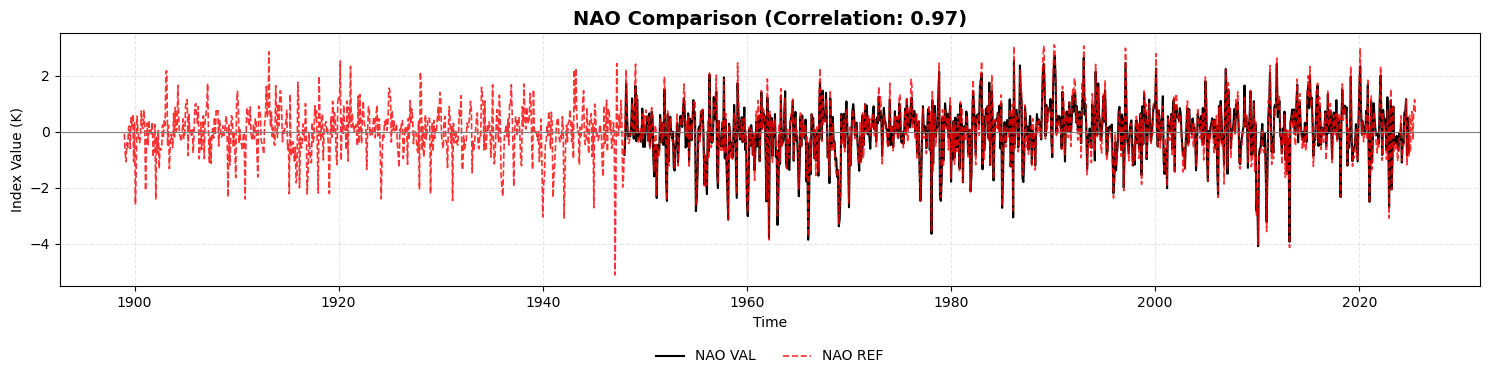

0.9681215328032794

In [23]:
utils_plotting_index.index_corr_plot(nao, nao_ref, 
                                     label1="NAO VAL", label2="NAO REF", 
                                     title="NAO Comparison")

## Compute

In [24]:
def compute_nao(slp: xr.DataArray,
                lat_bounds: tuple = (20, 80),
                lon_bounds: tuple = (-90, 40),
                time_mean: str = "monthly",
                clim_start: str = None,
                clim_end: str = None) -> tuple:
    """
    Compute the North Atlantic Oscillation (NAO) index as the leading EOF
    of sea-level pressure (SLP) anomalies over the Atlantic sector.

    The NAO index is defined as the principal component (PC1) of the leading
    Empirical Orthogonal Function (EOF1) of SLP anomalies over:
        20°–80°N, 90°W–40°E

    Positive NAO values correspond to a stronger-than-average pressure
    gradient between the Icelandic Low and Azores High, associated with
    enhanced westerlies and wetter/milder conditions over western Europe.

    Parameters
    ----------
    slp : xr.DataArray
        Sea-level pressure with dimensions (time, lat, lon).
        Coordinates must be named 'lat' and 'lon' (lon in [-180, 180] or [0, 360]).
        Units can be Pa or hPa — the anomaly computation is unit-agnostic.
    lat_bounds : tuple, optional
        (lat_min, lat_max) defining the Atlantic sector latitude range.
        Default: (20, 80) degrees North.
    lon_bounds : tuple, optional
        (lon_min, lon_max) in degrees East (negative = West).
        Default: (-90, 40), i.e. 90°W to 40°E.
    time_mean : str, optional
        Temporal grouping for anomaly computation.
        'monthly'  → remove monthly climatology (recommended)
        'annual'   → remove annual mean only
        'none'     → use raw SLP (not recommended)
        Default: 'monthly'
    clim_start : str, optional
        Start of the climatology reference period (inclusive), e.g. '1981-01-01'
        or '1981'. If None, uses the full time extent of the data.
        Must be parseable by pandas/xarray (ISO 8601 string or year string).
    clim_end : str, optional
        End of the climatology reference period (inclusive), e.g. '2010-12-31'
        or '2010'. If None, uses the full time extent of the data.
        Must be parseable by pandas/xarray (ISO 8601 string or year string).

    Returns
    -------
    nao_index : xr.DataArray
        Standardized NAO time series (dimensionless), shape (time,).
        Positive = enhanced pressure gradient (stronger westerlies).
    eof1 : xr.DataArray
        Leading EOF spatial pattern, shape (lat, lon).
    explained_variance : float
        Fraction of total variance explained by EOF1 (0–1).

    Notes
    -----
    Anomalies are always computed relative to the climatology window
    [clim_start, clim_end], but the returned NAO index covers the full
    time extent of the input ``slp``. This allows you to compute anomalies
    relative to, e.g., a 1981–2010 baseline while still getting a NAO index
    for a longer period such as 1950–2023.

    Examples
    --------
    >>> slp = xr.open_dataset("era5_slp.nc")["msl"]
    >>> # Standard WMO 1991-2020 reference period
    >>> nao, eof1, var_exp = compute_nao(slp, clim_start="1991", clim_end="2020")
    >>> print(f"EOF1 explains {var_exp*100:.1f}% of variance")

    >>> # Full-period climatology (default behaviour)
    >>> nao, eof1, var_exp = compute_nao(slp)
    """

    # ------------------------------------------------------------------ #
    # 1. Subset to the Atlantic sector
    # ------------------------------------------------------------------ #
    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds

    # Handle 0–360 longitude grids
    if float(slp.lon.max()) > 180:
        lon_min = lon_min % 360
        lon_max = lon_max % 360

    # Sort coordinates to ensure slice works correctly
    slp_atl = (slp
               .sortby("lat")
               .sortby("lon")
               .sel(lat=slice(lat_min, lat_max),
                    lon=slice(lon_min, lon_max)))

    if slp_atl.sizes["lat"] == 0 or slp_atl.sizes["lon"] == 0:
        raise ValueError(
            f"Atlantic sector subset is empty. Check lon convention. "
            f"lon range in data: [{float(slp.lon.min()):.1f}, {float(slp.lon.max()):.1f}]"
        )

    # ------------------------------------------------------------------ #
    # 2. Select climatology reference period
    #    Anomalies are defined relative to [clim_start, clim_end] but the
    #    full slp_atl time axis is retained so the NAO covers all input years.
    # ------------------------------------------------------------------ #
    if clim_start is not None or clim_end is not None:
        sel_kwargs = {}
        if clim_start is not None:
            sel_kwargs["time"] = slice(clim_start, clim_end)
        elif clim_end is not None:
            sel_kwargs["time"] = slice(None, clim_end)
        slp_clim = slp_atl.sel(**sel_kwargs)
        if slp_clim.sizes["time"] == 0:
            raise ValueError(
                f"Climatology window [{clim_start}, {clim_end}] yields no time steps. "
                f"Data time range: [{str(slp_atl.time.values[0])[:10]}, "
                f"{str(slp_atl.time.values[-1])[:10]}]"
            )
    else:
        slp_clim = slp_atl   # use full period as reference

    # ------------------------------------------------------------------ #
    # 3. Compute SLP anomalies
    #    Climatology is derived from slp_clim; anomalies are applied to
    #    the full slp_atl so the output spans the complete input period.
    # ------------------------------------------------------------------ #
    if time_mean == "monthly":
        climatology = slp_clim.groupby("time.month").mean("time")
        slp_anom = slp_atl.groupby("time.month") - climatology
    elif time_mean == "annual":
        climatology = slp_clim.mean("time")
        slp_anom = slp_atl - climatology
    elif time_mean == "none":
        slp_anom = slp_atl
    else:
        raise ValueError(f"time_mean must be 'monthly', 'annual', or 'none'. Got: '{time_mean}'")

    # ------------------------------------------------------------------ #
    # 4. Area weighting: weight by sqrt(cos(lat))
    #    Accounts for grid cell area shrinking toward the poles.
    # ------------------------------------------------------------------ #
    weights = np.sqrt(np.cos(np.deg2rad(slp_anom.lat)))  # xr.DataArray, dim='lat'
    slp_weighted = slp_anom * weights                     # broadcasts over (time, lat, lon)

    # ------------------------------------------------------------------ #
    # 5. Reshape to 2D for EOF analysis: (time, space)
    # ------------------------------------------------------------------ #
    nt = slp_weighted.sizes["time"]
    slp_2d = np.asarray(slp_weighted).reshape(nt, -1)    # (time, lat*lon)

    # Remove grid points that are NaN at any time step (e.g. land points)
    valid_mask = ~np.isnan(slp_2d).any(axis=0)
    slp_2d_valid = slp_2d[:, valid_mask]

    if slp_2d_valid.shape[1] == 0:
        raise ValueError("All spatial grid points contain NaN. Check your SLP data.")

    # ------------------------------------------------------------------ #
    # 6. SVD / EOF decomposition
    #    X = U @ diag(S) @ Vt
    #    EOF patterns → rows of Vt
    #    Principal components → columns of U scaled by S
    # ------------------------------------------------------------------ #
    slp_2d_centered = slp_2d_valid - slp_2d_valid.mean(axis=0)
    U, S, Vt = np.linalg.svd(slp_2d_centered, full_matrices=False)

    eof1_valid = Vt[0, :]       # leading spatial pattern (valid points only)
    pc1 = U[:, 0] * S[0]       # leading principal component (time series)

    explained_variance = float((S[0] ** 2) / np.sum(S ** 2))

    # ------------------------------------------------------------------ #
    # 7. Reconstruct full spatial EOF map (including NaN points)
    # ------------------------------------------------------------------ #
    nlat = slp_weighted.sizes["lat"]
    nlon = slp_weighted.sizes["lon"]
    eof1_full = np.full(nlat * nlon, np.nan)
    eof1_full[valid_mask] = eof1_valid
    eof1_full = eof1_full.reshape(nlat, nlon)

    # ------------------------------------------------------------------ #
    # 8. Sign convention: positive loading over the Azores High
    #    (35–45°N, 20°W–0°E) → standard NAO convention
    # ------------------------------------------------------------------ #
    lats = slp_anom.lat.values
    lons = slp_anom.lon.values

    azores_lat_mask = (lats >= 35) & (lats <= 45)
    # Handle both [-180,180] and [0,360] longitude grids
    if lons.max() > 180:
        azores_lon_mask = (lons >= 340) | (lons <= 360)  # ~20W–0E in 0–360
    else:
        azores_lon_mask = (lons >= -20) & (lons <= 0)

    azores_mean = np.nanmean(eof1_full[np.ix_(azores_lat_mask, azores_lon_mask)])

    if azores_mean < 0:
        eof1_full = -eof1_full
        pc1 = -pc1

    # ------------------------------------------------------------------ #
    # 9. Standardize PC1 → NAO index (zero mean, unit variance)
    # ------------------------------------------------------------------ #
    nao_index_values = (pc1 - pc1.mean()) / pc1.std()

    # ------------------------------------------------------------------ #
    # 10. Package as xarray objects
    # ------------------------------------------------------------------ #
    clim_range_str = (
        f"{clim_start or str(slp_atl.time.values[0])[:10]} to "
        f"{clim_end   or str(slp_atl.time.values[-1])[:10]}"
    )

    nao_index = xr.DataArray(
        nao_index_values,
        coords={"time": slp_anom.time},
        dims=["time"],
        name="NAO_index",
        attrs={
            "long_name": "North Atlantic Oscillation Index (PC-based)",
            "description": "Standardized PC1 of SLP anomalies, 20-80N 90W-40E",
            "units": "dimensionless (std dev)",
            "sign_convention": "Positive = stronger Azores High / Icelandic Low gradient",
            "explained_variance_fraction": explained_variance,
            "lat_bounds": str(lat_bounds),
            "lon_bounds": str(lon_bounds),
            "anomaly_method": time_mean,
            "climatology_period": clim_range_str,
        }
    )

    eof1_da = xr.DataArray(
        eof1_full,
        coords={"lat": slp_anom.lat, "lon": slp_anom.lon},
        dims=["lat", "lon"],
        name="EOF1",
        attrs={
            "long_name": "Leading EOF of SLP anomalies (NAO spatial pattern)",
            "explained_variance_fraction": explained_variance,
            "climatology_period": clim_range_str,
        }
    )

    return nao_index#, eof1_da, explained_variance

## VAL

In [27]:
nao_index_val = compute_nao(ncep_slp.slp)
nao_index_val

<xarray.DataArray 'NAO_index' (time: 923)> Size: 4kB
array([-4.77103204e-01,  1.49587899e-01,  1.91530108e+00,  6.49616003e-01,
       -2.24310666e-01, -3.23840469e-01, -3.70541185e-01, -2.27311492e-01,
        1.85181186e-01,  8.23392689e-01,  2.05389336e-01, -1.50513247e-01,
        1.03772712e+00,  2.04570723e+00, -1.97489694e-01,  1.18188083e+00,
       -3.10793370e-01, -4.71503198e-01, -2.56196946e-01, -6.08768836e-02,
       -4.55943197e-01,  4.49277133e-01, -4.48244452e-01,  3.73473853e-01,
       -1.81938604e-01,  5.24254918e-01,  3.26620370e-01,  5.58974206e-01,
       -4.01077390e-01,  4.09459621e-01, -7.20123231e-01, -2.11177438e-01,
        6.47331655e-01,  1.77822813e-01, -8.44958782e-01, -1.53821468e+00,
       -1.12831876e-01, -1.85334489e-01, -2.26620960e+00, -4.86220360e-01,
       -7.43809521e-01, -9.09894347e-01,  4.16440636e-01,  2.02583941e-03,
       -4.75851595e-01, -8.31453279e-02, -3.71938825e-01,  1.64768159e+00,
        6.63258791e-01, -1.43585312e+00, -2.37770605e+00,  6.32013857e-01,
       -1.16048813e+00,  1.91865861e-01,  3.54227662e-01, -1.49087474e-01,
       -3.26322675e-01, -4.10812885e-01, -1.20204937e+00, -1.32561290e+00,
       -7.15548247e-02, -1.50135383e-01,  4.76310372e-01, -1.11665547e+00,
       -4.42044348e-01, -1.93787401e-03,  3.86486113e-01,  2.22275555e-01,
        9.08185169e-02,  4.99130726e-01,  1.33183479e+00,  7.77163982e-01,
       -2.09842622e-01,  2.59292983e-02, -3.75923455e-01,  6.63716018e-01,
       -1.15576947e+00,  2.20408618e-01,  1.99202985e-01, -3.81698340e-01,
...
        1.45655525e+00,  3.80646557e-01,  5.56449413e-01,  8.93741071e-01,
        5.75863540e-01,  4.95781064e-01, -1.12975955e+00,  1.54546857e-01,
       -2.15285718e-01,  2.86229759e-01,  2.17811918e+00, -2.02978268e-01,
       -1.15301669e+00, -8.37803721e-01, -8.41874361e-01, -4.46208298e-01,
        1.94748476e-01, -8.03568780e-01, -9.86814141e-01,  3.97303611e-01,
        1.99659741e+00,  2.75530243e+00,  9.73938644e-01, -9.44699496e-02,
        3.05277795e-01, -3.28402191e-01, -1.28974970e-02, -1.17442600e-01,
        6.84073448e-01, -1.27069026e-01,  1.84516108e+00, -7.11268067e-01,
       -2.19764113e+00, -8.50518644e-01,  1.26372635e+00, -1.10771394e+00,
       -1.93826452e-01,  7.85152435e-01,  2.52595782e-01, -1.58908516e-02,
       -2.05933765e-01, -4.32601213e-01, -7.67220929e-02, -3.49799335e-01,
        1.55051160e+00,  2.42012835e+00,  5.87964058e-01, -8.63566458e-01,
        7.28886545e-01,  1.77594483e-01,  2.87997156e-01,  1.44368308e-02,
       -7.64828265e-01,  8.69696558e-01,  1.62258044e-01, -2.65962648e+00,
        5.62095404e-01,  1.48991573e+00, -1.95545089e+00, -1.07056367e+00,
        8.48132789e-01, -7.10130870e-01, -3.90821815e-01, -4.95132357e-01,
       -2.24952683e-01, -8.02448273e-01, -5.84750712e-01,  5.19882292e-02,
        9.72134843e-02,  6.53530538e-01, -9.73846138e-01, -3.31762493e-01,
       -4.99466062e-01,  4.52333212e-01,  5.14328778e-01,  1.13277709e+00,
       -9.42919195e-01,  1.09145120e-01, -6.44965768e-01], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2024-11-01
Attributes:
    long_name:                    North Atlantic Oscillation Index (PC-based)
    description:                  Standardized PC1 of SLP anomalies, 20-80N 9...
    units:                        dimensionless (std dev)
    sign_convention:              Positive = stronger Azores High / Icelandic...
    explained_variance_fraction:  0.31990868249469656
    lat_bounds:                   (20, 80)
    lon_bounds:                   (-90, 40)
    anomaly_method:               monthly
    climatology_period:           1948-01-01 to 2024-11-01

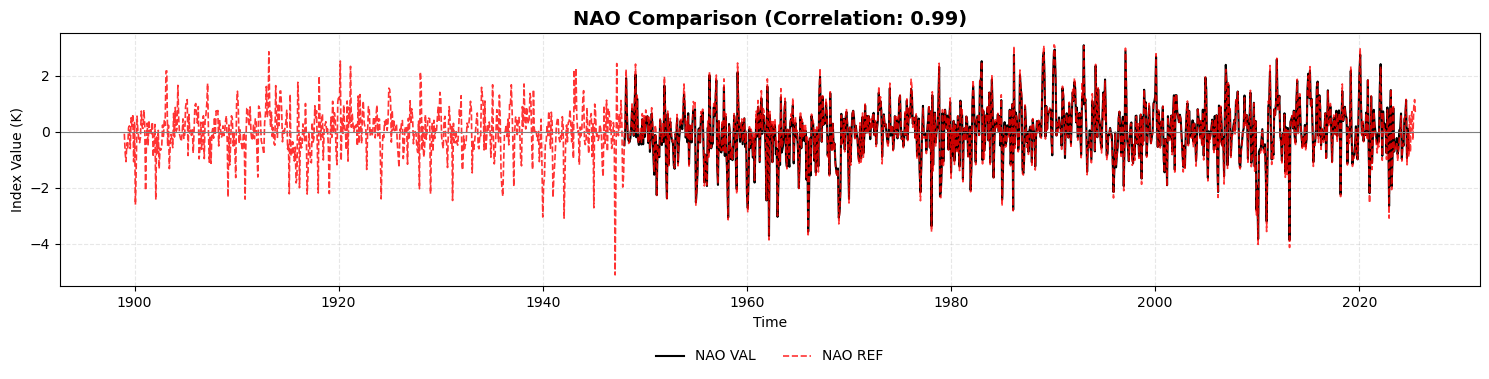

0.9935895634369367

In [28]:
utils_plotting_index.index_corr_plot(nao_index_val, nao_ref, 
                                     label1="NAO VAL", label2="NAO REF", 
                                     title="NAO Comparison")

## LT

In [ ]:
nao_index_lt = compute_nao(era5_slp.msl, clim_start='1940-12-01', clim_end='2024-11-01')
nao_index_lt

In [ ]:
utils_plotting_index.index_corr_plot(nao_index_val, nao_index_lt, 
                                     label1="NAO VAL", label2="NAO LT [ERA5]", 
                                     title="NAO Comparison")

## ST

In [ ]:
nao_index_st = compute_nao(era5_slp.msl.sel(time=slice('1980-12-01', '2024-11-30')), clim_start='1980-12-01', clim_end='2024-11-30')
nao_index_st

In [ ]:
utils_plotting_index.index_corr_plot(nao_index_val, nao_index_st, 
                                     label1="NAO VAL", label2="NAO ST [ERA5]", 
                                     title="NAO Comparison")

# NPI

Data: https://climatedataguide.ucar.edu/climate-data/north-pacific-np-index-trenberth-and-hurrell-monthly-and-winter 

Definition: 
Main content
The North Pacific Index (NP index or NPI) is the area-weighted sea level pressure over the region 30°N-65°N, 160°E-140°W. The NP index is defined to measure interannual to decadal variations in the atmospheric circulation. The dominant atmosphere-ocean relation in the North Pacific is one where atmospheric changes lead changes in sea surface temperatures by one to two months. However, strong ties exist with events in the tropical Pacific, with changes in tropical Pacific SSTs leading SSTs in the north Pacific by three months.

References: 
* Trenberth and Hurrell (1994): Decadal atmosphere-ocean variations in the Pacific, Climate Dynamics 9:303-319
* Wallace, J. M., D. S. Gutzler, 1981: Teleconnections in the Geopotential Height Field during the Northern Hemisphere Winter. Mon.Weather Rev., 109, 784-812.

## REF

In [ ]:
npi_ref = xr.open_dataset(index_filepath + "npi_ndex_monthly.nc").np_index#.chunk({'time': 100})
npi_ref

npi_ref_std = utils_general.standardize_by_month(npi_ref.sel(time=slice('1940-12-01', '2024-11-01')))

In [ ]:
npi_ref

## COMPUTE

In [ ]:
import numpy as np
import xarray as xr

def compute_npi(
    slp,
    lat=None,
    lon=None,
    fill_value: float = None,
    lat_min: float = 30.0,
    lat_max: float = 65.0,
    lon_min: float = 160.0,
    lon_max: float = 220.0,
):
    # Handle xarray input
    da_slp = slp if isinstance(slp, xr.DataArray) else None
    if da_slp is not None:
        lat = slp.lat.values
        lon = slp.lon.values
        slp = slp.values

    slp = np.asarray(slp, dtype=float)
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)

    scalar_input = slp.ndim == 2
    if scalar_input:
        slp = slp[np.newaxis]

    lon360 = np.where(lon < 0, lon + 360.0, lon)
    lat_idx = (lat >= lat_min) & (lat <= lat_max)
    lon_idx = (lon360 >= lon_min) & (lon360 <= lon_max) if lon_min <= lon_max \
              else (lon360 >= lon_min) | (lon360 <= lon_max)

    slp_d = slp[:, lat_idx, :][:, :, lon_idx]

    if fill_value is not None:
        slp_d = np.where(slp_d == fill_value, np.nan, slp_d)

    w = np.cos(np.deg2rad(lat[lat_idx]))[np.newaxis, :, np.newaxis]

    wslp = np.where(np.isnan(slp_d), 0.0, w * slp_d)
    wsum = np.where(np.isnan(slp_d), 0.0, np.broadcast_to(w, slp_d.shape))

    npi = wslp.sum(axis=(1, 2)) / wsum.sum(axis=(1, 2))

    # Return xarray output
    units = da_slp.attrs.get('units', '') if da_slp is not None else ''
    if scalar_input:
        return xr.DataArray(float(npi[0]), attrs={'long_name': 'North Pacific Index'})
    else:
        return xr.DataArray(
            npi,
            coords={'time': da_slp['time']} if da_slp is not None else {},
            dims=['time'],
            attrs={
                'long_name': 'North Pacific Index',
                'units': units,
                'description': (
                    'Area-weighted mean SLP over 30°N–65°N, 160°E–140°W '
                    '(Trenberth & Hurrell 1994).'
                ),
            }
        )

## VAL

In [ ]:
# npi_index_val = compute_npi(ncep_slp.slp)
# npi_index_val

# npi_index_val_std = utils_general.standardize_by_month(npi_index_val.sel(time=slice('1940-12-01', '2024-11-01')))

In [ ]:
npi_index_val = utils_general.standardize_by_month(compute_npi(ncep_slp.slp))
npi_index_val

# npi_index_val_std = utils_general.standardize_by_month(npi_index_val.sel(time=slice('1940-12-01', '2024-11-01')))

In [ ]:
utils_plotting_index.index_corr_plot(npi_index_val, 
                                     npi_ref_std, 
                                     label1="NPI Computation", label2="NPI", 
                                     title="Index Comparison")

In [ ]:
utils_plotting_index.index_corr_plot(npi_index_val,
                                     npi_ref_std,
                                     label1="NPI Computation [STD]", label2="NPI[STD]", 
                                     title="NPI Comparison")

# utils_plotting_index.index_corr_plot(utils_general.standardize_by_month(npi_index_val.sel(time=slice('1940-12-01', '2024-11-01'))), 
#                                      utils_general.standardize_by_month(npi_ref.sel(time=slice('1940-12-01', '2024-11-01'))), 
#                                      label1="NPI Computation [STD]", label2="NPI[STD]", 
#                                      title="NPI Comparison")

## LT

In [ ]:
npi_index_lt = utils_general.standardize_by_month(compute_npi(era5_slp.msl))
npi_index_lt

In [ ]:
utils_plotting_index.index_corr_plot(npi_index_lt,
                                     npi_index_val_std,
                                     label1="NPI Computation [LT]", label2="NPI VAL[STD]", 
                                     title="NPI Comparison")

## ST

In [ ]:
npi_index_st = utils_general.standardize_by_month(compute_npi(era5_slp.msl.sel(time=slice('1980-12-01', '2024-11-30'))))
npi_index_st

In [ ]:
utils_plotting_index.index_corr_plot(npi_index_st,
                                     npi_index_val,
                                     label1="NPI Computation [ST]", label2="NPI VAL[STD]", 
                                     title="NPI Comparison")

# ALL HGT AND SLP 

In [ ]:
hgt_slp_indices = [
    
    ("AO",   ao_index_lt,   ao_index_st),
    ("AAO",  aao_index_lt,  aao_index_st),
    ("SAM",  sam_index_lt,  sam_index_st),
    ("NAO",  nao_index_lt,  nao_index_st),
    ("NPI",  npi_index_lt,  npi_index_st),
]

for name, lt, st in hgt_slp_indices:
    print(f"{name}: lt={len(lt.time)}, st={len(st.time)}")

In [ ]:
ao_index_lt

In [ ]:
atm_val_indices = {
    "AO":  ao_index_val,
    "AAO": aao_index_val,
    "SAM": sam_index_val,
    "NAO": nao_index_val,
    "NPI": npi_index_val,
}
for name, da in atm_val_indices.items():
    print(f"{name}: {len(da.time)}")

In [ ]:
ao_index_val

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 20))

for row, (name, val, ref) in enumerate(hgt_slp_indices):
    ax = axes[row]

    # Align on common times
    common_times = np.intersect1d(val.time.values, ref.time.values)
    val_aligned = val.sel(time=common_times)
    ref_aligned = ref.sel(time=common_times)

    # Joint non-NaN mask
    mask = ~(np.isnan(val_aligned.values) | np.isnan(ref_aligned.values))
    val_np = val_aligned.values[mask]
    ref_np = ref_aligned.values[mask]

    # Compute correlation
    if len(val_np) >= 2:
        corr, _ = pearsonr(val_np, ref_np)
        corr_str = f"{corr:.2f}"
    else:
        corr_str = "N/A"

    # Plot both series
    ax.plot(val.time.values, val.values, color="black", linewidth=0.8, label="VAL")
    ax.plot(ref.time.values, ref.values, color="red",   linewidth=0.8, linestyle="--", label="Ref")
    ax.axhline(0, color="gray", linewidth=0.6, linestyle="-")
    ax.set_title(f"{name} (r = {corr_str})", fontweight="bold")
    ax.set_ylabel("Index Value")

    if row == len(hgt_slp_indices) - 1:
        ax.set_xlabel("Time")
    else:
        ax.tick_params(labelbottom=False)

# Single legend at the bottom
handles = [
    plt.Line2D([0], [0], color="black", linewidth=0.8,                 label="INTERMEDIATE TERM"),
    plt.Line2D([0], [0], color="red",   linewidth=0.8, linestyle="--", label="SHORT TERM"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.01),
           ncol=2, frameon=False, fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.06)
plt.show()

In [ ]:
lt_list = []
st_list = []

for name, lt, st in hgt_slp_indices:
    lt_seasonal = lt.resample(time="QS-DEC").mean().rename(name)
    st_seasonal = st.resample(time="QS-DEC").mean().rename(name)
    
    lt_list.append(lt_seasonal)
    st_list.append(st_seasonal)

atm_index_lt_combined = xr.merge(lt_list)
atm_index_st_combined = xr.merge(st_list)

print(atm_index_lt_combined)
print(atm_index_st_combined)

In [ ]:
#atm_index_lt_combined.to_netcdf(output_filepath + 'ATM_INDEX_LT.nc')

In [ ]:
#atm_index_st_combined.to_netcdf(output_filepath + 'ATM_INDEX_ST.nc')

In [ ]:
val_list = []

for name, da in atm_val_indices.items():
    val_seasonal = da.resample(time="QS-DEC").mean().rename(name)
    val_list.append(val_seasonal)

atm_index_val_combined = xr.merge(val_list)
atm_index_val_combined
#atm_index_val_combined.to_netcdf("atm_index_val_combined.nc")

In [ ]:
atm_index_val_combined.to_netcdf(output_filepath + 'ATM_INDEX_VAL.nc')

In [ ]:
atm_index_val_combined.SAM#.plot()

In [ ]:
atm_index_val_combined.AO.plot()
atm_index_val_combined.SAM.plot()
atm_index_val_combined.AAO.plot()
atm_index_val_combined.NAO.plot()
atm_index_val_combined.NPI.plot()

In [ ]:
# fig, axes = plt.subplots(5, 1, figsize=(12, 20))

# names = list(atm_index_lt_combined.data_vars)

# for row, name in enumerate(names):
#     ax = axes[row]

#     val = atm_index_lt_combined[name]
#     ref = atm_index_st_combined[name]

#     # Align on common times
#     common_times = np.intersect1d(val.time.values, ref.time.values)
#     val_aligned = val.sel(time=common_times)
#     ref_aligned = ref.sel(time=common_times)

#     # Joint non-NaN mask
#     mask = ~(np.isnan(val_aligned.values) | np.isnan(ref_aligned.values))
#     val_np = val_aligned.values[mask]
#     ref_np = ref_aligned.values[mask]

#     # Compute correlation
#     if len(val_np) >= 2:
#         corr, _ = pearsonr(val_np, ref_np)
#         corr_str = f"{corr:.2f}"
#     else:
#         corr_str = "N/A"

#     # Plot
#     ax.plot(val.time.values, val.values, color="black", linewidth=0.8)
#     ax.plot(ref.time.values, ref.values, color="red",   linewidth=0.8, linestyle="--")
#     ax.axhline(0, color="gray", linewidth=0.6, linestyle="-")
#     ax.set_title(f"{name} (r = {corr_str})", fontweight="bold")
#     ax.set_ylabel("Index Value")

#     if row == len(names) - 1:
#         ax.set_xlabel("Time")
#     else:
#         ax.tick_params(labelbottom=False)

# handles = [
#     plt.Line2D([0], [0], color="black", linewidth=0.8,                 label="LT"),
#     plt.Line2D([0], [0], color="red",   linewidth=0.8, linestyle="--", label="ST"),
# ]
# fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.01),
#            ncol=2, frameon=False, fontsize=12)

# plt.tight_layout()
# plt.subplots_adjust(bottom=0.06)
# plt.show()

# Plot all LT and ST Index

In [ ]:
INDEX_LT = xr.open_dataset(output_filepath + 'SST_INDEX_LT.nc')
INDEX_ST = xr.open_dataset(output_filepath + 'SST_INDEX_ST.nc')

In [ ]:
INDEX_LT

In [ ]:
left_indices = [
    ("ENSO", INDEX_LT.ENSO, INDEX_LT.ENSO),
    ("PDO",   INDEX_LT.PDO,  INDEX_LT.PDO),
    ("AMO",   INDEX_LT.AMO,  INDEX_LT.AMO),
    ("IOD",  INDEX_LT.IOD,  INDEX_LT.IOD),
    ("TPI",  INDEX_LT.TPI,  INDEX_LT.TPI),
]

left_indices

In [ ]:
right_indices = [
    ("AO",   ao_index_lt,   ao_index_st),
    ("AAO",  aao_index_lt,  aao_index_st),
    ("SAM",  sam_index_lt,  sam_index_st),
    ("NAO",  nao_index_lt,  nao_index_st),
    ("NPI",  npi_index_lt,  npi_index_st),
]


In [ ]:
# left_indices = [
#     ("ENSO", enso_index_lt, enso_index_st),
#     ("PDV",  pdo_index_lt,  pdo_index_st),
#     ("AMV",  amo_index_lt,  amo_index_st),
#     ("IOD",  iod_index_lt,  iod_index_st),
#     ("TPI",  tpi_index_lt,  tpi_index_st),
# ]

# right_indices = [
#     ("AO",   ao_index_lt,   ao_index_st),
#     ("AAO",  aao_index_lt,  aao_index_st),
#     ("SAM",  sam_index_lt,  sam_index_st),
#     ("NAO",  nao_index_lt,  nao_index_st),
#     ("NPI",  npi_index_lt,  npi_index_st),
# ]

# fig, axes = plt.subplots(5, 2, figsize=(20, 20))

# for col, index_group in enumerate([left_indices, right_indices]):
#     lt_color = "black" if col == 0 else "darkblue"
    
#     for row, (name, val, ref) in enumerate(index_group):
#         ax = axes[row, col]
        
#         # Align on common times
#         common_times = np.intersect1d(val.time.values, ref.time.values)
#         val_aligned = val.sel(time=common_times)
#         ref_aligned = ref.sel(time=common_times)
        
#         # Joint non-NaN mask
#         mask = ~(np.isnan(val_aligned.values) | np.isnan(ref_aligned.values))
#         val_np = val_aligned.values[mask]
#         ref_np = ref_aligned.values[mask]
        
#         # Compute correlation
#         if len(val_np) >= 2:
#             corr, _ = pearsonr(val_np, ref_np)
#             corr_str = f"{corr:.2f}"
#         else:
#             corr_str = "N/A"
        
#         # Plot
#         ax.plot(val.time.values, val.values, color=lt_color, linewidth=0.8)
#         ax.plot(ref.time.values, ref.values, color="red", linewidth=0.8, linestyle="--")
#         ax.axhline(0, color="gray", linewidth=0.6, linestyle="-")
#         ax.set_title(f"{name}", fontweight="bold", fontsize = 20)
#         ax.set_ylabel("Index Value", fontsize = 15)
        
#         if row == 4:
#             ax.set_xlabel("Time")
#         else:
#             ax.tick_params(labelbottom=False)

# # Three-entry legend
# handles = [
#     plt.Line2D([0], [0], color="black", linewidth=2, label="LONG-TERM (LT)"),
#     plt.Line2D([0], [0], color="darkblue",  linewidth=2, label="INTERMEDIATE TERM (IT)"),
#     plt.Line2D([0], [0], color="red",   linewidth=2, linestyle="--", label="SHORT TERM (ST)"),
# ]
# fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.01),
#            ncol=3, frameon=False, fontsize=18)

# plt.tight_layout()
# plt.subplots_adjust(bottom=0.06)
# plt.show()

## Save ST and LT 

In [ ]:
# left_indices = [
#     ("ENSO", enso_index_lt, enso_index_st),
#     ("PDO",  pdo_index_lt,  pdo_index_st),
#     ("AMO",  amo_index_lt,  amo_index_st),
#     ("IOD",  iod_index_lt,  iod_index_st),
#     ("TPI",  tpi_index_lt,  tpi_index_st),
# ]

# right_indices = [
#     ("AO",   ao_index_lt,   ao_index_st),
#     ("AAO",  aao_index_lt,  aao_index_st),
#     ("SAM",  sam_index_lt,  sam_index_st),
#     ("NAO",  nao_index_lt,  nao_index_st),
#     ("NPI",  npi_index_lt,  npi_index_st),
# ]

# all_indices = left_indices + right_indices        # if pandas Series
# time_lt = enso_index_lt.coords["time"].values  # if xr.DataArray but need raw values
# time_st = enso_index_st.coords["time"].values  # if xr.DataArray but need raw values

# data_vars = {}
# for name, lt, st in all_indices:
#     stacked = xr.concat(
#         [lt, st],
#         dim=xr.DataArray(["longer_term", "short_term"], dims=["term"])
#     )
#     data_vars[name] = stacked

# # xr.Dataset will automatically align on union and fill gaps with NaN
# lt_st_stack = xr.Dataset(data_vars).sortby("time")
# lt_st_stack 
# lt_st_stack.to_netcdf(output_filepath + 'ALL_INDEX_LT_ST.nc')

In [ ]:
# fig, axes = plt.subplots(5, 2, figsize=(20, 20))

# for col, index_group in enumerate([left_indices, right_indices]):
#     lt_color = "black" if col == 0 else "darkblue"

#     for row, (name, _, _) in enumerate(index_group):
#         ax = axes[row, col]

#         lt = lt_st_stack[name].sel(term="longer_term").dropna("time")
#         st = lt_st_stack[name].sel(term="short_term").dropna("time")

#         # Align on common times
#         common_times = np.intersect1d(lt.time.values, st.time.values)
#         lt_aligned = lt.sel(time=common_times)
#         st_aligned = st.sel(time=common_times)

#         # Joint non-NaN mask
#         mask = ~(np.isnan(lt_aligned.values) | np.isnan(st_aligned.values))
#         lt_np = lt_aligned.values[mask]
#         st_np = st_aligned.values[mask]

#         # Compute correlation
#         if len(lt_np) >= 2:
#             corr, _ = pearsonr(lt_np, st_np)
#             corr_str = f"r = {corr:.2f}"
#         else:
#             corr_str = "N/A"

#         # Plot
#         ax.plot(lt.time.values, lt.values, color=lt_color, linewidth=0.8)
#         ax.plot(st.time.values, st.values, color="red", linewidth=0.8, linestyle="--")
#         ax.axhline(0, color="gray", linewidth=0.6, linestyle="-")
#         #ax.set_title(f"{name}  ({corr_str})", fontweight="bold", fontsize=20)
#         ax.set_title(f"{name})", fontweight="bold", fontsize=20)
#         ax.set_ylabel("Index Value", fontsize=15)

#         if row == 4:
#             ax.set_xlabel("Time")
#         else:
#             ax.tick_params(labelbottom=False)

# # Three-entry legend
# handles = [
#     plt.Line2D([0], [0], color="black",    linewidth=2, label="LONG-TERM (LT)"),
#     plt.Line2D([0], [0], color="darkblue", linewidth=2, label="INTERMEDIATE TERM (IT)"),
#     plt.Line2D([0], [0], color="red",      linewidth=2, linestyle="--", label="SHORT TERM (ST)"),
# ]
# fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.01),
#            ncol=3, frameon=False, fontsize=18)
# plt.tight_layout()
# plt.subplots_adjust(bottom=0.06)
# plt.show()

# Load and Plot All Indexes

## Timeseries

In [ ]:
ds = xr.open_dataset(output_filepath + 'ALL_INDEX_LT_ST.nc').sel(time = slice('1901-12-01', '2024-11-01'))

left_names  = ["ENSO", "PDO", "AMO", "IOD", "TPI"]
right_names = ["AO",   "AAO", "SAM", "NAO", "NPI"]
all_names   = left_names + right_names

In [ ]:
# LT_COL    = "#1a1a2e"
# IT_COL    = "#034daf"
# ST_COL    = "#e26d00" ##b30000

# ZERO_COL  = "#bbbbbb"
# BG        = "white"
# PANEL_BG  = "#fafafa"
# LABEL_COL = "#444444"
# TITLE_COL = "#111111"
# VLINE_COL = "#cccccc"

# X_MIN = np.datetime64("1900-01-01")
# X_MAX = np.datetime64("2024-12-01")
# decade_years = pd.date_range("1900", "2026", freq="10YS").values

# fig = plt.figure(figsize=(22, 26), facecolor=BG)
# gs  = gridspec.GridSpec(10, 1, hspace=0.08, figure=fig,
#                         left=0.09, right=0.98, top=0.95, bottom=0.06)

# axes = []
# for i, name in enumerate(all_names):
#     ax = fig.add_subplot(gs[i]) if i == 0 else fig.add_subplot(gs[i], sharex=axes[0])
#     axes.append(ax)
    
#     ax.set_facecolor(BG)
#     #ax.set_facecolor(PANEL_BG)
#     # for spine in ax.spines.values():
#     #     spine.set_edgecolor("#dddddd")
#     #     spine.set_linewidth(0.7)

#     is_left  = name in left_names
#     line_col = LT_COL if is_left else IT_COL

#     lt = ds[name].sel(term="longer_term").dropna("time")
#     st = ds[name].sel(term="short_term").dropna("time")

#     # decade vlines
#     for dv in decade_years:
#         ax.axvline(dv, color=VLINE_COL, linewidth=0.85, zorder=1, linestyle = '-.')

#     ax.plot(lt.time.values, lt.values, color=line_col, linewidth=1.25, zorder=3)
#     ax.plot(st.time.values, st.values, color=ST_COL, linewidth=1.5,
#             #linestyle="--", alpha=0.65, 
#             zorder=4)
#     #ax.axhline(0, color=ZERO_COL, linewidth=0.7, zorder=2)
#     ax.axhline(0, color=ZERO_COL, linewidth=1.25, zorder=2) # alpha = 0.65,

#     ax.set_xlim(X_MIN, X_MAX)

#     ax.yaxis.set_minor_locator(AutoMinorLocator(2))
#     ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # 1 decimal place
#     ax.tick_params(axis="y", colors=LABEL_COL, labelsize=18,
#                    which="both", length=2.5, direction="in")
#     ax.tick_params(axis="x", which="both", length=3, direction="in",
#                    labelbottom=False, colors=LABEL_COL, labelsize=15)

#     # index name: rotated 90°, colour matched to index type
#     ax.set_ylabel(name, fontsize=20, fontweight="bold", color=LT_COL,
#                   rotation=90, labelpad=10, va="center")

# # x-axis label on bottom panel only
# axes[-1].tick_params(axis="x", labelbottom=True, labelsize=20, colors=LABEL_COL)
# axes[-1].set_xlabel("Year", fontsize=25, color=LABEL_COL, labelpad=6, fontweight = 'bold')

# # divider line between ocean and atmosphere sections
# y_divider = (gs[4].get_position(fig).y0 + gs[5].get_position(fig).y1) / 2
# fig.add_artist(plt.Line2D([0.09, 0.98], [y_divider, y_divider],
#                            transform=fig.transFigure,
#                            color="#cccccc", linewidth=1.2))

# # section labels on left margin, colour matched
# fig.text(0.045, (gs[0].get_position(fig).y1 + gs[4].get_position(fig).y0) / 2,
#          "Ocean-based", fontsize=25, color=LT_COL,
#          va="center", ha="center", rotation=90, fontweight = 'bold')
# fig.text(0.045, (gs[5].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
#          "Atmosphere-based", fontsize=25, color=LT_COL,
#          va="center", ha="center", rotation=90, fontweight = 'bold')

# # legend
# handles = [
#     plt.Line2D([0],[0], color=LT_COL, linewidth=3,            label="Long Term (LT)"),
#     plt.Line2D([0],[0], color=IT_COL, linewidth=3,            label="Intermediate Term (IT)"),
#     plt.Line2D([0],[0], color=ST_COL, linewidth=3.5,          label="Short Term (ST)"), # ls="--",
# ]
# fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.95),
#            ncol=3, frameon=False, fontsize=22)

# #plt.tight_layout()
# plt.show()

In [ ]:
LT_COL    = "#1a1a2e"
IT_COL    = "#034daf"
ST_COL    = "#e26d00" ##b30000
ZERO_COL  = "#bbbbbb"
BG        = "white"
PANEL_BG  = "#fafafa"
LABEL_COL = "#444444"
TITLE_COL = "#111111"
VLINE_COL = "#cccccc"
X_MIN = np.datetime64("1900-01-01")
X_MAX = np.datetime64("2024-12-01")
decade_years = pd.date_range("1900", "2026", freq="10YS").values
fig = plt.figure(figsize=(22, 26), facecolor=BG)
gs  = gridspec.GridSpec(10, 1, hspace=0.08, figure=fig,
                        left=0.09, right=0.94, top=0.95, bottom=0.06)
axes = []
for i, name in enumerate(all_names):
    ax = fig.add_subplot(gs[i]) if i == 0 else fig.add_subplot(gs[i], sharex=axes[0])
    axes.append(ax)

    ax.set_facecolor(BG)
    #ax.set_facecolor(PANEL_BG)
    # for spine in ax.spines.values():
    #     spine.set_edgecolor("#dddddd")
    #     spine.set_linewidth(0.7)
    is_left  = name in left_names
    line_col = LT_COL if is_left else IT_COL
    lt = ds[name].sel(term="longer_term").dropna("time")
    st = ds[name].sel(term="short_term").dropna("time")
    # decade vlines
    for dv in decade_years:
        ax.axvline(dv, color=VLINE_COL, linewidth=0.85, zorder=1, linestyle = '-.')
    ax.plot(lt.time.values, lt.values, color=line_col, linewidth=1.25, zorder=3)
    ax.plot(st.time.values, st.values, color=ST_COL, linewidth=1.5,
            #linestyle="--", alpha=0.65,
            zorder=4)
    #ax.axhline(0, color=ZERO_COL, linewidth=0.7, zorder=2)
    ax.axhline(0, color=ZERO_COL, linewidth=1.25, zorder=2) # alpha = 0.65,
    ax.set_xlim(X_MIN, X_MAX)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # 1 decimal place
    ax.tick_params(axis="y", colors=LABEL_COL, labelsize=18,
                   which="both", length=2.5, direction="in")
    ax.tick_params(axis="x", which="both", length=3, direction="in",
                   labelbottom=False, colors=LABEL_COL, labelsize=15)

    # index name: inside the panel, top-left, colour matched to index type
    # ax.text(0.01, 0.92, name, transform=ax.transAxes,
    #         fontsize=20, fontweight="bold", color=LT_COL,
    #         ha="left", va="bottom")
    
    # index name: inside the panel, bottom-left, colour matched to index type
    ax.text(0.01, 0.08, name, transform=ax.transAxes,
            fontsize=20, fontweight="bold", color=LT_COL,
            ha="left", va="bottom")

# x-axis label on bottom panel only
axes[-1].tick_params(axis="x", labelbottom=True, labelsize=20, colors=LABEL_COL)
axes[-1].set_xlabel("Year", fontsize=25, color=LABEL_COL, labelpad=6, fontweight = 'bold')

# divider line between ocean and atmosphere sections
y_divider = (gs[4].get_position(fig).y0 + gs[5].get_position(fig).y1) / 2
fig.add_artist(plt.Line2D([0.09, 0.94], [y_divider, y_divider],
                           transform=fig.transFigure,
                           color="#cccccc", linewidth=1.5))

# # section labels moved to the right margin, colour matched
# fig.text(0.965, (gs[0].get_position(fig).y1 + gs[4].get_position(fig).y0) / 2,
#          "Ocean-based", fontsize=25, color=LT_COL,
#          va="center", ha="center", rotation=-90, fontweight = 'bold')
# fig.text(0.965, (gs[5].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
#          "Atmosphere-based", fontsize=25, color=LT_COL,
#          va="center", ha="center", rotation=-90, fontweight = 'bold')

# section labels on left margin, colour matched
fig.text(0.055, (gs[0].get_position(fig).y1 + gs[4].get_position(fig).y0) / 2,
         "Ocean-based", fontsize=30, color=LT_COL,
         va="center", ha="center", rotation=90, fontweight = 'bold')
fig.text(0.055, (gs[5].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
         "Atmosphere-based", fontsize=30, color=LT_COL,
         va="center", ha="center", rotation=90, fontweight = 'bold')

# single shared Z-score label on the left
fig.text(0.05, (gs[0].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
         "Z-score", fontsize=25, color=LABEL_COL,
         va="center", ha="center", rotation=90, fontweight = 'bold')

# legend
handles = [
    plt.Line2D([0],[0], color=LT_COL, linewidth=3,            label="Long Term (LT)"),
    plt.Line2D([0],[0], color=IT_COL, linewidth=3,            label="Intermediate Term (IT)"),
    plt.Line2D([0],[0], color=ST_COL, linewidth=3.5,          label="Short Term (ST)"), # ls="--",
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.95),
           ncol=3, frameon=False, fontsize=22)
#plt.tight_layout()
plt.show()

## Correlations

In [ ]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def pairwise_corr(ds, names, term):
    n = len(names)
    R = np.full((n, n), np.nan)
    P = np.full((n, n), np.nan)
    for i, a in enumerate(names):
        for j, b in enumerate(names):
            x = ds[a].sel(term=term).dropna("time")
            y = ds[b].sel(term=term).dropna("time")
            t_common = np.intersect1d(x.time.values, y.time.values)
            if len(t_common) < 10:
                continue
            xi = x.sel(time=t_common).values
            yi = y.sel(time=t_common).values
            r, p = pearsonr(xi, yi)
            R[i, j] = r
            P[i, j] = p
    return R, P

# --- mask upper triangle, keep diagonal ---
def mask_upper(R, P):
    n = R.shape[0]
    Rm, Pm = R.copy(), P.copy()
    for i in range(n):
        for j in range(i + 1, n):   # strict upper triangle
            Rm[i, j] = np.nan
            Pm[i, j] = np.nan
    return Rm, Pm

LT_COL    = "#1a1a2e"
IT_COL    = "#034daf"
ST_COL    = "#e26d00"
BG        = "white"
LABEL_COL = "#444444"

panels = [
    ("LT  —  SST-based",      left_names,  "longer_term", LT_COL),
    ("IT  —  Atmosphere-based", right_names, "longer_term", IT_COL),
    ("ST  —  All indices",      all_names,   "short_term",  ST_COL),
]

fig = plt.figure(figsize=(22, 8), facecolor=BG, dpi=300)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.25,
                        left=0.05, right=0.94, top=0.88, bottom=0.18)

last_im = None
for col, (title, names, term, tcol) in enumerate(panels):
    R, P   = pairwise_corr(ds, names, term)
    R, P   = mask_upper(R, P)
    n      = len(names)
    ax     = fig.add_subplot(gs[col])

    # blank background so masked cells are white
    ax.set_facecolor(BG)
    last_im = ax.imshow(R, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    
    # fs = 30 if n == 5 else 13
    # for i in range(n):
    #     for j in range(n):
    #         if np.isnan(R[i, j]):
    #             continue
    #         r_val  = R[i, j]
    #         sig    = (not np.isnan(P[i, j])) and P[i, j] < 0.05
    #         txt_col = "white" if abs(r_val) > 0.55 else "#333333"
    #         fw      = "bold" if sig else "normal"
    #         ax.text(j, i, f"{r_val:.2f}",
    #                 ha="center", va="center", fontsize=13,
    #                 color=txt_col, fontweight=fw)
    fs = 17 if n == 5 else 13
    for i in range(n):
        for j in range(n):
            if np.isnan(R[i, j]):
                continue
            r_val  = R[i, j]
            sig    = (not np.isnan(P[i, j])) and P[i, j] < 0.05
            txt_col = "white" if abs(r_val) > 0.55 else "#333333"
            fw      = "bold" if sig else "normal"
            ax.text(j, i, f"{r_val:.2f}",
                    ha="center", va="center", fontsize=fs,
                    color=txt_col, fontweight=fw)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=45, ha="right",
                       fontsize=13, color=LABEL_COL, fontweight="bold")
    ax.set_yticklabels(names, fontsize=13, color=LABEL_COL, fontweight="bold")
    ax.set_title(title, fontsize=15, fontweight="bold", color=tcol, pad=10)

# single colorbar anchored to the right of the figure
cax = fig.add_axes([0.955, 0.18, 0.012, 0.70])
cb  = fig.colorbar(last_im, cax=cax)
cb.ax.tick_params(labelsize=15, colors=LABEL_COL, length=2)
cb.set_label("Pearson's Correlation \n (Bold = p < 0.05)", fontsize=18, fontweight="bold", color=LABEL_COL, labelpad=4)
cb.outline.set_linewidth(0.5)

# fig.suptitle("Pairwise Correlations by Index Group & Timescale",
#              fontsize=17, fontweight="bold", color="#111111", y=0.97)
# fig.text(0.5, 0.03, "Bold = p < 0.05", ha="center", fontsize=11,
#          color=LABEL_COL, style="italic")

plt.show()

## Agreement Time Series 

In [ ]:
# def get_tercile_years(enso, pct=0.15, max_n=18):
#     n = enso.time.size
#     k = min(int(np.ceil(n * pct)), max_n)
#     sorted_desc = enso.sortby(enso, ascending=False)
#     sorted_asc  = enso.sortby(enso, ascending=True)

#     top_vals = sorted_desc.isel(time=slice(0, k))
#     thr_top  = top_vals.min().item()                          # <--
    
#     # print("  thr_top:", thr_top)
#     # print("  enso max:", enso.max().item())
#     # print("  any >= thr_top:", bool((enso >= thr_top).any()))

#     top_years = enso.time.where(enso >= thr_top, drop=True)

#     bot_vals = sorted_asc.isel(time=slice(0, k))
#     thr_bot  = bot_vals.max().item()                          # <--
#     bot_years = enso.time.where(enso <= thr_bot, drop=True)

#     return top_years, thr_top, bot_years, thr_bot

In [ ]:
from utils_general import detrend_da

season_end_month = {"DJF": 2, "MAM": 5, "JJA": 8, "SON": 11}

def get_tercile_years(enso, pct=0.15, max_n=18):
    enso = enso.dropna(dim="time")
    n = enso.time.size
    k = min(int(np.ceil(n * pct)), max_n)
    sorted_desc = enso.sortby(enso, ascending=False)
    sorted_asc  = enso.sortby(enso, ascending=True)
    thr_top   = sorted_desc.isel(time=slice(0, k)).min().item()
    top_years = enso.time.where(enso >= thr_top, drop=True)
    thr_bot   = sorted_asc.isel(time=slice(0, k)).max().item()
    bot_years = enso.time.where(enso <= thr_bot, drop=True)
    return top_years, thr_top, bot_years, thr_bot

def plot_all_indices_terciles(
    ds,
    names,
    term="longer_term",
    seasons=("DJF", "MAM", "JJA", "SON"),
    pct=0.15,
    max_n=18,
    start_year=None,
    end_year=None,
    title="Climate Indices — Top & Bottom 15%",
):
    n_indices = len(names)
    n_seasons = len(seasons)
    fig, axes = plt.subplots(
        n_indices, n_seasons,
        figsize=(5 * n_seasons, 3 * n_indices),
        sharey="row",
    )
    for row, var_name in enumerate(names):
        lt_index = ds[var_name].sel(term=term)
        for col, season in enumerate(seasons):
            ax = axes[row, col]
            rolled   = lt_index.rolling(time=3, center=False).mean()
            enso_raw = rolled.sel(time=rolled.time.dt.month == season_end_month[season])
            enso     = detrend_da(enso_raw)
            top_years, thr_top, bottom_years, thr_bot = get_tercile_years(
                enso, pct=pct, max_n=max_n
            )
            years      = enso.time.dt.year.values.copy()
            top_yrs    = enso.sel(time=top_years).time.dt.year.values.copy()
            bottom_yrs = enso.sel(time=bottom_years).time.dt.year.values.copy()
            if season == "DJF":
                years      = years + 1
                top_yrs    = top_yrs + 1
                bottom_yrs = bottom_yrs + 1

            vals        = enso.values
            top_vals    = enso.sel(time=top_years).values
            bottom_vals = enso.sel(time=bottom_years).values

            sy = start_year if start_year is not None else years.min()
            ey = end_year   if end_year   is not None else years.max()
            mask        = (years      >= sy) & (years      <= ey)
            top_mask    = (top_yrs    >= sy) & (top_yrs    <= ey)
            bottom_mask = (bottom_yrs >= sy) & (bottom_yrs <= ey)
            years       = years[mask];             vals        = vals[mask]
            top_yrs     = top_yrs[top_mask];       top_vals    = top_vals[top_mask]
            bottom_yrs  = bottom_yrs[bottom_mask]; bottom_vals = bottom_vals[bottom_mask]

            ax.plot(years, vals, color="black", linewidth=0.8)
            ax.scatter(top_yrs,    top_vals,    color="red",  zorder=3, s=20)
            ax.scatter(bottom_yrs, bottom_vals, color="blue", zorder=3, s=20)
            ax.axhline(thr_top, linestyle="--", color="red",  linewidth=0.8)
            ax.axhline(thr_bot, linestyle="--", color="blue", linewidth=0.8)
            ax.axhline(0, color="k", linewidth=0.6)

            # Decade vlines
            decade_vlines = np.arange(
                int(np.ceil(sy / 10)) * 10,
                ey + 1,
                10
            )
            for yr in decade_vlines:
                ax.axvline(yr, color="grey", linestyle="--", linewidth=0.5, zorder=0)

            if row == 0:
                ax.set_title(season, fontsize=20, fontweight="bold")
            if col == 0:
                ax.set_ylabel(var_name, fontsize=17, fontweight="bold")
            if row == n_indices - 1:
                ax.tick_params(axis="x", rotation=45, labelsize = 12)
            else:
                ax.tick_params(axis="x", labelbottom=False)

            # Decade-based x ticks anchored to start_year
            decade_ticks = np.arange(
                int(np.ceil(sy / 10)) * 10,
                ey + 1,
                10
            )
            ax.set_xticks(decade_ticks)
            ax.set_xlim(sy, ey)          # <-- enforce exact start/end

    plt.suptitle(title, fontsize=18, fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.show()

# --- Usage ---
plot_all_indices_terciles(ds, left_names,  start_year=1900, end_year=2025, title="SST Indices — Top & Bottom 15% (LT)")
plot_all_indices_terciles(ds.sel(time=slice('1940-12-01', '2024-11-01')), right_names, start_year=1940, end_year=2025, title="Atmospheric Indices — Top & Bottom 15% (LT)")

In [ ]:
def plot_all_indices_terciles_st(
    ds,
    names,
    term="longer_term",
    seasons=("DJF", "MAM", "JJA", "SON"),
    pct=0.15,
    max_n=18,
    start_year=None,
    end_year=None,
    title="Climate Indices — Top & Bottom 15%",
):
    n_indices = len(names)
    n_seasons = len(seasons)
    fig, axes = plt.subplots(
        n_indices, n_seasons,
        figsize=(10 * n_seasons, 3 * n_indices),
        sharey="row",
    )
    for row, var_name in enumerate(names):
        lt_index = ds[var_name].sel(term=term)
        for col, season in enumerate(seasons):
            ax = axes[row, col]
            rolled   = lt_index.rolling(time=3, center=False).mean()
            enso_raw = rolled.sel(time=rolled.time.dt.month == season_end_month[season])
            enso     = detrend_da(enso_raw)
            top_years, thr_top, bottom_years, thr_bot = get_tercile_years(
                enso, pct=pct, max_n=max_n
            )
            years      = enso.time.dt.year.values.copy()
            top_yrs    = enso.sel(time=top_years).time.dt.year.values.copy()
            bottom_yrs = enso.sel(time=bottom_years).time.dt.year.values.copy()
            if season == "DJF":
                years      = years + 1
                top_yrs    = top_yrs + 1
                bottom_yrs = bottom_yrs + 1

            vals        = enso.values
            top_vals    = enso.sel(time=top_years).values
            bottom_vals = enso.sel(time=bottom_years).values

            sy = start_year if start_year is not None else years.min()
            ey = end_year   if end_year   is not None else years.max()
            mask        = (years      >= sy) & (years      <= ey)
            top_mask    = (top_yrs    >= sy) & (top_yrs    <= ey)
            bottom_mask = (bottom_yrs >= sy) & (bottom_yrs <= ey)
            years       = years[mask];             vals        = vals[mask]
            top_yrs     = top_yrs[top_mask];       top_vals    = top_vals[top_mask]
            bottom_yrs  = bottom_yrs[bottom_mask]; bottom_vals = bottom_vals[bottom_mask]

            ax.plot(years, vals, color="black", linewidth=0.8)
            ax.scatter(top_yrs,    top_vals,    color="red",  zorder=3, s=20)
            ax.scatter(bottom_yrs, bottom_vals, color="blue", zorder=3, s=20)
            ax.axhline(thr_top, linestyle="--", color="red",  linewidth=0.8)
            ax.axhline(thr_bot, linestyle="--", color="blue", linewidth=0.8)
            ax.axhline(0, color="k", linewidth=0.6)

            # Decade vlines
            decade_vlines = np.arange(
                int(np.ceil(sy / 10)) * 10,
                ey + 1,
                10
            )
            for yr in decade_vlines:
                ax.axvline(yr, color="grey", linestyle="--", linewidth=0.5, zorder=0)

            if row == 0:
                ax.set_title(season, fontsize=20, fontweight="bold")
            if col == 0:
                ax.set_ylabel(var_name, fontsize=17, fontweight="bold")
            if row == n_indices - 1:
                ax.tick_params(axis="x", rotation=45, labelsize = 12)
            else:
                ax.tick_params(axis="x", labelbottom=False)

            # Decade-based x ticks anchored to start_year
            decade_ticks = np.arange(
                int(np.ceil(sy / 10)) * 10,
                ey + 1,
                10
            )
            ax.set_xticks(decade_ticks)
            ax.set_xlim(sy, ey)          # <-- enforce exact start/end

    plt.suptitle(title, fontsize=18, fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.show()
    
plot_all_indices_terciles_st(ds, left_names, 
                          term="short_term",
                          start_year=1980, end_year=2025, 
                          title="All Indices — Top & Bottom 15% (ST)")

In [ ]:
def plot_all_indices_terciles_st(
    ds,
    names,
    term="longer_term",
    seasons=("DJF", "MAM", "JJA", "SON"),
    pct=0.15,
    max_n=18,
    start_year=None,
    end_year=None,
    title="Climate Indices — Top & Bottom 15%",
):
    n_indices = len(names)
    n_seasons = len(seasons)
    fig, axes = plt.subplots(
        n_indices, n_seasons,
        figsize=(5 * n_seasons, 2.5 * n_indices),   # slightly shorter rows so 10 indices fit
        sharey="row",
        squeeze=False,                               # keeps axes 2D even if n_indices == 1
    )
    for row, var_name in enumerate(names):
        lt_index = ds[var_name].sel(term=term)
        for col, season in enumerate(seasons):
            ax = axes[row, col]
            rolled   = lt_index.rolling(time=3, center=False).mean()
            enso_raw = rolled.sel(time=rolled.time.dt.month == season_end_month[season])
            enso     = detrend_da(enso_raw)
            top_years, thr_top, bottom_years, thr_bot = get_tercile_years(
                enso, pct=pct, max_n=max_n
            )
            years      = enso.time.dt.year.values.copy()
            top_yrs    = enso.sel(time=top_years).time.dt.year.values.copy()
            bottom_yrs = enso.sel(time=bottom_years).time.dt.year.values.copy()
            if season == "DJF":
                years      = years + 1
                top_yrs    = top_yrs + 1
                bottom_yrs = bottom_yrs + 1
            vals        = enso.values
            top_vals    = enso.sel(time=top_years).values
            bottom_vals = enso.sel(time=bottom_years).values
            sy = start_year if start_year is not None else years.min()
            ey = end_year   if end_year   is not None else years.max()
            mask        = (years      >= sy) & (years      <= ey)
            top_mask    = (top_yrs    >= sy) & (top_yrs    <= ey)
            bottom_mask = (bottom_yrs >= sy) & (bottom_yrs <= ey)
            years       = years[mask];             vals        = vals[mask]
            top_yrs     = top_yrs[top_mask];       top_vals    = top_vals[top_mask]
            bottom_yrs  = bottom_yrs[bottom_mask]; bottom_vals = bottom_vals[bottom_mask]
            ax.plot(years, vals, color="black", linewidth=0.8)
            ax.scatter(top_yrs,    top_vals,    color="red",  zorder=3, s=20)
            ax.scatter(bottom_yrs, bottom_vals, color="blue", zorder=3, s=20)
            ax.axhline(thr_top, linestyle="--", color="red",  linewidth=0.8)
            ax.axhline(thr_bot, linestyle="--", color="blue", linewidth=0.8)
            ax.axhline(0, color="k", linewidth=0.6)
            # Decade vlines
            decade_vlines = np.arange(
                int(np.ceil(sy / 10)) * 10,
                ey + 1,
                10
            )
            for yr in decade_vlines:
                ax.axvline(yr, color="grey", linestyle="--", linewidth=0.5, zorder=0)
            if row == 0:
                ax.set_title(season, fontsize=20, fontweight="bold")
            if col == 0:
                ax.set_ylabel(var_name, fontsize=15, fontweight="bold")
            if row == n_indices - 1:
                ax.tick_params(axis="x", rotation=45, labelsize=12)
            else:
                ax.tick_params(axis="x", labelbottom=False)
            # Decade-based x ticks anchored to start_year
            decade_ticks = np.arange(
                int(np.ceil(sy / 10)) * 10,
                ey + 1,
                10
            )
            ax.set_xticks(decade_ticks)
            ax.set_xlim(sy, ey)          # enforce exact start/end
    plt.suptitle(title, fontsize=18, fontweight="bold", y=1.005)
    plt.tight_layout()
    plt.show()


# All ten indices — SAM (SLP-based) and AAO (HGT-based) are distinct indices
all_names = ["ENSO", "PDO", "AMO", "IOD", "TPI",
             "AO", "AAO", "SAM", "NAO", "NPI"]

plot_all_indices_terciles_st(
    ds, all_names,
    term="short_term",
    start_year=1980, end_year=2025,
    title="All Indices — Top & Bottom 15% (ST)"
)

In [ ]:
plot_all_indices_terciles(ds, left_names,  
                          start_year=1900, end_year=2025, title="SST Indices — Top & Bottom 15% (LT)")

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_index_seasons(data_dict, seasons=["DJF", "MAM", "JJA", "SON"]):
    # Adjust number of subplots based on how many seasons you pass
    fig, axes = plt.subplots(1, len(seasons), figsize=(4.5 * len(seasons), 4), sharey=True)
    
    # Handle single season case (Matplotlib returns a single ax object, not a list)
    if len(seasons) == 1: axes = [axes]

    for ax, season in zip(axes, seasons):
        da = data_dict[season]
        
        # Year extraction logic
        t = da["time"]
        years = t.dt.year.values if hasattr(t, "dt") else np.array([pd.to_datetime(v).year for v in t.values])

        # Plotting
        y = da.values
        ax.bar(years, y, color=np.where(y > 0, "red", "blue"), width=0.9)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(season, fontsize=12, fontweight="bold")
        
        # Ticks
        if len(years) > 0:
            step = max(1, int(np.ceil(len(np.unique(years)) / 6)))
            ax.set_xticks(np.unique(years)[::step])
            ax.tick_params(axis="x", rotation=45)

    axes[0].set_ylabel("ENSO Values")
    plt.tight_layout()
    plt.show()

def plot_enso_terciles_all_seasons(
    enso_seasonal,   # e.g. sst_seasonal_indices_LT.ENSO.groupby('time.season')
    top_dict,        # dict: season -> top_years
    thr_top_dict,    # dict: season -> thr_top
    bottom_dict,     # dict: season -> bottom_years
    thr_bot_dict,    # dict: season -> thr_bot
    seasons=["DJF","MAM","JJA","SON"],
    var = 'ENSO'
):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

    for ax, season in zip(axes, seasons):
        enso = enso_seasonal[season]
        top_years = top_dict[season]
        bottom_years = bottom_dict[season]
        thr_top = thr_top_dict[season]
        thr_bot = thr_bot_dict[season]

        ax.plot(enso.time, enso, color="black", linewidth=1)

        # top 15%
        top_vals = enso.sel(time=top_years)
        ax.scatter(top_vals.time, top_vals, color="red", zorder=3)

        # bottom 15%
        bottom_vals = enso.sel(time=bottom_years)
        ax.scatter(bottom_vals.time, bottom_vals, color="blue", zorder=3)

        # thresholds
        ax.axhline(thr_top.item(), linestyle="--", color="red")
        ax.axhline(thr_bot.item(), linestyle="--", color="blue")
        ax.axhline(0, color="k", linewidth=0.8)

        ax.set_title(season, fontweight="bold")
        ax.set_xlabel("Year")

    axes[0].set_ylabel(f"{var} Index")
    plt.suptitle(f"{var} Top and Bottom 15%", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

def compute_and_plot_index_terciles_all_seasons(
    sst_seasonal_indices_LT,
    seasons=("DJF","MAM","JJA","SON"),
    pct=0.15,
    max_n=18,
    var = 'ENSO'
):
    """
    1) Groups ENSO by season
    2) Computes top/bottom tercile years per season
    3) Stores them in dicts
    4) Calls plot_enso_terciles_all_seasons
    """

    ENSO_SEASONAL = sst_seasonal_indices_LT.groupby("time.season")

    top_dict = {}
    bottom_dict = {}
    thr_top_dict = {}
    thr_bot_dict = {}

    for s in seasons:
        top_years, thr_top, bottom_years, thr_bot = get_tercile_years(
            ENSO_SEASONAL[s], pct=pct, max_n=max_n
        )
        top_dict[s] = top_years
        bottom_dict[s] = bottom_years
        thr_top_dict[s] = thr_top
        thr_bot_dict[s] = thr_bot

    plot_enso_terciles_all_seasons(
        ENSO_SEASONAL,
        top_dict, thr_top_dict,
        bottom_dict, thr_bot_dict,
        seasons=list(seasons), var = var,
    )
    
def get_tercile_years(enso, pct=0.15, max_n=18):
    n = enso.time.size
    k = min(int(np.ceil(n * pct)), max_n)

    sorted_desc = enso.sortby(enso, ascending=False)
    sorted_asc  = enso.sortby(enso, ascending=True)

    top_vals = sorted_desc.isel(time=slice(0, k))
    thr_top = top_vals.min()
    top_years = enso.time.where(enso >= thr_top, drop=True)

    bot_vals = sorted_asc.isel(time=slice(0, k))
    thr_bot = bot_vals.max()
    bot_years = enso.time.where(enso <= thr_bot, drop=True)

    return top_years, thr_top, bot_years, thr_bot

def plot_enso_terciles_all_seasons(
    enso_seasonal,   # e.g. sst_seasonal_indices_LT.ENSO.groupby('time.season')
    top_dict,        # dict: season -> top_years
    thr_top_dict,    # dict: season -> thr_top
    bottom_dict,     # dict: season -> bottom_years
    thr_bot_dict,    # dict: season -> thr_bot
    seasons=["DJF","MAM","JJA","SON"],
    var = 'ENSO'
):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

    for ax, season in zip(axes, seasons):
        enso = enso_seasonal[season]
        top_years = top_dict[season]
        bottom_years = bottom_dict[season]
        thr_top = thr_top_dict[season]
        thr_bot = thr_bot_dict[season]

        ax.plot(enso.time, enso, color="black", linewidth=1)

        # top 15%
        top_vals = enso.sel(time=top_years)
        ax.scatter(top_vals.time, top_vals, color="red", zorder=3)

        # bottom 15%
        bottom_vals = enso.sel(time=bottom_years)
        ax.scatter(bottom_vals.time, bottom_vals, color="blue", zorder=3)

        # thresholds
        ax.axhline(thr_top.item(), linestyle="--", color="red")
        ax.axhline(thr_bot.item(), linestyle="--", color="blue")
        ax.axhline(0, color="k", linewidth=0.8)

        ax.set_title(season, fontweight="bold")
        ax.set_xlabel("Year")

    axes[0].set_ylabel(f"{var} Index")
    plt.suptitle(f"{var} Top and Bottom 15%", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

def compute_and_plot_index_terciles_all_seasons(
    sst_seasonal_indices_LT,
    seasons=("DJF","MAM","JJA","SON"),
    pct=0.15,
    max_n=18,
    var = 'ENSO'
):
    """
    1) Groups ENSO by season
    2) Computes top/bottom tercile years per season
    3) Stores them in dicts
    4) Calls plot_enso_terciles_all_seasons
    """

    ENSO_SEASONAL = sst_seasonal_indices_LT.groupby("time.season")

    top_dict = {}
    bottom_dict = {}
    thr_top_dict = {}
    thr_bot_dict = {}

    for s in seasons:
        top_years, thr_top, bottom_years, thr_bot = get_tercile_years(
            ENSO_SEASONAL[s], pct=pct, max_n=max_n
        )
        top_dict[s] = top_years
        bottom_dict[s] = bottom_years
        thr_top_dict[s] = thr_top
        thr_bot_dict[s] = thr_bot

    plot_enso_terciles_all_seasons(
        ENSO_SEASONAL,
        top_dict, thr_top_dict,
        bottom_dict, thr_bot_dict,
        seasons=list(seasons), var = var,
    )

# ---------- 1) ENSO top/bottom years (your existing function; included for completeness) ----------
def get_tercile_years(enso, pct=0.15, max_n=18):
    n = enso.time.size
    k = min(int(np.ceil(n * pct)), max_n)

    sorted_desc = enso.sortby(enso, ascending=False)
    sorted_asc  = enso.sortby(enso, ascending=True)

    top_vals = sorted_desc.isel(time=slice(0, k))
    thr_top = top_vals.min()
    top_years = enso.time.where(enso >= thr_top, drop=True)

    bot_vals = sorted_asc.isel(time=slice(0, k))
    thr_bot = bot_vals.max()
    bot_years = enso.time.where(enso <= thr_bot, drop=True)

    return top_years, thr_top, bot_years, thr_bot


# ---------- 2) Per-grid top/bottom extremes for 3D fields (PDSI + SST) ----------
def compute_grid_extremes(da, pct=0.15, max_n=18):
    n = da.sizes["time"]
    k = min(int(np.ceil(n * pct)), max_n)

    def kth_largest_1d(a, k):
        a = np.where(np.isfinite(a), a, -np.inf)
        return np.partition(a, len(a) - k)[len(a) - k]

    def kth_smallest_1d(a, k):
        a = np.where(np.isfinite(a), a, np.inf)
        return np.partition(a, k - 1)[k - 1]

    thr_top = xr.apply_ufunc(
        kth_largest_1d, da,
        kwargs={"k": k},
        input_core_dims=[["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[da.dtype],
    )

    thr_bot = xr.apply_ufunc(
        kth_smallest_1d, da,
        kwargs={"k": k},
        input_core_dims=[["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[da.dtype],
    )

    mask_top = da >= thr_top
    mask_bottom = da <= thr_bot
    return mask_top, mask_bottom, thr_top, thr_bot


def extract_for_enso_years(mask_top, mask_bottom, years):
    return mask_top.sel(time=years), mask_bottom.sel(time=years)


# ---------- 3) Agreement + overlap removal (shared for PDSI and SST) ----------
def compute_agreement_threshold_overlap_masks(top_sel, bottom_sel, threshold=3):
    agree_top = top_sel.sum(dim="time")
    agree_bottom = bottom_sel.sum(dim="time")

    top_gtN = agree_top.where(agree_top > threshold)
    bottom_gtN = agree_bottom.where(agree_bottom > threshold)

    overlap = (~top_gtN.isnull()) & (~bottom_gtN.isnull())

    top_final = top_gtN.where(~overlap)
    bottom_final = bottom_gtN.where(~overlap) * -1

    combined = xr.full_like(top_final, np.nan)
    combined = xr.where(top_final.notnull(), top_final, combined)
    combined = xr.where(bottom_final.notnull() & combined.isnull(), bottom_final, combined)

    return top_final, bottom_final, overlap, agree_top, agree_bottom, combined


In [ ]:
def plot_all_indices_terciles(
    all_indices,          # list of (name, lt_index, st_index) tuples
    seasons=("DJF","MAM","JJA","SON"),
    pct=0.15,
    max_n=18,
):
    """
    Plots all indices (LT only) across all 4 seasons in a 10x4 grid.
    
    Parameters
    ----------
    all_indices : list of (name, lt_index, st_index)
    seasons     : tuple of season strings
    pct         : percentile threshold
    max_n       : max number of years per tercile
    """
    n_indices = len(all_indices)
    n_seasons = len(seasons)

    fig, axes = plt.subplots(
        n_indices, n_seasons,
        figsize=(4.5 * n_seasons, 3 * n_indices),
        sharey="row",
    )

    for row, (var_name, lt_index, _) in enumerate(all_indices):
        # Group by season
        seasonal = lt_index.groupby("time.season")

        for col, season in enumerate(seasons):
            ax = axes[row, col]
            enso = seasonal[season]

            # Compute tercile thresholds
            top_years, thr_top, bottom_years, thr_bot = get_tercile_years(
                enso, pct=pct, max_n=max_n
            )

            # Main line
            ax.plot(enso.time, enso, color="black", linewidth=0.8)

            # Top/bottom scatter
            ax.scatter(enso.sel(time=top_years).time,
                       enso.sel(time=top_years), color="red",  zorder=3, s=20)
            ax.scatter(enso.sel(time=bottom_years).time,
                       enso.sel(time=bottom_years), color="blue", zorder=3, s=20)

            # Threshold lines
            ax.axhline(thr_top.item(),   linestyle="--", color="red",   linewidth=0.8)
            ax.axhline(thr_bot.item(),   linestyle="--", color="blue",  linewidth=0.8)
            ax.axhline(0, color="k", linewidth=0.6)

            # Labels
            if row == 0:
                ax.set_title(season, fontsize=11, fontweight="bold")
            if col == 0:
                ax.set_ylabel(var_name, fontsize=10, fontweight="bold")
            if row == n_indices - 1:
                ax.tick_params(axis="x", rotation=45)
            else:
                ax.tick_params(axis="x", labelbottom=False)

            # Reduce x-tick density
            years = enso.time.dt.year.values
            unique_years = np.unique(years)
            step = max(1, int(np.ceil(len(unique_years) / 5)))
            ax.set_xticks(unique_years[::step])

    plt.suptitle("Climate Indices — Top & Bottom 15% (LT)", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
# agreement_utils_Copy1.compute_and_plot_index_terciles_all_seasons(enso_index_lt, 
#                                             var = 'ENSO')

In [ ]:
def plot_all_indices_terciles(
    all_indices,
    seasons=("DJF","MAM","JJA","SON"),
    pct=0.15,
    max_n=18,
):
    n_indices = len(all_indices)
    n_seasons = len(seasons)

    fig, axes = plt.subplots(
        n_indices, n_seasons,
        figsize=(4.5 * n_seasons, 3 * n_indices),
        sharey="row",
    )

    for row, (var_name, lt_index, _) in enumerate(all_indices):
        seasonal = lt_index.groupby("time.season")

        for col, season in enumerate(seasons):
            ax = axes[row, col]
            enso = seasonal[season]

            top_years, thr_top, bottom_years, thr_bot = get_tercile_years(
                enso, pct=pct, max_n=max_n
            )

            # Extract integer years, shift DJF by +1
            years       = enso.time.dt.year.values
            top_yrs     = enso.sel(time=top_years).time.dt.year.values
            bottom_yrs  = enso.sel(time=bottom_years).time.dt.year.values
            if season == "DJF":
                years      = years + 1
                top_yrs    = top_yrs + 1
                bottom_yrs = bottom_yrs + 1

            vals        = enso.values
            top_vals    = enso.sel(time=top_years).values
            bottom_vals = enso.sel(time=bottom_years).values

            # Plot using integer years
            ax.plot(years, vals, color="black", linewidth=0.8)
            ax.scatter(top_yrs,    top_vals,    color="red",  zorder=3, s=20)
            ax.scatter(bottom_yrs, bottom_vals, color="blue", zorder=3, s=20)

            ax.axhline(thr_top.item(), linestyle="--", color="red",  linewidth=0.8)
            ax.axhline(thr_bot.item(), linestyle="--", color="blue", linewidth=0.8)
            ax.axhline(0, color="k", linewidth=0.6)

            if row == 0:
                ax.set_title(season, fontsize=11, fontweight="bold")
            if col == 0:
                ax.set_ylabel(var_name, fontsize=10, fontweight="bold")
            if row == n_indices - 1:
                ax.tick_params(axis="x", rotation=45)
            else:
                ax.tick_params(axis="x", labelbottom=False)

            unique_years = np.unique(years)
            step = max(1, int(np.ceil(len(unique_years) / 5)))
            ax.set_xticks(unique_years[::step])

    plt.suptitle("Climate Indices — Top & Bottom 15% (LT)", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_all_indices_terciles(ds)

In [ ]:
# --- Usage ---
#all_indices = left_indices + right_indices

plot_all_indices_terciles(ds.sel(term = 'short_term'))

In [ ]:
def plot_all_indices_terciles(
    indices,
    seasons=("DJF","MAM","JJA","SON"),
    pct=0.15,
    max_n=18,
    title="Climate Indices — Top & Bottom 15% (LT)",
):
    n_indices = len(indices)
    n_seasons = len(seasons)

    fig, axes = plt.subplots(
        n_indices, n_seasons,
        figsize=(4.5 * n_seasons, 3 * n_indices),
        sharey="row",
    )

    for row, (var_name, lt_index, _) in enumerate(indices):
        seasonal = lt_index.groupby("time.season")

        for col, season in enumerate(seasons):
            ax = axes[row, col]
            enso = seasonal[season]

            top_years, thr_top, bottom_years, thr_bot = get_tercile_years(
                enso, pct=pct, max_n=max_n
            )

            # Extract integer years, shift DJF by +1
            years      = enso.time.dt.year.values
            top_yrs    = enso.sel(time=top_years).time.dt.year.values
            bottom_yrs = enso.sel(time=bottom_years).time.dt.year.values
            if season == "DJF":
                years      = years + 1
                top_yrs    = top_yrs + 1
                bottom_yrs = bottom_yrs + 1

            vals        = enso.values
            top_vals    = enso.sel(time=top_years).values
            bottom_vals = enso.sel(time=bottom_years).values

            ax.plot(years, vals, color="black", linewidth=0.8)
            ax.scatter(top_yrs,    top_vals,    color="red",  zorder=3, s=20)
            ax.scatter(bottom_yrs, bottom_vals, color="blue", zorder=3, s=20)

            ax.axhline(thr_top.item(), linestyle="--", color="red",  linewidth=0.8)
            ax.axhline(thr_bot.item(), linestyle="--", color="blue", linewidth=0.8)
            ax.axhline(0, color="k", linewidth=0.6)

            if row == 0:
                ax.set_title(season, fontsize=11, fontweight="bold")
            if col == 0:
                ax.set_ylabel(var_name, fontsize=10, fontweight="bold")
            if row == n_indices - 1:
                ax.tick_params(axis="x", rotation=45)
            else:
                ax.tick_params(axis="x", labelbottom=False)

            unique_years = np.unique(years)
            step = max(1, int(np.ceil(len(unique_years) / 5)))
            ax.set_xticks(unique_years[::step])

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# --- Usage ---
plot_all_indices_terciles(left_indices,  title="SST Indices — Top & Bottom 15% (LT)")
plot_all_indices_terciles(right_indices, title="Atmospheric Indices — Top & Bottom 15% (LT)")

In [ ]:
from itertools import product as iproduct
from dataclasses import dataclass, field
from typing import Sequence
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes


# ── Data helpers ──────────────────────────────────────────────────────────────

@dataclass
class TercileResult:
    enso:         object   # xarray DataArray
    top_years:    object
    bottom_years: object
    thr_top:      float
    thr_bot:      float


def compute_seasonal_terciles(
    lt_index,
    season: str,
    pct: float = 0.15,
    max_n: int = 18,
) -> TercileResult:
    """Extract one season and compute its tercile thresholds."""
    enso = lt_index.groupby("time.season")[season]
    top_years, thr_top, bottom_years, thr_bot = get_tercile_years(
        enso, pct=pct, max_n=max_n
    )
    return TercileResult(enso, top_years, bottom_years, float(thr_top), float(thr_bot))


# ── Single-axes renderer ──────────────────────────────────────────────────────

def render_tercile_ax(
    ax: matplotlib.axes.Axes,
    result: TercileResult,
    *,
    is_top_row:    bool = False,
    is_left_col:   bool = False,
    is_bottom_row: bool = False,
    season_label:  str  = "",
    var_label:     str  = "",
    max_xticks:    int  = 5,
) -> None:
    """Draw one cell of the grid onto *ax*."""
    enso = result.enso

    # Main time-series line
    ax.plot(enso.time, enso, color="black", linewidth=0.8)

    # Highlight top / bottom tercile years
    for years, color in ((result.top_years, "red"), (result.bottom_years, "blue")):
        ax.scatter(
            enso.sel(time=years).time,
            enso.sel(time=years),
            color=color, zorder=3, s=20,
        )

    # Threshold & zero lines
    ax.axhline(result.thr_top, linestyle="--", color="red",   linewidth=0.8)
    ax.axhline(result.thr_bot, linestyle="--", color="blue",  linewidth=0.8)
    ax.axhline(0,              linestyle="-",  color="black",  linewidth=0.6)

    # Axis labels & tick visibility
    if is_top_row:
        ax.set_title(season_label, fontsize=11, fontweight="bold")
    if is_left_col:
        ax.set_ylabel(var_label, fontsize=10, fontweight="bold")

    ax.tick_params(
        axis="x",
        rotation=45 if is_bottom_row else 0,
        labelbottom=is_bottom_row,
    )

    # Sparse x-ticks
    unique_years = np.unique(enso.time.dt.year.values)
    step = max(1, int(np.ceil(len(unique_years) / max_xticks)))
    ax.set_xticks(unique_years[::step])


# ── Figure builder ────────────────────────────────────────────────────────────

def build_indices_figure(
    n_rows: int,
    n_cols: int,
    *,
    cell_w: float = 4.5,
    cell_h: float = 3.0,
) -> tuple[plt.Figure, np.ndarray]:
    """Create the shared figure and axes grid."""
    return plt.subplots(
        n_rows, n_cols,
        figsize=(cell_w * n_cols, cell_h * n_rows),
        sharey="row",
    )


# ── Orchestrator ──────────────────────────────────────────────────────────────

def plot_all_indices_terciles_v2(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct:     float         = 0.15,
    max_n:   int           = 18,
) -> None:
    """
    Plot all indices (LT only) across all seasons in an (n_indices × n_seasons) grid.

    Parameters
    ----------
    all_indices : list of (name, lt_index, st_index)
    seasons     : season labels in desired column order
    pct         : percentile threshold passed to get_tercile_years
    max_n       : max years per tercile passed to get_tercile_years
    """
    n_rows, n_cols = len(all_indices), len(seasons)
    fig, axes = build_indices_figure(n_rows, n_cols)

    for (row, (var_name, lt_index, _)), (col, season) in iproduct(
        enumerate(all_indices), enumerate(seasons)
    ):
        result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
        render_tercile_ax(
            axes[row, col],
            result,
            is_top_row    = (row == 0),
            is_left_col   = (col == 0),
            is_bottom_row = (row == n_rows - 1),
            season_label  = season,
            var_label     = var_name,
        )

    fig.suptitle(
        "Climate Indices — Top & Bottom 15% (LT)",
        fontsize=14, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.show()

In [ ]:
SEASON_COLORS = {"DJF": "#4e79a7", "MAM": "#59a14f", "JJA": "#e15759", "SON": "#f28e2b"}

def plot_overlay_seasons(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> None:
    """One row per index; all four seasons overlaid as colored lines."""
    n_rows = len(all_indices)
    fig, axes = plt.subplots(n_rows, 1, figsize=(12, 3 * n_rows), sharey=False)
    if n_rows == 1:
        axes = [axes]

    for ax, (var_name, lt_index, _) in zip(axes, all_indices):
        seasonal = lt_index.groupby("time.season")
        for season in seasons:
            color = SEASON_COLORS[season]
            result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
            enso = result.enso

            years = enso.time.dt.year.values
            ax.plot(years, enso.values, color=color, linewidth=1.1, label=season)

            # Shade extreme years instead of scatter dots
            for yr in enso.time.sel(time=result.top_years).dt.year.values:
                ax.axvspan(yr - 0.4, yr + 0.4, color=color, alpha=0.18)
            for yr in enso.time.sel(time=result.bottom_years).dt.year.values:
                ax.axvspan(yr - 0.4, yr + 0.4, color=color, alpha=0.10,
                           hatch="//", edgecolor=color)

            ax.axhline(result.thr_top, color=color, linestyle="--", linewidth=0.7)
            ax.axhline(result.thr_bot, color=color, linestyle=":",  linewidth=0.7)

        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_ylabel(var_name, fontsize=10, fontweight="bold")
        ax.legend(loc="upper right", fontsize=8, ncol=4, framealpha=0.5)

        unique_years = np.unique(lt_index.time.dt.year.values)
        step = max(1, len(unique_years) // 8)
        ax.set_xticks(unique_years[::step])
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle("Climate Indices — Seasonal Overlay (LT)", fontsize=13,
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    
plot_overlay_seasons(left_indices)#,  title="SST Indices — Top & Bottom 15% (LT)")

In [ ]:
def plot_season_panels(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> None:
    """2×2 grid of seasons; all indices overlaid per panel (z-scored for comparability)."""
    cmap = plt.get_cmap("tab10")
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
    axes = axes.flat

    for ax, season in zip(axes, seasons):
        for i, (var_name, lt_index, _) in enumerate(all_indices):
            result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
            enso = result.enso
            color = cmap(i)

            # Z-score so differently-scaled indices share one axis
            normed = (enso - enso.mean()) / enso.std()
            years  = enso.time.dt.year.values
            ax.plot(years, normed.values, color=color, linewidth=1.0, label=var_name)

            # Mark extremes with edge-only markers to reduce ink
            top_yrs = enso.sel(time=result.top_years).time.dt.year.values
            bot_yrs = enso.sel(time=result.bottom_years).time.dt.year.values
            top_vals = normed.sel(time=result.top_years).values
            bot_vals = normed.sel(time=result.bottom_years).values
            ax.scatter(top_yrs, top_vals, facecolors="none", edgecolors=color,
                       linewidths=1.2, s=30, zorder=3)
            ax.scatter(bot_yrs, bot_vals, marker="v", facecolors="none",
                       edgecolors=color, linewidths=1.2, s=30, zorder=3)

        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_title(season, fontsize=11, fontweight="bold")

        unique_years = np.unique(lt_index.time.dt.year.values)
        step = max(1, len(unique_years) // 6)
        ax.set_xticks(unique_years[::step])
        ax.tick_params(axis="x", rotation=30)

    axes[0].legend(fontsize=8, loc="upper left", framealpha=0.5)
    fig.suptitle("Climate Indices by Season — Z-scored (LT)", fontsize=13,
                 fontweight="bold")
    plt.tight_layout()
    plt.show()
    
plot_season_panels(left_indices)

In [ ]:
def plot_index_panels(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> None:
    """One row per index; all four seasons overlaid per panel (z-scored)."""
    cmap = plt.get_cmap("tab10")
    n_rows = len(all_indices)
    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)
    if n_rows == 1:
        axes = [axes]

    season_handles = []

    for ax, (var_name, lt_index, _) in zip(axes, all_indices):
        for i, season in enumerate(seasons):
            result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
            enso   = result.enso
            color  = cmap(i)

            normed   = (enso - enso.mean()) / enso.std()
            years    = enso.time.dt.year.values
            line, = ax.plot(years, normed.values, color=color, linewidth=1.0, label=season)
            if ax is axes[0]:
                season_handles.append(line)

            top_yrs  = enso.sel(time=result.top_years).time.dt.year.values
            bot_yrs  = enso.sel(time=result.bottom_years).time.dt.year.values
            top_vals = normed.sel(time=result.top_years).values
            bot_vals = normed.sel(time=result.bottom_years).values
            ax.scatter(top_yrs, top_vals, facecolors="none", edgecolors=color,
                       linewidths=1.2, s=30, zorder=3)
            ax.scatter(bot_yrs, bot_vals, marker="v", facecolors="none",
                       edgecolors=color, linewidths=1.2, s=30, zorder=3)

        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_ylabel(var_name, fontsize=10, fontweight="bold")

        unique_years = np.unique(lt_index.time.dt.year.values)
        step = max(1, len(unique_years) // 8)
        ax.set_xticks(unique_years[::step])
        ax.tick_params(axis="x", labelbottom=(ax is axes[-1]), rotation=30)

        # Light alternating band per season for easy year-tracking
        for yr in unique_years[::2]:
            ax.axvspan(yr, yr + 1, color="grey", alpha=0.04)

    # Single legend below all panels
    fig.legend(
        handles=season_handles,
        loc="lower center",
        ncol=len(seasons),
        fontsize=10,
        framealpha=0.6,
        bbox_to_anchor=(0.5, -0.02),
    )

    fig.suptitle("Climate Indices — All Seasons Z-scored (LT)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.06)
    plt.show()

plot_index_panels(left_indices)

In [ ]:
def plot_index_panels(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> None:
    """One row per index; all four seasons overlaid per panel (z-scored)."""
    cmap = plt.get_cmap("tab10")
    n_rows = len(all_indices)
    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)
    if n_rows == 1:
        axes = [axes]

    for ax, (var_name, lt_index, _) in zip(axes, all_indices):
        for i, season in enumerate(seasons):
            result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
            enso   = result.enso
            color  = cmap(i)

            normed   = (enso - enso.mean()) / enso.std()
            years    = enso.time.dt.year.values
            ax.plot(years, normed.values, color=color, linewidth=1.0, label=season)

            top_yrs  = enso.sel(time=result.top_years).time.dt.year.values
            bot_yrs  = enso.sel(time=result.bottom_years).time.dt.year.values
            top_vals = normed.sel(time=result.top_years).values
            bot_vals = normed.sel(time=result.bottom_years).values
            ax.scatter(top_yrs, top_vals, facecolors="none", edgecolors=color,
                       linewidths=1.2, s=30, zorder=3)
            ax.scatter(bot_yrs, bot_vals, marker="v", facecolors="none",
                       edgecolors=color, linewidths=1.2, s=30, zorder=3)

        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_ylabel(var_name, fontsize=10, fontweight="bold")
        ax.legend(fontsize=8, loc="upper right", ncol=4, framealpha=0.5)

        unique_years = np.unique(lt_index.time.dt.year.values)
        step = max(1, len(unique_years) // 8)
        ax.set_xticks(unique_years[::step])
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle("Climate Indices by Index — All Seasons Z-scored (LT)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_index_panels(left_indices)

In [ ]:
def plot_index_panels_bar(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> None:
    """One row per index; all four seasons as grouped bars (z-scored)."""
    cmap = plt.get_cmap("tab10")
    n_rows = len(all_indices)
    fig, axes = plt.subplots(n_rows, 1, figsize=(16, 3.5 * n_rows), sharex=False)
    if n_rows == 1:
        axes = [axes]

    season_handles = []
    n_seasons = len(seasons)
    width = 0.8 / n_seasons          # bar width so all seasons fit within one year slot
    offsets = np.linspace(-(n_seasons - 1) / 2, (n_seasons - 1) / 2, n_seasons) * width

    for ax, (var_name, lt_index, _) in zip(axes, all_indices):
        for i, (season, offset) in enumerate(zip(seasons, offsets)):
            result  = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
            enso    = result.enso
            color   = cmap(i)
            normed  = (enso - enso.mean()) / enso.std()
            years   = enso.time.dt.year.values
            vals    = normed.values

            # Color extremes, grey for neutral
            top_set = set(enso.sel(time=result.top_years).time.dt.year.values.tolist())
            bot_set = set(enso.sel(time=result.bottom_years).time.dt.year.values.tolist())
            bar_colors = [
                color if yr in top_set or yr in bot_set else "#cccccc"
                for yr in years
            ]

            bars = ax.bar(
                years + offset, vals,
                width=width,
                color=bar_colors,
                edgecolor="none",
                zorder=2,
            )

            # Collect legend handle from first row only
            if ax is axes[0]:
                season_handles.append(
                    plt.Rectangle((0, 0), 1, 1, color=color, label=season)
                )

        ax.axhline(0, color="black", linewidth=0.6, zorder=3)
        ax.axhspan(-1, 1, color="grey", alpha=0.06)   # ±1σ band
        ax.set_ylabel(var_name, fontsize=10, fontweight="bold")

        unique_years = np.unique(lt_index.time.dt.year.values)
        step = max(1, len(unique_years) // 8)
        ax.set_xticks(unique_years[::step])
        ax.tick_params(axis="x", labelbottom=(ax is axes[-1]), rotation=30)

    fig.legend(
        handles=season_handles,
        loc="lower center",
        ncol=n_seasons,
        fontsize=10,
        framealpha=0.6,
        bbox_to_anchor=(0.5, -0.02),
    )
    fig.suptitle("Climate Indices — All Seasons Z-scored, Extremes Highlighted (LT)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.06)
    plt.show()

plot_index_panels_bar(left_indices)

In [ ]:
def plot_index_season_bars(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> None:
    """One panel per (index × season) in an (n_indices × n_seasons) grid; bar per year."""
    cmap = plt.get_cmap("tab10")
    n_rows = len(all_indices)
    n_cols = len(seasons)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 3 * n_rows),
        sharey="row",
    )

    for row, (var_name, lt_index, _) in enumerate(all_indices):
        for col, (season, color) in enumerate(zip(seasons, [cmap(i) for i in range(n_cols)])):
            ax = axes[row, col]
            result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
            enso   = result.enso
            normed = (enso - enso.mean()) / enso.std()
            years  = enso.time.dt.year.values
            vals   = normed.values

            top_set = set(enso.sel(time=result.top_years).time.dt.year.values.tolist())
            bot_set = set(enso.sel(time=result.bottom_years).time.dt.year.values.tolist())
            bar_colors = [
                color if yr in top_set or yr in bot_set else "#cccccc"
                for yr in years
            ]

            ax.bar(years, vals, color=bar_colors, edgecolor="none", width=0.8, zorder=2)
            ax.axhline(0, color="black", linewidth=0.6, zorder=3)
            ax.axhspan(-1, 1, color="grey", alpha=0.06)

            # Labels
            if row == 0:
                ax.set_title(season, fontsize=11, fontweight="bold", color=color)
            if col == 0:
                ax.set_ylabel(var_name, fontsize=10, fontweight="bold")

            # X-ticks only on bottom row
            unique_years = np.unique(years)
            step = max(1, len(unique_years) // 5)
            ax.set_xticks(unique_years[::step])
            ax.tick_params(axis="x", labelbottom=(row == n_rows - 1), rotation=30)

    fig.suptitle("Climate Indices by Season — Z-scored, Extremes Highlighted (LT)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_index_season_bars(left_indices)

In [ ]:
BAR_NEUTRAL  = "#2b2b2b"   # near-black
BAR_TOP      = "#2E86AB"   # steel blue
BAR_BOTTOM   = "#E84855"   # muted coral-red
BAR_EXTREME_ALPHA = 0.85

def plot_index_season_bars(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> None:
    """One panel per (index × season); shared x-axis 1900–2025 with 25-yr vlines."""
    n_rows = len(all_indices)
    n_cols = len(seasons)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 3 * n_rows),
        sharey="row",
    )

    x_min, x_max    = 1900, 2025
    milestone_years = np.arange(1900, 2026, 25)
    tick_years      = np.arange(1900, 2026, 25)

    for row, (var_name, lt_index, _) in enumerate(all_indices):
        for col, season in enumerate(seasons):
            ax     = axes[row, col]
            result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
            enso   = result.enso
            normed = (enso - enso.mean()) / enso.std()
            years  = enso.time.dt.year.values
            vals   = normed.values

            top_set = set(enso.sel(time=result.top_years).time.dt.year.values.tolist())
            bot_set = set(enso.sel(time=result.bottom_years).time.dt.year.values.tolist())

            bar_colors = []
            for yr in years:
                if yr in top_set:
                    bar_colors.append(BAR_TOP)
                elif yr in bot_set:
                    bar_colors.append(BAR_BOTTOM)
                else:
                    bar_colors.append(BAR_NEUTRAL)

            ax.bar(years, vals, color=bar_colors, edgecolor="none",
                   width=0.8, zorder=2, alpha=BAR_EXTREME_ALPHA)

            # Extreme markers at bar tips
            top_years_arr = enso.sel(time=result.top_years).time.dt.year.values
            bot_years_arr = enso.sel(time=result.bottom_years).time.dt.year.values
            top_vals      = normed.sel(time=result.top_years).values
            bot_vals      = normed.sel(time=result.bottom_years).values

            ax.scatter(top_years_arr, top_vals, color=BAR_TOP,    marker="^",
                       s=28, zorder=5, linewidths=0)
            ax.scatter(bot_years_arr, bot_vals, color=BAR_BOTTOM, marker="v",
                       s=28, zorder=5, linewidths=0)

            # Reference lines
            ax.axhline(0, color="black", linewidth=2, zorder=3)
            ax.axhspan(-1, 1, color="grey", alpha=0.06)

            # 25-year dashed vlines
            for yr in milestone_years:
                ax.axvline(yr, color="white", linewidth=0.6, linestyle="--",
                           alpha=0.5, zorder=1)

            # Fixed x-axis
            ax.set_xlim(x_min - 1, x_max + 1)
            ax.set_xticks(tick_years)
            ax.tick_params(
                axis="x",
                labelbottom=(row == n_rows - 1),
                rotation=45,
            )
            ax.set_facecolor("#f5f5f5")   # light grey panel background

            # Labels
            if row == 0:
                ax.set_title(season, fontsize=11, fontweight="bold")
            if col == 0:
                ax.set_ylabel(var_name, fontsize=10, fontweight="bold")

    # Shared legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=BAR_TOP,    label="Top tercile"),
        Patch(facecolor=BAR_BOTTOM, label="Bottom tercile"),
        Patch(facecolor=BAR_NEUTRAL, label="Neutral"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        fontsize=10,
        framealpha=0.6,
        bbox_to_anchor=(0.5, -0.015),
    )

    fig.suptitle("Climate Indices by Season",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    plt.show()

plot_index_season_bars(left_indices)

In [ ]:
def plot_index_season_bars(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> None:
    """One panel per (index × season); shared x-axis 1900–2025 with 25-yr vlines."""
    cmap = plt.get_cmap("tab10")
    n_rows = len(all_indices)
    n_cols = len(seasons)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 3 * n_rows),
        sharey="row",
    )

    x_min, x_max   = 1900, 2025
    milestone_years = np.arange(1900, 2026, 25)   # 1900, 1925, 1950, 1975, 2000, 2025
    tick_years      = np.arange(1900, 2026, 25)

    for row, (var_name, lt_index, _) in enumerate(all_indices):
        for col, (season, color) in enumerate(zip(seasons, [cmap(i) for i in range(n_cols)])):
            ax = axes[row, col]
            result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
            enso   = result.enso
            normed = (enso - enso.mean()) / enso.std()
            years  = enso.time.dt.year.values
            vals   = normed.values

            top_set = set(enso.sel(time=result.top_years).time.dt.year.values.tolist())
            bot_set = set(enso.sel(time=result.bottom_years).time.dt.year.values.tolist())
            bar_colors = [
                color if yr in top_set or yr in bot_set else "#cccccc"
                for yr in years
            ]

            ax.bar(years, vals, color=bar_colors, edgecolor="none", width=0.8, zorder=2)

            # Extreme markers
            top_years_arr = enso.sel(time=result.top_years).time.dt.year.values
            bot_years_arr = enso.sel(time=result.bottom_years).time.dt.year.values
            top_vals = normed.sel(time=result.top_years).values
            bot_vals = normed.sel(time=result.bottom_years).values

            ax.scatter(top_years_arr, top_vals, color="blue", marker="^",
                       s=25, zorder=4, linewidths=0)
            ax.scatter(bot_years_arr, bot_vals, color="red",  marker="v",
                       s=25, zorder=4, linewidths=0)

            # Reference lines
            ax.axhline(0, color="black", linewidth=0.6, zorder=3)
            ax.axhspan(-1, 1, color="grey", alpha=0.06)

            # 25-year dashed vlines
            for yr in milestone_years:
                ax.axvline(yr, color="black", linewidth=0.6, linestyle="--",
                           alpha=0.4, zorder=1)

            # Fixed x-axis
            ax.set_xlim(x_min - 1, x_max + 1)
            ax.set_xticks(tick_years)
            ax.tick_params(
                axis="x",
                labelbottom=(row == n_rows - 1),
                rotation=45,
            )

            # Labels
            if row == 0:
                ax.set_title(season, fontsize=11, fontweight="bold", color=color)
            if col == 0:
                ax.set_ylabel(var_name, fontsize=10, fontweight="bold")

    # Shared legend for markers
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker="^", color="w", markerfacecolor="blue",
               markersize=7, label="Top tercile"),
        Line2D([0], [0], marker="v", color="w", markerfacecolor="red",
               markersize=7, label="Bottom tercile"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=2,
        fontsize=10,
        framealpha=0.6,
        bbox_to_anchor=(0.5, -0.015),
    )

    fig.suptitle("Climate Indices by Season — Z-scored, Extremes Highlighted (LT)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    plt.show()

plot_index_season_bars(left_indices)

In [ ]:
def plot_tercile_heatmap(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> None:
    """
    Compact heatmap: rows=indices, columns=years.
    Color encodes tercile membership (+1 top / -1 bottom / 0 neutral),
    one panel per season.
    """
    from matplotlib.colors import ListedColormap

    cmap   = ListedColormap(["#4e79a7", "#f0f0f0", "#e15759"])  # blue / grey / red
    bounds = [-1.5, -0.5, 0.5, 1.5]
    norm   = plt.matplotlib.colors.BoundaryNorm(bounds, cmap.N)

    fig, axes = plt.subplots(1, len(seasons),
                             figsize=(5 * len(seasons), 0.55 * len(all_indices) + 1.5),
                             sharey=True)

    for ax, season in zip(axes, seasons):
        # Collect the union of all years across indices
        all_years = sorted({
            int(y)
            for _, lt_index, _ in all_indices
            for y in lt_index.time.dt.year.values
        })
        year_pos = {yr: j for j, yr in enumerate(all_years)}
        matrix   = np.zeros((len(all_indices), len(all_years)))

        for i, (_, lt_index, _) in enumerate(all_indices):
            result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)
            for yr in result.enso.sel(time=result.top_years).time.dt.year.values:
                if yr in year_pos:
                    matrix[i, year_pos[int(yr)]] = 1
            for yr in result.enso.sel(time=result.bottom_years).time.dt.year.values:
                if yr in year_pos:
                    matrix[i, year_pos[int(yr)]] = -1

        im = ax.imshow(matrix, aspect="auto", cmap=cmap, norm=norm,
                       interpolation="nearest")
        ax.set_title(season, fontsize=11, fontweight="bold")

        step = max(1, len(all_years) // 8)
        ax.set_xticks(range(0, len(all_years), step))
        ax.set_xticklabels([all_years[j] for j in range(0, len(all_years), step)],
                           rotation=45, ha="right", fontsize=8)

        if ax is axes[0]:
            ax.set_yticks(range(len(all_indices)))
            ax.set_yticklabels([name for name, *_ in all_indices], fontsize=9)

    cbar = fig.colorbar(im, ax=axes, ticks=[-1, 0, 1], shrink=0.6, pad=0.02)
    cbar.ax.set_yticklabels(["Bottom", "Neutral", "Top"], fontsize=8)
    fig.suptitle("Tercile Membership by Index & Season (LT)", fontsize=13,
                 fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    
plot_tercile_heatmap(left_indices)

## Bar Plot Style

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

def plot_stacked_ranked_bars(
    indices,
    seasons=("DJF", "MAM", "JJA", "SON"),
    pct=0.15,
    max_n=18,
    title="Climate Indices — Stacked ranked anomalies (top & bottom 15%)",
    normalize=True,
):
    """
    Each bar = one year. Bar segments = each index's standardized anomaly.
    Bars are ranked by total absolute anomaly (tallest first).
    Red = year is in top tercile for that index,
    Blue = bottom tercile, gray = middle.
    Above zero-line = positive total, below = negative total.
    """
    n_seasons = len(seasons)
    fig, axes = plt.subplots(
        1, n_seasons,
        figsize=(5 * n_seasons, 6),
        sharey=False,
    )
    if n_seasons == 1:
        axes = [axes]

    # Color map: top=red, bottom=blue, middle=gray, keyed by index position
    index_hues_top = ["#C0392B", "#E74C3C", "#E57373", "#EF9A9A"]
    index_hues_bot = ["#1565C0", "#1976D2", "#42A5F5", "#90CAF9"]
    index_hues_mid = ["#9E9E9E", "#BDBDBD", "#E0E0E0", "#F5F5F5"]

    for col, season in enumerate(seasons):
        ax = axes[col]

        # Collect per-index seasonal values and tercile membership
        all_years = None
        index_data = {}   # var_name -> {years, vals_std, top_set, bot_set}

        for i, (var_name, lt_index, _) in enumerate(indices):
            seasonal = lt_index.groupby("time.season")[season]
            top_years, _, bottom_years, _ = get_tercile_years(
                seasonal, pct=pct, max_n=max_n
            )
            years = seasonal.time.dt.year.values
            if season == "DJF":
                years = years + 1
            vals = seasonal.values

            # Standardize so indices with different variances stack fairly
            if normalize:
                std = np.std(vals)
                vals_std = vals / std if std > 0 else vals
            else:
                vals_std = vals

            top_yrs = set(
                seasonal.sel(time=top_years).time.dt.year.values
                + (1 if season == "DJF" else 0)
            )
            bot_yrs = set(
                seasonal.sel(time=bottom_years).time.dt.year.values
                + (1 if season == "DJF" else 0)
            )

            index_data[var_name] = {
                "years": years,
                "vals": vals_std,
                "top": top_yrs,
                "bot": bot_yrs,
            }

            if all_years is None:
                all_years = years

        # Rank years by total absolute anomaly across all indices
        total_abs = {}
        for yr in all_years:
            total_abs[yr] = sum(
                np.abs(d["vals"][d["years"] == yr][0])
                if yr in d["years"] else 0
                for d in index_data.values()
            )

        ranked_years = sorted(
            all_years, key=lambda y: -total_abs[y]
        )

        x = np.arange(len(ranked_years))
        bar_w = 0.75

        # Draw stacked bars: positive segments up, negative segments down
        for i, (var_name, d) in enumerate(index_data.items()):
            pos_bottoms = np.zeros(len(ranked_years))
            neg_bottoms = np.zeros(len(ranked_years))

            for j, yr in enumerate(ranked_years):
                mask = d["years"] == yr
                if not mask.any():
                    continue
                v = d["vals"][mask][0]

                # Tercile color for this index × this year
                if yr in d["top"]:
                    c = index_hues_top[i % len(index_hues_top)]
                elif yr in d["bot"]:
                    c = index_hues_bot[i % len(index_hues_bot)]
                else:
                    c = index_hues_mid[i % len(index_hues_mid)]

                if v >= 0:
                    ax.bar(x[j], v, bar_w, bottom=pos_bottoms[j],
                           color=c, linewidth=0)
                    pos_bottoms[j] += v
                else:
                    ax.bar(x[j], v, bar_w, bottom=neg_bottoms[j],
                           color=c, linewidth=0)
                    neg_bottoms[j] += v

        ax.axhline(0, color="black", linewidth=0.7, zorder=3)
        ax.set_title(season, fontsize=11, fontweight="bold")
        ax.set_xticks(x[::max(1, len(x)//8)])
        ax.set_xticklabels(
            ranked_years[::max(1, len(ranked_years)//8)],
            rotation=45, ha="right", fontsize=8
        )
        if col == 0:
            lbl = "Standardized anomaly (σ)" if normalize else "Anomaly"
            ax.set_ylabel(lbl, fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Shared legend
    handles = [
        mpatches.Patch(color="#C0392B", label="Top 15% (any index)"),
        mpatches.Patch(color="#1565C0", label="Bottom 15% (any index)"),
        mpatches.Patch(color="#9E9E9E", label="Middle 70%"),
    ]
    fig.legend(
        handles=handles, loc="lower center",
        ncol=3, fontsize=9, frameon=False,
        bbox_to_anchor=(0.5, -0.04)
    )
    plt.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# --- Usage ---
plot_stacked_ranked_bars(
    left_indices,
    title="SST Indices — Stacked ranked anomalies (top & bottom 15%)"
)
plot_stacked_ranked_bars(
    right_indices,
    title="Atmospheric Indices — Stacked ranked anomalies (top & bottom 15%)"
)


## Table for Top and Bottom

In [ ]:
import pandas as pd

def collect_season_tercile_table(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> pd.DataFrame:
    """
    Returns a DataFrame with columns:
        season | var_name | top_years | bottom_years
    One row per (season, variable) combination.
    """
    rows = []
    for season in seasons:
        for var_name, lt_index, _ in all_indices:
            result = compute_seasonal_terciles(lt_index, season, pct=pct, max_n=max_n)

            top_yrs = sorted(result.top_years.dt.year.values.tolist())
            bot_yrs = sorted(result.bottom_years.dt.year.values.tolist())

            rows.append({
                "season":       season,
                "variable":     var_name,
                "top_years":    top_yrs,
                "bottom_years": bot_yrs,
            })

    return pd.DataFrame(rows)


df = collect_season_tercile_table(ds.sel(term = 'longer_term').drop_vars('term'))
df

In [ ]:
def collect_season_tercile_table(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> pd.DataFrame:
    rows = []
    for season in seasons:
        for var_name, lt_index, _ in all_indices:
            # Drop NaNs before passing to tercile computation
            lt_index_clean = lt_index.dropna("time")
            result = compute_seasonal_terciles(lt_index_clean, season, pct=pct, max_n=max_n)
            top_yrs = sorted(result.top_years.dt.year.values.tolist())
            bot_yrs = sorted(result.bottom_years.dt.year.values.tolist())
            rows.append({
                "season":    season,
                "variable":  var_name,
                "top_years": top_yrs,
                "bottom_years": bot_yrs,
            })
    return pd.DataFrame(rows)

ds_lt = ds.sel(term='longer_term').drop_vars('term')

all_indices = [(var, ds_lt[var], None) for var in ds_lt.data_vars]

df = collect_season_tercile_table(all_indices)
df

In [ ]:
def collect_season_tercile_table(
    all_indices,
    seasons: Sequence[str] = ("DJF", "MAM", "JJA", "SON"),
    pct: float = 0.15,
    max_n: int = 18,
) -> pd.DataFrame:
    data = {}
    for var_name, lt_index, _ in all_indices:
        for season in seasons:
            lt_index_clean = lt_index.dropna("time")
            result = compute_seasonal_terciles(lt_index_clean, season, pct=pct, max_n=max_n)
            top_yrs = sorted(result.top_years.dt.year.values.tolist(), reverse=True)
            bot_yrs = sorted(result.bottom_years.dt.year.values.tolist())
            data[(var_name, season, "top")]    = top_yrs
            data[(var_name, season, "bottom")] = bot_yrs

    max_len = max(len(v) for v in data.values())
    data = {k: v + [None] * (max_len - len(v)) for k, v in data.items()}

    df = pd.DataFrame(data)
    df.index = pd.RangeIndex(1, len(df) + 1, name="rank")
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=["variable", "season", "tercile"])
    return df

ds_lt = ds.sel(term='longer_term').drop_vars('term')
all_indices = [(var, ds_lt[var], None) for var in ds_lt.data_vars]

df = collect_season_tercile_table(all_indices)
df
# df.to_excel("season_terciles.xlsx")
# df

In [ ]:
df.to_excel("season_terciles.xlsx")

In [ ]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

df.to_excel("season_terciles.xlsx")

# ALL INDEX REF VS VAL

In [ ]:
# enso = ENSO_LT.groupby('time.season')["DJF"]
# top_years, _, bottom_years, _ = get_tercile_years(enso, pct=0.15, max_n=18)
# print("bottom:", bottom_years)
# print("top:", top_years)

In [ ]:
# fig, axes = plt.subplots(5, 2, figsize=(20, 20))

# for col, index_group in enumerate([left_indices, right_indices]):
#     for row, (name, val, ref) in enumerate(index_group):
#         ax = axes[row, col]

#         # Align on common times
#         common_times = np.intersect1d(val.time.values, ref.time.values)
#         val_aligned = val.sel(time=common_times)
#         ref_aligned = ref.sel(time=common_times)

#         # Joint non-NaN mask
#         mask = ~(np.isnan(val_aligned.values) | np.isnan(ref_aligned.values))
#         val_np = val_aligned.values[mask]
#         ref_np = ref_aligned.values[mask]

#         # Compute correlation
#         if len(val_np) >= 2:
#             corr, _ = pearsonr(val_np, ref_np)
#             corr_str = f"{corr:.2f}"
#         else:
#             corr_str = "N/A"

#         # Plot
#         ax.plot(val.time.values, val.values, color="black", linewidth=0.8, label="VAL")
#         ax.plot(ref.time.values, ref.values, color="red", linewidth=0.8, linestyle="--", label="Ref")
#         ax.axhline(0, color="gray", linewidth=0.6, linestyle="-")

#         ax.set_title(f"{name})"# (Correlation: {corr_str})", fontweight="bold")
#         ax.set_ylabel("Index Value")

#         # Only show x-axis on last row
#         if row == 4:
#             ax.set_xlabel("Time")
#         else:
#             ax.tick_params(labelbottom=False)

# # Single legend at the bottom
# handles = [
#     plt.Line2D([0], [0], color="red", linewidth=0.8, linestyle="--", label="SHORT_TERM"),
#     plt.Line2D([0], [0], color="black", linewidth=0.8, label="VALIDATION"),
# ]
# fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.01),
#            ncol=2, frameon=False, fontsize=12)

# plt.tight_layout()
# plt.subplots_adjust(bottom=0.06)
# plt.show()

In [ ]:
ds = xr.open_dataset(output_filepath + 'ALL_INDEX_VAL_REF.nc').sel(time = slice('1901-12-01', '2024-11-01'))

left_indices  = ["ENSO", "PDO", "AMO", "IOD", "TPI"]
right_indices = ["AO",   "AAO", "SAM", "NAO", "NPI"]
all_names   = left_indices + right_indices

In [ ]:
ds.sel(type = 'val').AAO

In [ ]:
ds 

In [ ]:
# LT_COL    = "#1a1a2e"
# IT_COL    = "#034daf"
# ST_COL    = "#e26d00" ##b30000
LT_COL    = "red"
IT_COL    = "red"
ST_COL    = "k" ##b30000

ZERO_COL  = "#bbbbbb"
BG        = "white"
PANEL_BG  = "#fafafa"
LABEL_COL = "#444444"
TITLE_COL = "#111111"
VLINE_COL = "#cccccc"
X_MIN = np.datetime64("1900-01-01")
X_MAX = np.datetime64("2024-12-01")
decade_years = pd.date_range("1900", "2026", freq="10YS").values
fig = plt.figure(figsize=(22, 26), facecolor=BG)
gs  = gridspec.GridSpec(10, 1, hspace=0.08, figure=fig,
                        left=0.09, right=0.94, top=0.95, bottom=0.06)
axes = []
for i, name in enumerate(all_names):
    ax = fig.add_subplot(gs[i]) if i == 0 else fig.add_subplot(gs[i], sharex=axes[0])
    axes.append(ax)

    ax.set_facecolor(BG)
    #ax.set_facecolor(PANEL_BG)
    # for spine in ax.spines.values():
    #     spine.set_edgecolor("#dddddd")
    #     spine.set_linewidth(0.7)
    is_left  = name in left_names
    line_col = LT_COL if is_left else IT_COL
    lt = ds[name].sel(type="val").dropna("time")
    st = ds[name].sel(type="ref").dropna("time")
    # decade vlines
    for dv in decade_years:
        ax.axvline(dv, color=VLINE_COL, linewidth=0.85, zorder=1, linestyle = '-.')
    ax.plot(lt.time.values, lt.values, color=line_col, linewidth=1.25, zorder=4)
    ax.plot(st.time.values, st.values, color=ST_COL, linewidth=1.5,
            #linestyle="--", alpha=0.65,
            zorder=3)
    #ax.axhline(0, color=ZERO_COL, linewidth=0.7, zorder=2)
    ax.axhline(0, color=ZERO_COL, linewidth=1.25, zorder=2) # alpha = 0.65,
    ax.set_xlim(X_MIN, X_MAX)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # 1 decimal place
    ax.tick_params(axis="y", colors=LABEL_COL, labelsize=18,
                   which="both", length=2.5, direction="in")
    ax.tick_params(axis="x", which="both", length=3, direction="in",
                   labelbottom=False, colors=LABEL_COL, labelsize=15)

    # index name: inside the panel, top-left, colour matched to index type
    # ax.text(0.01, 0.92, name, transform=ax.transAxes,
    #         fontsize=20, fontweight="bold", color=LT_COL,
    #         ha="left", va="bottom")
    
    # index name: inside the panel, bottom-left, colour matched to index type
    ax.text(0.01, 0.08, name, transform=ax.transAxes,
            fontsize=20, fontweight="bold", color=ST_COL,
            ha="left", va="bottom")

# x-axis label on bottom panel only
axes[-1].tick_params(axis="x", labelbottom=True, labelsize=20, colors=LABEL_COL)
axes[-1].set_xlabel("Year", fontsize=25, color=LABEL_COL, labelpad=6, fontweight = 'bold')

# divider line between ocean and atmosphere sections
y_divider = (gs[4].get_position(fig).y0 + gs[5].get_position(fig).y1) / 2
fig.add_artist(plt.Line2D([0.09, 0.94], [y_divider, y_divider],
                           transform=fig.transFigure,
                           color="#cccccc", linewidth=1.5))

# # section labels moved to the right margin, colour matched
# fig.text(0.965, (gs[0].get_position(fig).y1 + gs[4].get_position(fig).y0) / 2,
#          "Ocean-based", fontsize=25, color=LT_COL,
#          va="center", ha="center", rotation=-90, fontweight = 'bold')
# fig.text(0.965, (gs[5].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
#          "Atmosphere-based", fontsize=25, color=LT_COL,
#          va="center", ha="center", rotation=-90, fontweight = 'bold')

# section labels on left margin, colour matched
fig.text(0.055, (gs[0].get_position(fig).y1 + gs[4].get_position(fig).y0) / 2,
         "Ocean-based", fontsize=30, color=ST_COL,
         va="center", ha="center", rotation=90, fontweight = 'bold')
fig.text(0.055, (gs[5].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
         "Atmosphere-based", fontsize=30, color=ST_COL,
         va="center", ha="center", rotation=90, fontweight = 'bold')

# single shared Z-score label on the left
fig.text(0.05, (gs[0].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
         "Z-score", fontsize=25, color=LABEL_COL,
         va="center", ha="center", rotation=90, fontweight = 'bold')

# # legend
# handles = [
#     plt.Line2D([0],[0], color=LT_COL, linewidth=3,            label="Long Term (LT)"),
#     #plt.Line2D([0],[0], color=IT_COL, linewidth=3,            label="Intermediate Term (IT)"),
#     plt.Line2D([0],[0], color=ST_COL, linewidth=3.5,          label="Short Term (ST)"), # ls="--",
# ]
handles = [
    # plt.Line2D([0],[0], color=LT_COL,  linewidth=2,   label="Long Term (LT)"),
    # plt.Line2D([0],[0], color=IT_COL,  linewidth=2,   label="Intermediate Term (IT)"),
    plt.Line2D([0],[0], color=LT_COL, linewidth=3,   label="Computed Index (This Study)"),
    plt.Line2D([0],[0], color=ST_COL, linewidth=3,   label="Reference Index (Published Online)"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.95),
           ncol=3, frameon=False, fontsize=22)
#plt.tight_layout()
plt.show()

In [ ]:
left_indices = [
    ("ENSO", enso_index_val, enso_ref),
    ("PDO",  pdo_index_val,  pdo_ref),
    ("AMO",  amo_index_val,  amo_ref_dt),
    ("IOD",  iod_index_val,  iod_ref),
    ("TPI",  tpi_index_val,  tpi_ref),
]

right_indices = [
    ("AO",   ao_index_val.sel(time=slice('1940', '2024-11-30')),   ao_ref.sel(time=slice('1940', '2024-11-30'))),
    ("AAO",  aao_index_val.sel(time=slice('1940', '2024-11-30')),  aao_ref.sel(time=slice('1940', '2024-11-30'))),
    ("SAM",  sam_index_val.sel(time=slice('1940', '2024-11-30')),  sam_ref.sel(time=slice('1940', '2024-11-30'))),
    ("NAO",  nao_index_val.sel(time=slice('1940', '2024-11-30')),  nao_ref.sel(time=slice('1940', '2024-11-30'))),
    ("NPI",  npi_index_val.sel(time=slice('1940', '2024-11-30')),  npi_ref_std.sel(time=slice('1940', '2024-11-30'))),
]


all_indices = left_indices + right_indices        # if pandas Series
# time_val = enso_index_val.coords["time"].values  # if xr.DataArray but need raw values
# time_st = enso_index_val.coords["time"].values  # if xr.DataArray but need raw values

data_vars = {}
for name, lt, st in all_indices:
    stacked = xr.concat(
        [lt, st],
        dim=xr.DataArray(["val", "ref"], dims=["type"])
    )
    data_vars[name] = stacked

# xr.Dataset will automatically align on union and fill gaps with NaN
val_ref_stack = xr.Dataset(data_vars).sortby("time").drop_vars('amo')
val_ref_stack
#val_ref_stack.to_netcdf(output_filepath + 'ALL_INDEX_VAL_REF.nc')

In [ ]:
left_indices = [
    ("ENSO", enso_index_val, enso_ref),
    ("PDO",  pdo_index_val,  pdo_ref),
    ("AMO",  amo_index_val,  amo_ref_dt),
    ("IOD",  iod_index_val,  iod_ref),
    ("TPI",  tpi_index_val,  tpi_ref),
]

right_indices = [
    ("AO",   ao_index_val.sel(time=slice('1940', '2024-11-30')),   ao_ref.sel(time=slice('1940', '2024-11-30'))),
    ("AAO",  aao_index_val.sel(time=slice('1940', '2024-11-30')),  aao_ref.sel(time=slice('1940', '2024-11-30'))),
    ("SAM",  sam_index_val.sel(time=slice('1940', '2024-11-30')),  sam_ref.sel(time=slice('1940', '2024-11-30'))),
    ("NAO",  nao_index_val.sel(time=slice('1940', '2024-11-30')),  nao_ref.sel(time=slice('1940', '2024-11-30'))),
    ("NPI",  npi_index_val.sel(time=slice('1940', '2024-11-30')),  npi_ref_std.sel(time=slice('1940', '2024-11-30'))),
]

fig, axes = plt.subplots(5, 2, figsize=(20, 20))

for col, index_group in enumerate([left_indices, right_indices]):
    for row, (name, val, ref) in enumerate(index_group):
        ax = axes[row, col]

        # Align on common times
        common_times = np.intersect1d(val.time.values, ref.time.values)
        val_aligned = val.sel(time=common_times)
        ref_aligned = ref.sel(time=common_times)

        # Joint non-NaN mask
        mask = ~(np.isnan(val_aligned.values) | np.isnan(ref_aligned.values))
        val_np = val_aligned.values[mask]
        ref_np = ref_aligned.values[mask]

        # Compute correlation
        if len(val_np) >= 2:
            corr, _ = pearsonr(val_np, ref_np)
            corr_str = f"{corr:.2f}"
        else:
            corr_str = "N/A"

        # Plot
        ax.plot(val.time.values, val.values, color="black", linewidth=0.8, label="VAL")
        ax.plot(ref.time.values, ref.values, color="red", linewidth=0.8, linestyle="--", label="Ref")
        ax.axhline(0, color="gray", linewidth=0.6, linestyle="-")

        ax.set_title(f"{name} (Corr: {corr_str})", fontweight="bold", fontsize=20)
        ax.set_ylabel("Index Value", fontsize=15)

        # Only show x-axis on last row
        if row == 4:
            ax.set_xlabel("Time", fontsize=15)
        else:
            ax.tick_params(labelbottom=False)

# Single legend at the bottom
handles = [
    plt.Line2D([0], [0], color="red", linewidth=0.8, linestyle="--", label="REFERENCE"),
    plt.Line2D([0], [0], color="black", linewidth=0.8, label="VALIDATION"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.01),
           ncol=2, frameon=False, fontsize=18)

plt.tight_layout()
plt.subplots_adjust(bottom=0.06)
plt.show()

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FormatStrFormatter
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

# # ── Build xarray ─────────────────────────────────────────────────
# all_indices = left_indices + right_indices

# data_vars = {}
# for name, val, ref in all_indices:
#     stacked = xr.concat(
#         [val, ref],
#         dim=xr.DataArray(["val", "ref"], dims=["type"])
#     )
#     data_vars[name] = stacked

# val_ref_stack = xr.Dataset(data_vars).sortby("time")

# ── Colours & settings ────────────────────────────────────────────
LT_COL    = "#1a1a2e"
IT_COL    = "#034daf"
REF_COL   = "#1a1a2e"   # val line — same navy for left, blue for right
VAL_COL   = "#c0392b"   # ref line — red
ZERO_COL  = "#bbbbbb"
BG        = "white"
LABEL_COL = "#444444"
VLINE_COL = "#cccccc"

X_MIN = np.datetime64("1900-01-01")
X_MAX = np.datetime64("2025-12-01")
decade_years = pd.date_range("1900", "2026", freq="10YS").values

left_names  = [n for n, _, _ in left_indices]
right_names = [n for n, _, _ in right_indices]
all_names   = left_names + right_names

# ── Figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor=BG)
gs  = gridspec.GridSpec(10, 1, hspace=0.08, figure=fig,
                        left=0.09, right=0.98, top=0.95, bottom=0.06)

axes = []
for i, name in enumerate(all_names):
    ax = fig.add_subplot(gs[i]) if i == 0 else fig.add_subplot(gs[i], sharex=axes[0])
    axes.append(ax)

    ax.set_facecolor(BG)

    is_left  = name in left_names
    line_col = LT_COL if is_left else IT_COL

    val = val_ref_stack[name].sel(type="val").dropna("time")
    ref = val_ref_stack[name].sel(type="ref").dropna("time")

    # Correlation
    common = np.intersect1d(val.time.values, ref.time.values)
    va = val.sel(time=common)
    ra = ref.sel(time=common)
    mask = ~(np.isnan(va.values) | np.isnan(ra.values))
    if mask.sum() >= 2:
        corr, _ = pearsonr(va.values[mask], ra.values[mask])
        corr_str = f"r = {corr:.2f}"
    else:
        corr_str = "N/A"

    # decade vlines
    for dv in decade_years:
        ax.axvline(dv, color=VLINE_COL, linewidth=0.85, linestyle="-.", zorder=1)

    ax.plot(val.time.values, val.values, color=line_col, linewidth=1.25, zorder=4)
    ax.plot(ref.time.values, ref.values, color=REF_COL,  linewidth=1.5,  zorder=3)
    ax.axhline(0, color=ZERO_COL, linewidth=1.25, zorder=2)

    ax.set_xlim(X_MIN, X_MAX)

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.tick_params(axis="y", colors=LABEL_COL, labelsize=18,
                   which="both", length=2.5, direction="in")
    ax.tick_params(axis="x", which="both", length=3, direction="in",
                   labelbottom=False, colors=LABEL_COL, labelsize=15)

    # index name + corr in title
    ax.set_ylabel(f"{name}\n{corr_str}", fontsize=16, fontweight="bold",
                  color=LT_COL, rotation=90, labelpad=10, va="center")

# x-axis on bottom panel only
axes[-1].tick_params(axis="x", labelbottom=True, labelsize=20, colors=LABEL_COL)
axes[-1].set_xlabel("Year", fontsize=25, color=LABEL_COL, labelpad=6, fontweight="bold")

# divider line
y_divider = (gs[4].get_position(fig).y0 + gs[5].get_position(fig).y1) / 2
fig.add_artist(plt.Line2D([0.09, 0.98], [y_divider, y_divider],
                           transform=fig.transFigure,
                           color="#cccccc", linewidth=1.2))

# section labels
# fig.text(0.04, (gs[0].get_position(fig).y1 + gs[4].get_position(fig).y0) / 2,
#          "Ocean-based", fontsize=20, color=LT_COL,
#          va="center", ha="center", rotation=90, fontweight="bold")
# fig.text(0.04, (gs[5].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
#          "Atmosphere-based", fontsize=20, color=IT_COL,
#          va="center", ha="center", rotation=90, fontweight="bold")

# section labels on left margin, colour matched
# fig.text(0.055, (gs[0].get_position(fig).y1 + gs[4].get_position(fig).y0) / 2,
#          "Ocean-based", fontsize=30, color=LT_COL,
#          va="center", ha="center", rotation=90, fontweight = 'bold')
# fig.text(0.055, (gs[5].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
#          "Atmosphere-based", fontsize=30, color=LT_COL,
#          va="center", ha="center", rotation=90, fontweight = 'bold')

# # legend
# handles = [
#     plt.Line2D([0],[0], color=LT_COL,  linewidth=2,   label="Long Term (LT) / Val"),
#     plt.Line2D([0],[0], color=IT_COL,  linewidth=2,   label="Intermediate Term (IT) / Val"),
#     plt.Line2D([0],[0], color=REF_COL, linewidth=2.5, label="Reference"),
# ]
# fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.005),
#            ncol=3, frameon=False, fontsize=20)

# plt.show()

# section labels on left margin, colour matched
fig.text(0.055, (gs[0].get_position(fig).y1 + gs[4].get_position(fig).y0) / 2,
         "Ocean-based", fontsize=30, color=LT_COL,
         va="center", ha="center", rotation=90, fontweight = 'bold')
fig.text(0.055, (gs[5].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
         "Atmosphere-based", fontsize=30, color=LT_COL,
         va="center", ha="center", rotation=90, fontweight = 'bold')

# single shared Z-score label on the left
fig.text(0.05, (gs[0].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
         "Z-score", fontsize=25, color=LABEL_COL,
         va="center", ha="center", rotation=90, fontweight = 'bold')

# legend
handles = [
    plt.Line2D([0],[0], color=LT_COL, linewidth=3,            label="Long Term (LT)"),
    plt.Line2D([0],[0], color=IT_COL, linewidth=3,            label="Intermediate Term (IT)"),
    plt.Line2D([0],[0], color=ST_COL, linewidth=3.5,          label="Short Term (ST)"), # ls="--",
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.95),
           ncol=3, frameon=False, fontsize=22)
#plt.tight_layout()
plt.show()

In [ ]:
# import xarray as xr
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from matplotlib.ticker import AutoMinorLocator, FormatStrFormatter
# from scipy.stats import pearsonr
# import numpy as np
# import pandas as pd

# # ── Build xarray ─────────────────────────────────────────────────
# all_indices = left_indices + right_indices

# data_vars = {}
# for name, val, ref in all_indices:
#     stacked = xr.concat(
#         [val, ref],
#         dim=xr.DataArray(["val", "ref"], dims=["type"])
#     )
#     data_vars[name] = stacked

# val_ref_stack = xr.Dataset(data_vars).sortby("time")

# ── Colours & settings ────────────────────────────────────────────
LT_COL    = "#1a1a2e"
IT_COL    = "#034daf"
VAL_COL   = "#c0392b"   # red for validation
REF_COL   = "#1a1a2e"   # black for reference
ZERO_COL  = "#bbbbbb"
BG        = "white"
LABEL_COL = "#444444"
VLINE_COL = "#cccccc"

X_MIN = np.datetime64("1900-01-01")
X_MAX = np.datetime64("2025-12-01")
decade_years = pd.date_range("1900", "2026", freq="10YS").values

left_names  = [n for n, _, _ in left_indices]
right_names = [n for n, _, _ in right_indices]
all_names   = left_names + right_names

# ── Figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor=BG)
gs  = gridspec.GridSpec(10, 1, hspace=0.08, figure=fig,
                        left=0.09, right=0.98, top=0.95, bottom=0.06)

axes = []
for i, name in enumerate(all_names):
    ax = fig.add_subplot(gs[i]) if i == 0 else fig.add_subplot(gs[i], sharex=axes[0])
    axes.append(ax)

    ax.set_facecolor(BG)

    is_left  = name in left_names
    line_col = LT_COL if is_left else IT_COL

    val = val_ref_stack[name].sel(type="val").dropna("time")
    ref = val_ref_stack[name].sel(type="ref").dropna("time")

    # Correlation
    common = np.intersect1d(val.time.values, ref.time.values)
    va = val.sel(time=common)
    ra = ref.sel(time=common)
    mask = ~(np.isnan(va.values) | np.isnan(ra.values))
    if mask.sum() >= 2:
        corr, _ = pearsonr(va.values[mask], ra.values[mask])
        corr_str = f"r = {corr:.2f}"
    else:
        corr_str = "N/A"

    # decade vlines
    for dv in decade_years:
        ax.axvline(dv, color=VLINE_COL, linewidth=0.85, linestyle="-.", zorder=1)

    ax.plot(val.time.values, val.values, color=VAL_COL, linewidth=1.25, zorder=4)
    ax.plot(ref.time.values, ref.values, color=REF_COL, linewidth=1.5,  zorder=3)
    ax.axhline(0, color=ZERO_COL, linewidth=1.25, zorder=2)

    ax.set_xlim(X_MIN, X_MAX)

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.tick_params(axis="y", colors=LABEL_COL, labelsize=18,
                   which="both", length=2.5, direction="in")
    ax.tick_params(axis="x", which="both", length=3, direction="in",
                   labelbottom=False, colors=LABEL_COL, labelsize=15)

    # index name + corr in title
    ax.set_ylabel(f"{name}\n{corr_str}", fontsize=16, fontweight="bold",
                  color=LT_COL, rotation=90, labelpad=10, va="center")
# x-axis on bottom panel only
axes[-1].tick_params(axis="x", labelbottom=True, labelsize=20, colors=LABEL_COL)
axes[-1].set_xlabel("Year", fontsize=25, color=LABEL_COL, labelpad=6, fontweight="bold")

# divider line
y_divider = (gs[4].get_position(fig).y0 + gs[5].get_position(fig).y1) / 2
fig.add_artist(plt.Line2D([0.09, 0.98], [y_divider, y_divider],
                           transform=fig.transFigure,
                           color="#cccccc", linewidth=1.2))

# section labels
fig.text(0.04, (gs[0].get_position(fig).y1 + gs[4].get_position(fig).y0) / 2,
         "Ocean-based", fontsize=20, color=LT_COL,
         va="center", ha="center", rotation=90, fontweight="bold")
fig.text(0.04, (gs[5].get_position(fig).y1 + gs[9].get_position(fig).y0) / 2,
         "Atmosphere-based", fontsize=20, color=IT_COL,
         va="center", ha="center", rotation=90, fontweight="bold")


# legend
handles = [
    # plt.Line2D([0],[0], color=LT_COL,  linewidth=2,   label="Long Term (LT)"),
    # plt.Line2D([0],[0], color=IT_COL,  linewidth=2,   label="Intermediate Term (IT)"),
    plt.Line2D([0],[0], color=VAL_COL, linewidth=3,   label="Computed Index (This Study)"),
    plt.Line2D([0],[0], color=REF_COL, linewidth=3,   label="Reference Index (Published Online)"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.005),
           ncol=2, frameon=False, fontsize=20)

plt.show()

# BOTTOM